In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import pandas as pd
import sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

#!pip install statsmodels
import statsmodels.api as sm
from scipy.stats import ttest_1samp

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import scipy.stats as stats

import seaborn as sns

# Pre-Processing Data

## Functions

In [3]:
def load(fnm):
	return json.load(open(fnm))

def pre_proccess_data_from_choice_vs_no_choice(data):
    output = []

    for block_num, block in enumerate(data['blocks']):
        if block_num == 0:
            continue

        try:
            block_drift = block['block_config']['params']['startCameraMode']
        except (KeyError, TypeError):
            block_drift = 0

        game_states = block.get('game_states', {})
        state_times = np.array(game_states.get('time', []))
        ball_y_coords = np.array(game_states.get('ball_y', []))
        camera_y_coords = np.array(game_states.get('camera_y', []))
        
        trials = block['trials']

        for i in range(len(trials) // 3):
            try:
                tier1_event_time = trials[3*i]['events'][0]['time']
                
                if len(state_times) > 0:

                    closest_state_idx = np.abs(state_times - tier1_event_time).argmin()
                    relative_ball_y = float(ball_y_coords[closest_state_idx] - camera_y_coords[closest_state_idx])
                else:
                    relative_ball_y = None


                choice_trial_sequence = [
                    trials[3*i]['hole_locations'],
                    trials[3*i+1]['hole_locations'],
                    trials[3*i+2]['hole_locations']
                ]
                
                chosen_path = [
                    trials[3*i]['events'][0]['holeUsed'], 
                    trials[3*i+1]['events'][0]['holeUsed'],
                    trials[3*i+2]['events'][0]['holeUsed']
                ]
                
                observed_rt = trials[3*i+2]['events'][0]['time'] - trials[3*i]['events'][0]['time']
                
                # does the middle trial have two options
                is_choice = len(trials[3*i+1]['hole_locations']) == 2

                if is_choice:
                    options = trials[3*i+1]['hole_locations']
                    chosen_hole = trials[3*i+1]['events'][0]['holeUsed']
                    
                    unchosen_hole = options[0] if options[0] != chosen_hole else options[1]
                    
                    non_chosen_path = [
                        trials[3*i]['events'][0]['holeUsed'], 
                        unchosen_hole, 
                        trials[3*i+2]['events'][0]['holeUsed']
                    ]
                    
                    chosen_1step_dist = abs(chosen_path[1] - chosen_path[0])
                    unchosen_1step_dist = abs(non_chosen_path[1] - non_chosen_path[0])
                    
                    chosen_2step_dist = chosen_1step_dist + abs(chosen_path[2] - chosen_path[1])
                    unchosen_2step_dist = unchosen_1step_dist + abs(non_chosen_path[2] - non_chosen_path[1])
                    
                else:
                    non_chosen_path = None
                    chosen_1step_dist = None
                    unchosen_1step_dist = None
                    chosen_2step_dist = None
                    unchosen_2step_dist = None
                
                output.append({
                    'block_number': block_num,
                    'trial_sequence_number': i,
                    'hole_sequence': choice_trial_sequence,
                    'chosen_path': chosen_path,
                    'non_chosen_path': non_chosen_path,
                    'observed_rt': observed_rt,
                    'choice_trial': is_choice,
                    'chosen_1step_dist': chosen_1step_dist,
                    'unchosen_1step_dist': unchosen_1step_dist,
                    'chosen_2step_dist': chosen_2step_dist,
                    'unchosen_2step_dist': unchosen_2step_dist,
                    'block_drift': block_drift,
                    'ball_y_at_top': relative_ball_y
                })
            except (KeyError, IndexError, TypeError) as e:
                continue

    output = pd.DataFrame(output)

    Q1 = output['observed_rt'].quantile(0.25)
    Q3 = output['observed_rt'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 2.5 * IQR
    upper_bound = Q3 + 2.5 * IQR
    
    output = output[(output['observed_rt'] >= lower_bound) & (output['observed_rt'] <= upper_bound)]
    output = output.reset_index(drop=True)

    chosen_middle = output['chosen_path'].str[1]
    unchosen_middle = output['non_chosen_path'].str[1]
    output['chosen_left'] = (chosen_middle < unchosen_middle)

    prev_end_hole = output['chosen_path'].shift(1).str[2]
    curr_start_hole = output['chosen_path'].str[0]
    direction = np.sign(prev_end_hole - curr_start_hole)

    prev_seq_num = output['trial_sequence_number'].shift(1)
    curr_seq_num = output['trial_sequence_number']

    prev_block = output['block_number'].shift(1)
    curr_block = output['block_number']

    is_valid_sequence = (prev_seq_num + 1 == curr_seq_num) & (prev_block == curr_block)

    output['incoming_direction'] = np.where(is_valid_sequence, -direction, np.nan)

    output = output.dropna(subset=['incoming_direction']).reset_index(drop=True)

    return output

In [4]:
def prepare_rnn_tensors(raw_data, batch_size=1, test_split=0.2):
    """
    Processes raw maze data and splits it into chronologically separated 
    training and testing dataloaders based on a target percentage of total trials.
    """
    processed_data = pre_proccess_data_from_choice_vs_no_choice(raw_data)
    
    if isinstance(processed_data, list):
        df_raw = pd.DataFrame(processed_data)
    else:
        df_raw = processed_data
        
    is_left = df_raw['chosen_left'].astype(bool)
    
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    
    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']
    
    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    X = pd.DataFrame({
        'L1-R1': L1 - R1,
        'L2-R2': L2 - R2,
        'block_drift': df_raw['block_drift'],
        'block_number': df_raw['block_number'],
        'chosen_left': df_raw['chosen_left'],
        'ball_y': df_raw['ball_y_at_top'],
        'cost': df_raw['observed_rt']
    })

    ball_y_mean = X['ball_y'].mean()
    ball_y_std = X['ball_y'].std()

    X['ball_y'] = (X['ball_y']-ball_y_mean)/ball_y_std

    trials_per_block = X.groupby('block_number').size()
    large_blocks = trials_per_block[trials_per_block > 4].index
    
    if not large_blocks.empty:
        first_real_block = large_blocks.min()
        X = X[X['block_number'] >= first_real_block].copy()

    for col in ['L1-R1', 'L2-R2', 'cost']:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        
    X = X.dropna(subset=['L1-R1', 'L2-R2', 'cost', 'chosen_left', 'ball_y'])

    max_time = X['cost'].max()
    min_time = X['cost'].min()
    X['cost'] = (X['cost'] - min_time) / (max_time - min_time + 1e-6)

    valid_trials_per_block = X.groupby('block_number').size().sort_index()
    
    if test_split > 0.0:
        cumulative_trials = valid_trials_per_block.cumsum()
        total_trials = cumulative_trials.iloc[-1]
        
        train_threshold = total_trials * (1 - test_split)
        
        train_blocks = set(valid_trials_per_block[cumulative_trials <= train_threshold].index)
        test_blocks = set(valid_trials_per_block[cumulative_trials > train_threshold].index)
        
        if len(test_blocks) == 0 and len(valid_trials_per_block) > 1:
            test_blocks = {valid_trials_per_block.index[-1]}
            train_blocks = set(valid_trials_per_block.index[:-1])
    else:
        train_blocks = set(valid_trials_per_block.index)
        test_blocks = set()

    feature_cols = ['L1-R1', 'L2-R2', 'block_drift', 'ball_y', 'cost']

    def build_tensors(target_blocks, is_train=True):
        features_list = []
        targets_list = []
        
        for b in sorted(target_blocks):
            group = X[X['block_number'] == b].sort_index()
            features_list.append(torch.tensor(group[feature_cols].values, dtype=torch.float32))
            targets_list.append(torch.tensor(group['chosen_left'].values, dtype=torch.long))
            
        if not features_list:
            return None, None, None
            
        x_pad = pad_sequence(features_list, batch_first=True, padding_value=0.0)
        y_pad = pad_sequence(targets_list, batch_first=True, padding_value=-1)
        
        dataset = TensorDataset(x_pad, y_pad)
        # We usually shuffle training blocks, but keep test blocks sequential for easier evaluation tracking
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        return x_pad, y_pad, loader

    # Build the distinct loaders
    X_train, y_train, train_loader = build_tensors(train_blocks, is_train=True)
    X_test, y_test, test_loader = build_tensors(test_blocks, is_train=False)

    print(f"-> Extracted {len(train_blocks)} Training Blocks, {len(test_blocks)} Testing Blocks.")
    
    if X_train is not None:
        print(f"-> Train X_padded shape: {X_train.shape} | Train y_padded shape: {y_train.shape}")
    if X_test is not None:
        print(f"-> Test X_padded shape:  {X_test.shape} | Test y_padded shape:  {y_test.shape}")

    # Returns two tuples: one for train, one for test
    return (X_train, y_train, train_loader), (X_test, y_test, test_loader)

## Loading

In [5]:
data = load("../data/cloud_study/65D6694BE06947289BE4336BC1DE271A-019e9464-b9d3-798d-aa65-c87d82961db6-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-03-48-346Z-fg8d.json")

In [6]:
processed_data = pd.DataFrame(pre_proccess_data_from_choice_vs_no_choice(data))
processed_data = processed_data[processed_data['block_number'] > 4]

In [7]:
processed_data

,block_number,trial_sequence_number,hole_sequence,chosen_path,non_chosen_path,observed_rt,choice_trial,chosen_1step_dist,unchosen_1step_dist,chosen_2step_dist,unchosen_2step_dist,block_drift,ball_y_at_top,chosen_left,incoming_direction
0,5,1,"[[5], [0, 10], [2]]","[5, 0, 2]","[5, 10, 2]",2801.1,True,5,5,7,13,0,550.408631,True,-0.0
1,5,2,"[[4], [2, 7], [4]]","[4, 7, 4]","[4, 2, 4]",2967.4,True,3,2,6,4,0,516.241611,False,1.0
2,5,3,"[[5], [2, 11], [3]]","[5, 2, 3]","[5, 11, 3]",1950.7,True,3,6,4,14,0,516.271127,True,1.0
3,5,4,"[[4], [2, 11], [6]]","[4, 2, 6]","[4, 11, 6]",2016.5,True,2,7,6,12,0,516.281019,True,1.0
4,5,5,"[[4], [1, 11], [9]]","[4, 11, 9]","[4, 1, 9]",3298.8,True,7,3,9,11,0,516.241813,False,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,36,28,"[[5], [2, 10], [4]]","[5, 2, 4]","[5, 10, 4]",898.8,True,3,5,5,11,1,531.319158,True,-1.0
1026,36,29,"[[8], [3, 11], [6]]","[8, 3, 6]","[8, 11, 6]",1300.0,True,5,3,8,8,1,528.237178,True,1.0
1027,36,30,"[[9], [6, 11], [8]]","[9, 6, 8]","[9, 11, 8]",1916.6,True,3,2,5,5,1,495.278861,True,1.0
1028,36,31,"[[8], [6, 11], [8]]","[8, 6, 8]","[8, 11, 8]",867.8,True,2,3,4,6,1,483.707433,True,-0.0


In [8]:
X = pd.DataFrame({
    'L1': np.where(processed_data['chosen_left'], processed_data['chosen_1step_dist'], processed_data['unchosen_1step_dist']),
    'R1': np.where(~processed_data['chosen_left'], processed_data['chosen_1step_dist'], processed_data['unchosen_1step_dist']),
    
    'L2': np.where(processed_data['chosen_left'], 
                   processed_data['chosen_2step_dist'] - processed_data['chosen_1step_dist'], 
                   processed_data['unchosen_2step_dist'] - processed_data['unchosen_1step_dist']),
    'R2': np.where(~processed_data['chosen_left'], 
                   processed_data['chosen_2step_dist'] - processed_data['chosen_1step_dist'], 
                   processed_data['unchosen_2step_dist'] - processed_data['unchosen_1step_dist']),

    'block_drift': processed_data['block_drift']
})

X = pd.DataFrame({
    'L1-R1': X['L1']-X['R1'],
    'L2+L1-R2-R1': X['L2']-X['R2']+ X['L1']-X['R1'],
    'block_drift': X['block_drift'],
    'block_number': processed_data['block_number'],
    'chosen_left': processed_data['chosen_left'],
    'cost': processed_data['observed_rt']
})

In [9]:
sum((X['L2+L1-R2-R1']*X['L1-R1'])<0)/len(X)

0.1029126213592233

# RNNs and Training Functions

In [10]:
class TinyDecisionRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_actions):

        super(TinyDecisionRNN, self).__init__()
        
        self.hidden_size = hidden_size
        
        self.gru = nn.GRU(input_size=input_size, 
                          hidden_size=hidden_size, 
                          batch_first=True)

        self.readout = nn.Linear(in_features=hidden_size, 
                                 out_features=num_actions)

    def forward(self, x, h_0=None):

        gru_out, h_n = self.gru(x, h_0)
        
        logits = self.readout(gru_out)
        
        probabilities = torch.softmax(logits, dim=-1)
        
        return probabilities, h_n
    
def evaluate_model_performance(model, data_loader):
    model.eval()  # Switch model to evaluation mode
    
    total_log_likelihood = 0.0
    all_predictions = []
    all_actuals = []
    
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            h_0 = torch.zeros(1, batch_x.size(0), model.hidden_size)
            probabilities, _ = model(batch_x, h_0)
            
            for run_idx in range(batch_x.size(0)):
                run_probs = probabilities[run_idx].view(-1, model.readout.out_features)
                run_actuals = batch_y[run_idx].view(-1)
                
                for step_idx in range(run_probs.size(0)):
                    actual_action = run_actuals[step_idx].item()
                    
                    if actual_action == -1:
                        break
                        
                    if actual_action not in [0, 1]:
                        continue
                    
                    try:
                        chosen_prob = run_probs[step_idx][actual_action].item()

                        if np.isnan(chosen_prob) or chosen_prob == 0.0:
                            print(f"Something\'s wrong @ {run_idx}, Step {step_idx}!")
                        total_log_likelihood += np.log(max(chosen_prob, 1e-7))
                        
                        predicted_action = torch.argmax(run_probs[step_idx]).item()
                        
                        all_predictions.append(predicted_action)
                        all_actuals.append(actual_action)
                        
                    except IndexError as e:
                        print(f"Index alignment error at step {step_idx}: {e}")
                        continue
                    
    all_actuals = np.array(all_actuals)
    all_predictions = np.array(all_predictions)
           
    total_steps = len(all_actuals)
    accuracy = np.sum(all_predictions == all_actuals) / total_steps
    err_matrix = confusion_matrix(all_actuals, all_predictions, labels=[0, 1])

    
    return {
        "log_likelihood": total_log_likelihood/total_steps,
        "accuracy": accuracy,
        "error_matrix": err_matrix
    }

def train_RNN(model, train_loader, num_epochs=150, learning_rate=0.005, l1_lambda=1e-4):
    """
    Trains the TinyDecisionRNN model, applying L1 regularization to the 
    recurrent weights and gradient clipping to prevent explosion.
    """

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    

    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    
    model.train()
    
    epoch_losses = []
    
    for epoch in range(num_epochs):
        total_epoch_loss = 0.0
        
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()

            h_0 = torch.zeros(1, batch_x.size(0), model.hidden_size)
            
            gru_out, _ = model.gru(batch_x, h_0)
            logits = model.readout(gru_out) 
            
            logits = logits.view(-1, model.readout.out_features)
            batch_y = batch_y.view(-1)
            
            base_loss = criterion(logits, batch_y)
            
            l1_norm = sum(p.abs().sum() for name, p in model.named_parameters() if 'gru.weight' in name)
            loss = base_loss + (l1_lambda * l1_norm)
            
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            total_epoch_loss += loss.item()
            
        avg_loss = total_epoch_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        
        if (epoch + 1) % 25 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

    print("\nTraining Complete!")
    return model, epoch_losses

def run_RNN_for_eval(participant_data, num_epochs = 400):
    train_data, test_data = prepare_rnn_tensors(participant_data, batch_size=4, test_split=0.2)
    X_train, y_train, train_loader = train_data
    X_test, y_test, test_loader = test_data

    model_participant = TinyDecisionRNN(input_size=5, hidden_size=2, num_actions=2)
    model_participant, _ = train_RNN(model_participant, train_loader= train_loader, num_epochs= num_epochs)

    return evaluate_model_performance(model_participant, test_loader)

# Logistic Regression Functions

In [11]:
def run_logistic_regression_baseline(X, test_split=0.2):
    """
    Trains a Logistic Regression model, extracts p-values using statsmodels,
    and returns all metrics necessary for visualization.
    """
    valid_trials_per_block = X.groupby('block_number').size().sort_index()
    if valid_trials_per_block.empty or len(X) == 0:
        return None

    cumulative_trials = valid_trials_per_block.cumsum()
    total_trials = cumulative_trials.values[-1]
    
    train_threshold = total_trials * (1 - test_split)
    
    train_blocks = valid_trials_per_block[cumulative_trials <= train_threshold].index
    test_blocks = valid_trials_per_block[cumulative_trials > train_threshold].index
    
    if len(test_blocks) == 0 and len(valid_trials_per_block) > 1:
        test_blocks = [valid_trials_per_block.index[-1]]
        train_blocks = valid_trials_per_block.index[:-1]

    # Use .copy() to safely add new columns without SettingWithCopyWarnings
    train_df = X[X['block_number'].isin(train_blocks)].copy()
    test_df = X[X['block_number'].isin(test_blocks)].copy()
    
    # --- PROPER DATA STANDARDIZATION (Fitted only on train_df) ---
    mu_1, sig_1 = train_df['diff_1step'].mean(), train_df['diff_1step'].std()
    mu_2, sig_2 = train_df['diff_planning'].mean(), train_df['diff_planning'].std()
    
    sig_1 = sig_1 if sig_1 != 0 else 1e-6
    sig_2 = sig_2 if sig_2 != 0 else 1e-6

    # Apply scaling to both sets
    train_df['L1-R1'] = (train_df['diff_1step'] - mu_1) / sig_1
    test_df['L1-R1'] = (test_df['diff_1step'] - mu_1) / sig_1

    train_df['L1+L2-R1-R2'] = (train_df['diff_planning'] - mu_2) / sig_2
    test_df['L1+L2-R1-R2'] = (test_df['diff_planning'] - mu_2) / sig_2

    # Calculate interactions post-scaling
    for df in [train_df, test_df]:
        df['Block Drift + L1-R1 Interaction'] = df['L1-R1'] * df['Block Drift']
        df['Block Drift + L2-R2 Interaction'] = df['L1+L2-R1-R2'] * df['Block Drift']
        df['Block Drift + Incoming Direction Interaction'] = df['Incoming Direction'] * df['Block Drift']
    # -------------------------------------------------------------

    features = [
        'L1-R1', 
        'L1+L2-R1-R2', 
        #'Block Drift', 
        #'Block Drift + L1-R1 Interaction', 
        #'Block Drift + L2-R2 Interaction', 
        'Incoming Direction',
        'Block Drift + Incoming Direction Interaction',
    ]
    
    X_train = train_df[features]
    y_train = train_df['chosen_left'].astype(int)
    
    X_test = test_df[features]
    y_test = test_df['chosen_left'].astype(int)
    
    if len(X_test) == 0:
        return None

    # 1. Train the primary sklearn model
    log_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
    log_reg.fit(X_train, y_train)

    # 2. Train a background statsmodels Logit strictly to get p-values
    try:
        # add_constant simulates sklearn's default fit_intercept=True
        X_train_sm = sm.add_constant(X_train)
        sm_model = sm.Logit(y_train, X_train_sm).fit(disp=0)
        # Extract p-values for the features (ignoring the intercept at index 0)
        p_values = sm_model.pvalues[features].values
    except Exception as e:
        # Fallback if perfect separation occurs for a participant
        print(f"Statsmodels warning: {e}. Defaulting p-values to 1.0.")
        p_values = np.ones(len(features))

    # 3. Calculate Metrics
    y_pred = log_reg.predict(X_test)
    probs = log_reg.predict_proba(X_test)
    chosen_probs = probs[np.arange(len(y_test)), y_test.values]

    total_log_likelihood = np.sum(np.log(chosen_probs + 1e-15))
    accuracy = accuracy_score(y_test, y_pred)
    err_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])

    return {
        "model": log_reg,
        "log_likelihood": total_log_likelihood / len(y_test),
        "accuracy": accuracy,
        "error_matrix": err_matrix,
        "coefficients": log_reg.coef_[0],
        "p_values": p_values,
        "features": features
    }


def evaluate_logistic_baseline(raw_data, test_split=0.2, is_data_raw=True):
    """Prepares the base variables and passes them to the regression pipeline."""
    if is_data_raw:
        processed_data = pre_proccess_data_from_choice_vs_no_choice(raw_data)
    else:
        processed_data = raw_data
        
    df_raw = pd.DataFrame(processed_data) if isinstance(processed_data, list) else processed_data
            
    is_left = df_raw['chosen_left'].astype(bool)
        
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])

    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']

    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    # Build matrix with RAW distances. Standardization happens inside run_logistic_regression.
    X = pd.DataFrame({
        'diff_1step': L1 - R1,
        'diff_planning': L1 + L2 - R2 - R1,
        'Block Drift': df_raw['block_drift'],
        'block_number': df_raw['block_number'],
        'chosen_left': df_raw['chosen_left'].astype(int),
        'Incoming Direction': df_raw['incoming_direction']
    })

    X = X.dropna(subset=['diff_1step', 'diff_planning', 'Block Drift', 'Incoming Direction', 'chosen_left']).copy()

    return run_logistic_regression_baseline(X, test_split=test_split)

# Comparing RNN performance to Logistic Regression

## Participant 1

In [26]:
participant1 = load("../data/cloud_study/65D6694BE06947289BE4336BC1DE271A-019e9464-b9d3-798d-aa65-c87d82961db6-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-03-48-346Z-fg8d.json")
run_RNN_for_eval(participant1, num_epochs= 400)

-> Extracted 25 Training Blocks, 7 Testing Blocks.
-> Train X_padded shape: torch.Size([25, 33, 5]) | Train y_padded shape: torch.Size([25, 33])
-> Test X_padded shape:  torch.Size([7, 33, 5]) | Test y_padded shape:  torch.Size([7, 33])
Epoch [25/400], Loss: 0.4985
Epoch [50/400], Loss: 0.4403
Epoch [75/400], Loss: 0.4347
Epoch [100/400], Loss: 0.4313
Epoch [125/400], Loss: 0.4282
Epoch [150/400], Loss: 0.4252
Epoch [175/400], Loss: 0.4221
Epoch [200/400], Loss: 0.4190
Epoch [225/400], Loss: 0.4163
Epoch [250/400], Loss: 0.4141
Epoch [275/400], Loss: 0.4118
Epoch [300/400], Loss: 0.4093
Epoch [325/400], Loss: 0.4070
Epoch [350/400], Loss: 0.4050
Epoch [375/400], Loss: 0.4032
Epoch [400/400], Loss: 0.4016

Training Complete!


{'log_likelihood': np.float64(-0.4739566741479221),
 'accuracy': np.float64(0.7946428571428571),
 'error_matrix': array([[84, 30],
        [16, 94]])}

In [27]:
evaluate_logistic_baseline(participant1)

{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.45515023594208687),
 'accuracy': 0.7946428571428571,
 'error_matrix': array([[85, 29],
        [17, 93]]),
 'coefficients': array([-1.58402685, -0.62730314,  0.21984459, -0.11414894]),
 'p_values': array([7.13809694e-22, 4.13553350e-06, 1.31409579e-01, 5.63208964e-01]),
 'features': ['L1-R1',
  'L1+L2-R1-R2',
  'Incoming Direction',
  'Block Drift + Incoming Direction Interaction']}

## Participant 2

In [28]:
participant2 = load("../data/cloud_study/88AD64F00C6B43489770A02E7A1AE2C2-019e8fd9-16e9-7876-8e3b-d51a48df0526-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-03T23-37-31-300Z-4ecm.json")
run_RNN_for_eval(participant2)

-> Extracted 26 Training Blocks, 8 Testing Blocks.
-> Train X_padded shape: torch.Size([26, 33, 5]) | Train y_padded shape: torch.Size([26, 33])
-> Test X_padded shape:  torch.Size([8, 33, 5]) | Test y_padded shape:  torch.Size([8, 33])
Epoch [25/400], Loss: 0.5035
Epoch [50/400], Loss: 0.4664
Epoch [75/400], Loss: 0.4291
Epoch [100/400], Loss: 0.3928
Epoch [125/400], Loss: 0.3672
Epoch [150/400], Loss: 0.3537
Epoch [175/400], Loss: 0.3459
Epoch [200/400], Loss: 0.3414
Epoch [225/400], Loss: 0.3383
Epoch [250/400], Loss: 0.3348
Epoch [275/400], Loss: 0.3316
Epoch [300/400], Loss: 0.3293
Epoch [325/400], Loss: 0.3276
Epoch [350/400], Loss: 0.3262
Epoch [375/400], Loss: 0.3251
Epoch [400/400], Loss: 0.3241

Training Complete!


{'log_likelihood': np.float64(-0.34661656172764566),
 'accuracy': np.float64(0.8133333333333334),
 'error_matrix': array([[ 73,  21],
        [ 21, 110]])}

In [29]:
evaluate_logistic_baseline(participant2)

{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.43174686613385777),
 'accuracy': 0.8088888888888889,
 'error_matrix': array([[ 75,  19],
        [ 24, 107]]),
 'coefficients': array([-1.05876573, -0.40417738, -0.68814602, -0.10021072]),
 'p_values': array([2.70027122e-12, 2.58407314e-03, 9.27028137e-07, 6.15436098e-01]),
 'features': ['L1-R1',
  'L1+L2-R1-R2',
  'Incoming Direction',
  'Block Drift + Incoming Direction Interaction']}

## Participant 3

In [30]:
participant3 = load("../data/cloud_study/6462D588260B4356936047A04A336EBE-019e9464-f99c-77c5-bf47-327c7a7cf4f1-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-41-26-943Z-c5do.json")
run_RNN_for_eval(participant3)

-> Extracted 25 Training Blocks, 7 Testing Blocks.
-> Train X_padded shape: torch.Size([25, 33, 5]) | Train y_padded shape: torch.Size([25, 33])
-> Test X_padded shape:  torch.Size([7, 33, 5]) | Test y_padded shape:  torch.Size([7, 33])
Epoch [25/400], Loss: 0.4797
Epoch [50/400], Loss: 0.4538
Epoch [75/400], Loss: 0.4338
Epoch [100/400], Loss: 0.4184
Epoch [125/400], Loss: 0.4056
Epoch [150/400], Loss: 0.3940
Epoch [175/400], Loss: 0.3830
Epoch [200/400], Loss: 0.3746
Epoch [225/400], Loss: 0.3687
Epoch [250/400], Loss: 0.3643
Epoch [275/400], Loss: 0.3611
Epoch [300/400], Loss: 0.3585
Epoch [325/400], Loss: 0.3565
Epoch [350/400], Loss: 0.3549
Epoch [375/400], Loss: 0.3530
Epoch [400/400], Loss: 0.3505

Training Complete!


{'log_likelihood': np.float64(-0.349861265071054),
 'accuracy': np.float64(0.8362831858407079),
 'error_matrix': array([[ 63,  33],
        [  4, 126]])}

In [31]:
evaluate_logistic_baseline(participant3)

{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.4730504447063762),
 'accuracy': 0.7654867256637168,
 'error_matrix': array([[ 58,  38],
        [ 15, 115]]),
 'coefficients': array([-1.1698547 , -0.32826112,  0.00282854, -0.33267627]),
 'p_values': array([1.35299783e-15, 9.08363275e-03, 9.83574099e-01, 7.63942292e-02]),
 'features': ['L1-R1',
  'L1+L2-R1-R2',
  'Incoming Direction',
  'Block Drift + Incoming Direction Interaction']}

## Participant 4

In [32]:
participant4 = load("../data/cloud_study/46331EBA4F494FAD901E83106523FF12-019e9464-9d12-7cc3-8cba-8f0dd00eeb20-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-33-792Z-sop6.json")
run_RNN_for_eval(participant4)

-> Extracted 34 Training Blocks, 9 Testing Blocks.
-> Train X_padded shape: torch.Size([34, 33, 5]) | Train y_padded shape: torch.Size([34, 33])
-> Test X_padded shape:  torch.Size([9, 33, 5]) | Test y_padded shape:  torch.Size([9, 33])
Epoch [25/400], Loss: 0.3994
Epoch [50/400], Loss: 0.3714
Epoch [75/400], Loss: 0.3512
Epoch [100/400], Loss: 0.3333
Epoch [125/400], Loss: 0.3181
Epoch [150/400], Loss: 0.3080
Epoch [175/400], Loss: 0.3013
Epoch [200/400], Loss: 0.2966
Epoch [225/400], Loss: 0.2930
Epoch [250/400], Loss: 0.2890
Epoch [275/400], Loss: 0.2836
Epoch [300/400], Loss: 0.2799
Epoch [325/400], Loss: 0.2776
Epoch [350/400], Loss: 0.2760
Epoch [375/400], Loss: 0.2747
Epoch [400/400], Loss: 0.2736

Training Complete!


{'log_likelihood': np.float64(-0.38058993685928916),
 'accuracy': np.float64(0.8703703703703703),
 'error_matrix': array([[57, 12],
        [ 9, 84]])}

In [33]:
evaluate_logistic_baseline(participant4)

{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.3340828473088455),
 'accuracy': 0.8580246913580247,
 'error_matrix': array([[58, 11],
        [12, 81]]),
 'coefficients': array([-1.44068914, -1.07339033,  0.01018305, -0.02575382]),
 'p_values': array([7.00661360e-11, 4.64535417e-08, 9.47238738e-01, 9.32450683e-01]),
 'features': ['L1-R1',
  'L1+L2-R1-R2',
  'Incoming Direction',
  'Block Drift + Incoming Direction Interaction']}

## Participant 5

In [34]:
participant5 = load("../data/cloud_study/BB4D2ACD4DAB45F5BAB68A472EB2E06C-019e9464-9a85-718c-9964-ec6755cdcd1c-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-17-611Z-i0am.json")
run_RNN_for_eval(participant5)

-> Extracted 32 Training Blocks, 8 Testing Blocks.
-> Train X_padded shape: torch.Size([32, 33, 5]) | Train y_padded shape: torch.Size([32, 33])
-> Test X_padded shape:  torch.Size([8, 33, 5]) | Test y_padded shape:  torch.Size([8, 33])
Epoch [25/400], Loss: 0.5301
Epoch [50/400], Loss: 0.4664
Epoch [75/400], Loss: 0.4222
Epoch [100/400], Loss: 0.3899
Epoch [125/400], Loss: 0.3697
Epoch [150/400], Loss: 0.3556
Epoch [175/400], Loss: 0.3459
Epoch [200/400], Loss: 0.3394
Epoch [225/400], Loss: 0.3348
Epoch [250/400], Loss: 0.3313
Epoch [275/400], Loss: 0.3286
Epoch [300/400], Loss: 0.3266
Epoch [325/400], Loss: 0.3249
Epoch [350/400], Loss: 0.3236
Epoch [375/400], Loss: 0.3224
Epoch [400/400], Loss: 0.3214

Training Complete!


{'log_likelihood': np.float64(-0.3211015405970588),
 'accuracy': np.float64(0.869281045751634),
 'error_matrix': array([[66, 11],
        [ 9, 67]])}

In [35]:
evaluate_logistic_baseline(participant5)

{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.43665849968172255),
 'accuracy': 0.7908496732026143,
 'error_matrix': array([[58, 19],
        [13, 63]]),
 'coefficients': array([-1.15196218, -0.33609636, -0.83602451, -0.1091459 ]),
 'p_values': array([1.57106361e-09, 4.14006536e-02, 5.40156983e-09, 7.04007960e-01]),
 'features': ['L1-R1',
  'L1+L2-R1-R2',
  'Incoming Direction',
  'Block Drift + Incoming Direction Interaction']}

## Participant 6

In [36]:
participant6 = load("../data/cloud_study/C47CEEC22AD9448E9F87D0577BA7FC80-019e946e-abeb-723a-8d4d-50881fc0551f-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-59-12-508Z-e1tl.json")
run_RNN_for_eval(participant6)

-> Extracted 36 Training Blocks, 9 Testing Blocks.
-> Train X_padded shape: torch.Size([36, 33, 5]) | Train y_padded shape: torch.Size([36, 33])
-> Test X_padded shape:  torch.Size([9, 33, 5]) | Test y_padded shape:  torch.Size([9, 33])
Epoch [25/400], Loss: 0.5781
Epoch [50/400], Loss: 0.5324
Epoch [75/400], Loss: 0.5071
Epoch [100/400], Loss: 0.4852
Epoch [125/400], Loss: 0.4711
Epoch [150/400], Loss: 0.4621
Epoch [175/400], Loss: 0.4528
Epoch [200/400], Loss: 0.4468
Epoch [225/400], Loss: 0.4421
Epoch [250/400], Loss: 0.4343
Epoch [275/400], Loss: 0.4274
Epoch [300/400], Loss: 0.4227
Epoch [325/400], Loss: 0.4194
Epoch [350/400], Loss: 0.4167
Epoch [375/400], Loss: 0.4142
Epoch [400/400], Loss: 0.4120

Training Complete!


{'log_likelihood': np.float64(-0.6615197886246627),
 'accuracy': np.float64(0.7225433526011561),
 'error_matrix': array([[46, 31],
        [17, 79]])}

In [37]:
evaluate_logistic_baseline(participant6)

{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.5376538615179288),
 'accuracy': 0.7283236994219653,
 'error_matrix': array([[52, 25],
        [22, 74]]),
 'coefficients': array([-0.18014541, -0.31692581, -0.38965614, -0.52263779]),
 'p_values': array([0.21430893, 0.0184206 , 0.0033774 , 0.01727384]),
 'features': ['L1-R1',
  'L1+L2-R1-R2',
  'Incoming Direction',
  'Block Drift + Incoming Direction Interaction']}

## Participant 7

In [38]:
participant7 = load("../data/cloud_study/CEFD2FE92E6847B2B27FF0175811CE81-019e9464-988c-7240-bf66-336f77c05049-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-50-03-371Z-34zm.json")
run_RNN_for_eval(participant7)

-> Extracted 34 Training Blocks, 7 Testing Blocks.
-> Train X_padded shape: torch.Size([34, 33, 5]) | Train y_padded shape: torch.Size([34, 33])
-> Test X_padded shape:  torch.Size([7, 33, 5]) | Test y_padded shape:  torch.Size([7, 33])
Epoch [25/400], Loss: 0.4741
Epoch [50/400], Loss: 0.4528
Epoch [75/400], Loss: 0.4459
Epoch [100/400], Loss: 0.4407
Epoch [125/400], Loss: 0.4357
Epoch [150/400], Loss: 0.4318
Epoch [175/400], Loss: 0.4282
Epoch [200/400], Loss: 0.4245
Epoch [225/400], Loss: 0.4202
Epoch [250/400], Loss: 0.4155
Epoch [275/400], Loss: 0.4114
Epoch [300/400], Loss: 0.4086
Epoch [325/400], Loss: 0.4067
Epoch [350/400], Loss: 0.4052
Epoch [375/400], Loss: 0.4041
Epoch [400/400], Loss: 0.4032

Training Complete!


{'log_likelihood': np.float64(-0.5125012230315072),
 'accuracy': np.float64(0.7986577181208053),
 'error_matrix': array([[55, 12],
        [18, 64]])}

In [39]:
evaluate_logistic_baseline(participant7)

{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.404959783029083),
 'accuracy': 0.8322147651006712,
 'error_matrix': array([[54, 13],
        [12, 70]]),
 'coefficients': array([-0.69229208, -1.13694403, -0.75119837, -0.09674329]),
 'p_values': array([7.54876791e-05, 1.72584325e-10, 1.74998028e-06, 7.11655950e-01]),
 'features': ['L1-R1',
  'L1+L2-R1-R2',
  'Incoming Direction',
  'Block Drift + Incoming Direction Interaction']}

## Participant 8

In [40]:
participant8 = load("../data/cloud_study/EC07396CE23248F2855499612FEB8ACA-019e9464-92a5-7d10-b713-7022c5b049fc-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-16-501Z-olib.json")
run_RNN_for_eval(participant8)

-> Extracted 25 Training Blocks, 7 Testing Blocks.
-> Train X_padded shape: torch.Size([25, 33, 5]) | Train y_padded shape: torch.Size([25, 33])
-> Test X_padded shape:  torch.Size([7, 33, 5]) | Test y_padded shape:  torch.Size([7, 33])
Epoch [25/400], Loss: 0.6209
Epoch [50/400], Loss: 0.6030
Epoch [75/400], Loss: 0.5906
Epoch [100/400], Loss: 0.5791
Epoch [125/400], Loss: 0.5680
Epoch [150/400], Loss: 0.5580
Epoch [175/400], Loss: 0.5491
Epoch [200/400], Loss: 0.5408
Epoch [225/400], Loss: 0.5329
Epoch [250/400], Loss: 0.5257
Epoch [275/400], Loss: 0.5193
Epoch [300/400], Loss: 0.5129
Epoch [325/400], Loss: 0.5058
Epoch [350/400], Loss: 0.4962
Epoch [375/400], Loss: 0.4852
Epoch [400/400], Loss: 0.4783

Training Complete!


{'log_likelihood': np.float64(-0.4682918858411889),
 'accuracy': np.float64(0.7566371681415929),
 'error_matrix': array([[72, 32],
        [23, 99]])}

In [41]:
evaluate_logistic_baseline(participant8)

{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.5499916049893431),
 'accuracy': 0.7477876106194691,
 'error_matrix': array([[76, 28],
        [29, 93]]),
 'coefficients': array([-0.62599287, -0.35995114,  0.23248494, -0.17304127]),
 'p_values': array([1.64704529e-07, 8.65512245e-04, 5.79111512e-02, 2.89206417e-01]),
 'features': ['L1-R1',
  'L1+L2-R1-R2',
  'Incoming Direction',
  'Block Drift + Incoming Direction Interaction']}

## Participant 9

In [42]:
participant9 = load("../data/cloud_study/FD2A6686546A4D689BE4A684CD264636-019e946a-96b4-78df-ac42-63e6e82c3209-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-54-42-499Z-j7h3.json")
run_RNN_for_eval(participant9)

-> Extracted 25 Training Blocks, 7 Testing Blocks.
-> Train X_padded shape: torch.Size([25, 33, 5]) | Train y_padded shape: torch.Size([25, 33])
-> Test X_padded shape:  torch.Size([7, 33, 5]) | Test y_padded shape:  torch.Size([7, 33])
Epoch [25/400], Loss: 0.4141
Epoch [50/400], Loss: 0.3911
Epoch [75/400], Loss: 0.3787
Epoch [100/400], Loss: 0.3688
Epoch [125/400], Loss: 0.3607
Epoch [150/400], Loss: 0.3525
Epoch [175/400], Loss: 0.3451
Epoch [200/400], Loss: 0.3385
Epoch [225/400], Loss: 0.3322
Epoch [250/400], Loss: 0.3258
Epoch [275/400], Loss: 0.3199
Epoch [300/400], Loss: 0.3145
Epoch [325/400], Loss: 0.3098
Epoch [350/400], Loss: 0.3059
Epoch [375/400], Loss: 0.3025
Epoch [400/400], Loss: 0.2997

Training Complete!


{'log_likelihood': np.float64(-0.3204180021277109),
 'accuracy': np.float64(0.8628318584070797),
 'error_matrix': array([[ 84,  20],
        [ 11, 111]])}

In [43]:
evaluate_logistic_baseline(participant9)

{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.36595059201296093),
 'accuracy': 0.8584070796460177,
 'error_matrix': array([[ 87,  17],
        [ 15, 107]]),
 'coefficients': array([-2.03501833, -0.47060879,  0.06805036, -0.09932578]),
 'p_values': array([1.75544936e-25, 1.48027463e-03, 6.56497585e-01, 6.46196879e-01]),
 'features': ['L1-R1',
  'L1+L2-R1-R2',
  'Incoming Direction',
  'Block Drift + Incoming Direction Interaction']}

# Running Regressions for Different Ball Y Positions

In [44]:
def run_logistic_regression_for_ball_y(X, test_split=0.2):
    """
    Trains a Logistic Regression model as a memoryless baseline, 
    matching the RNN's chronological train/test split and metric outputs.
    """
    #print('run_logistic_regression_baseline input', X.shape)
    valid_trials_per_block = X.groupby('block_number').size().sort_index()
    cumulative_trials = valid_trials_per_block.cumsum()
    total_trials = cumulative_trials.values[-1]
    
    train_threshold = total_trials * (1 - test_split)
    
    train_blocks = valid_trials_per_block[cumulative_trials <= train_threshold].index
    test_blocks = valid_trials_per_block[cumulative_trials > train_threshold].index
    
    if len(test_blocks) == 0 and len(valid_trials_per_block) > 1:
        test_blocks = [valid_trials_per_block.index[-1]]
        train_blocks = valid_trials_per_block.index[:-1]

    train_df = X[X['block_number'].isin(train_blocks)]
    test_df = X[X['block_number'].isin(test_blocks)]
    
    features = [
        'L1-R1', 
        'L2-R2', 
        #'Block Drift', 
        #'Block Drift + L1-R1 Interaction', 
        #'Block Drift + L2-R2 Interaction', 
        'Incoming Direction',
        #'Block Drift + Incoming Direction Interaction',
    ]
    
    X_train = train_df[features]
    y_train = train_df['chosen_left'].astype(int)
    
    X_test = test_df[features]
    y_test = test_df['chosen_left'].astype(int)
    
    if len(X_test) == 0:
        print("❌ Error: No out-of-sample data available for testing.")
        return None

    log_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
    log_reg.fit(X_train, y_train)

    y_pred = log_reg.predict(X_test)
    
    probs = log_reg.predict_proba(X_test)
    
 
    chosen_probs = probs[np.arange(len(y_test)), y_test.values]

    total_log_likelihood = np.sum(np.log(chosen_probs + 1e-15))
    
    accuracy = accuracy_score(y_test, y_pred)
    err_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
    total_steps = len(y_test)

    print("\n Predicting probability of going left")
    print("\n Incoming Direction = +1 if they\'re already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction")    

    print("\n Coefficients:")
    for feature, coef in zip(features, log_reg.coef_[0]):
        print(f"  {feature:<25}: {coef:.4f}")
    


    return {
        "model": log_reg,
        "log_likelihood": total_log_likelihood/total_steps,
        "accuracy": accuracy,
        "error_matrix": err_matrix
    }


def evaluate_logistic_for_ball_y(raw_data, test_split=0.2, is_data_raw = True):
    """
    Takes raw participant data, processes all spatial metrics and interaction 
    terms, and evaluates it using a logistic regression baseline model.
    """

    if is_data_raw:
        processed_data = pre_proccess_data_from_choice_vs_no_choice(raw_data)
    else:
        processed_data = raw_data
        
    if isinstance(processed_data, list):
        df_raw = pd.DataFrame(processed_data)
    else:
        df_raw = processed_data
            
    is_left = df_raw['chosen_left'].astype(bool)
        
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])

    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']

    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    diff_1step_raw = L1 - R1
    diff_2step_raw = L2 - R2
    block_drift = df_raw['block_drift']

    X = pd.DataFrame({
        'diff_1step': diff_1step_raw,
        'diff_2step': diff_2step_raw,
        'Block Drift': block_drift,
        'block_number': df_raw['block_number'],
        'chosen_left': df_raw['chosen_left'].astype(int),
        'Incoming Direction': df_raw['incoming_direction']
    })

    #print('Shape before dropping NaNs:', X.shape)

    #print(X['L1-R1'])

    
    X = X.dropna(subset=['diff_1step', 'diff_2step', 'Block Drift', 'Incoming Direction', 'chosen_left']).copy()

    mean_1 = X['diff_1step'].mean()
    std_1 = X['diff_1step'].std()
    
    mean_2 = X['diff_2step'].mean()
    std_2 = X['diff_2step'].std()

    X['L1-R1'] = (X['diff_1step'] - mean_1) / std_1
    X['L2-R2'] = (X['diff_2step'] - mean_2) / std_2

    X['Block Drift + L1-R1 Interaction'] = X['L1-R1'] * X['Block Drift']
    X['Block Drift + L2-R2 Interaction'] = X['L2-R2'] * X['Block Drift']
    X['Block Drift + Incoming Direction Interaction'] = X['Incoming Direction'] * X['Block Drift']
    X = X.drop(columns=['diff_1step', 'diff_2step'])

    #print('pre process data output', X.shape)

    baseline_results = run_logistic_regression_for_ball_y(X, test_split=test_split)
    
    return baseline_results

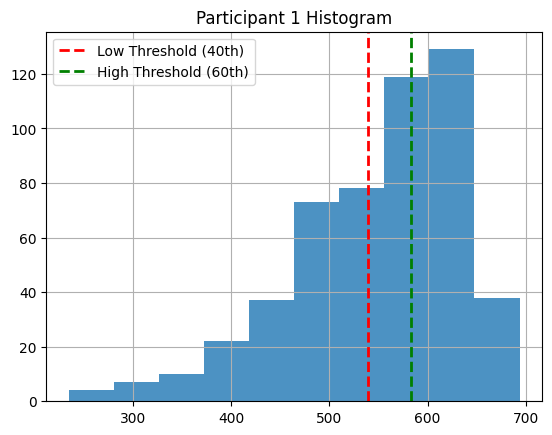

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -2.6092
  L2-R2                    : -0.6260
  Incoming Direction       : 0.4129


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.9796
  L2-R2                    : -0.6030
  Incoming Direction       : -0.0080


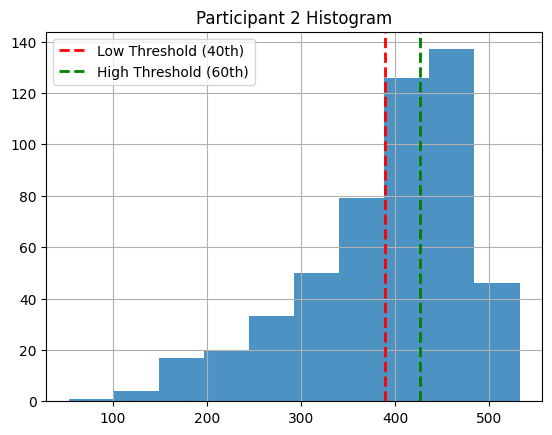

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.4280
  L2-R2                    : -0.3779
  Incoming Direction       : -0.9149


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.8315
  L2-R2                    : -0.0112
  Incoming Direction       : -0.8906


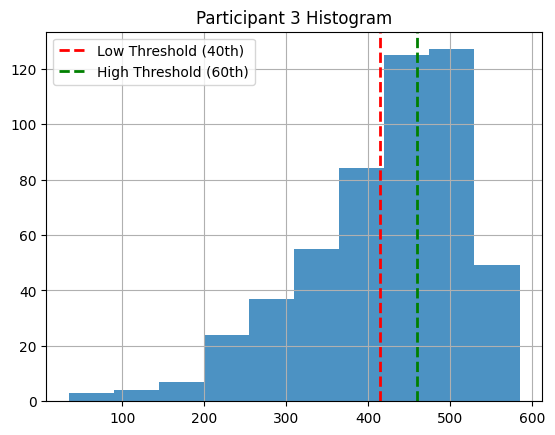

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.5937
  L2-R2                    : -0.3149
  Incoming Direction       : -0.2866


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.2976
  L2-R2                    : -0.6473
  Incoming Direction       : -0.2177


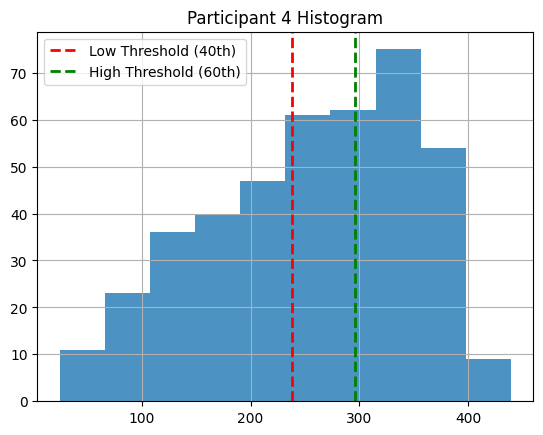

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -65.3589
  L2-R2                    : -14.3174
  Incoming Direction       : 1.8330


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -2.5434
  L2-R2                    : 0.2847
  Incoming Direction       : 0.2800


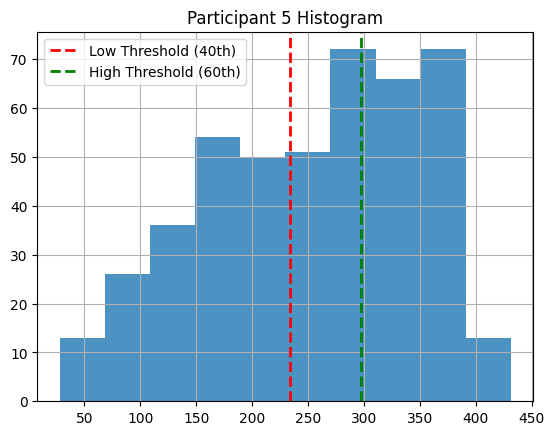

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -2.2146
  L2-R2                    : -0.4553
  Incoming Direction       : -0.7942


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.3886
  L2-R2                    : -0.0203
  Incoming Direction       : -1.6121


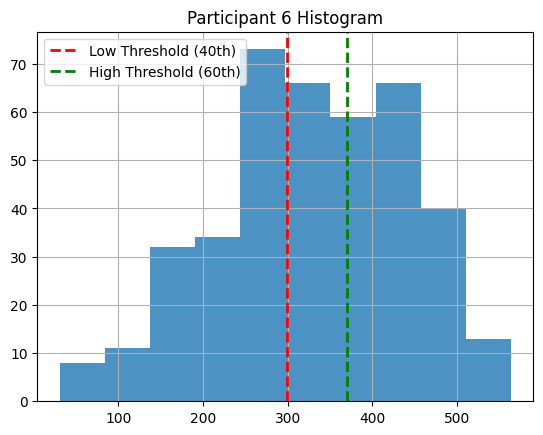

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.9801
  L2-R2                    : -0.8873
  Incoming Direction       : -1.2754


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.1910
  L2-R2                    : 0.1846
  Incoming Direction       : -1.0238


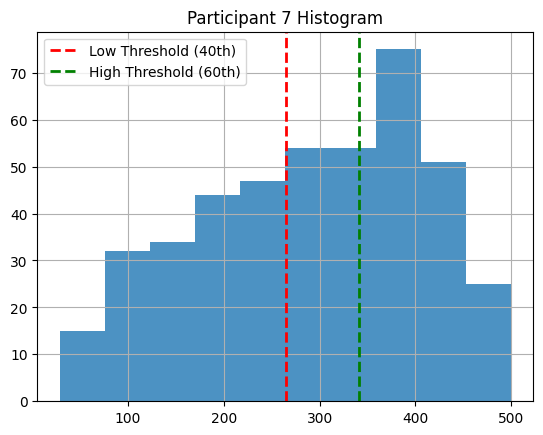

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.3249
  L2-R2                    : -1.0915
  Incoming Direction       : -1.1129


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -3.1510
  L2-R2                    : -1.7463
  Incoming Direction       : -1.4072


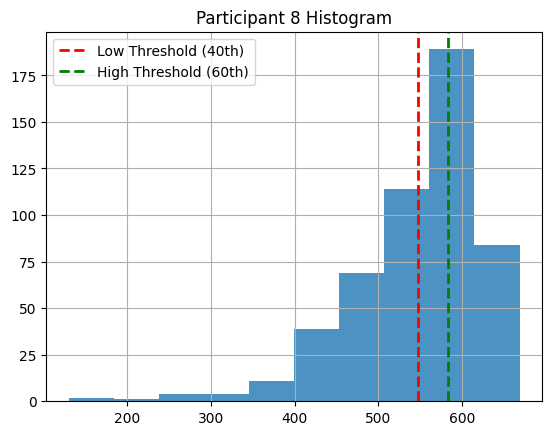

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.2859
  L2-R2                    : -0.4269
  Incoming Direction       : 0.5038


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.6752
  L2-R2                    : -0.1664
  Incoming Direction       : -0.1790


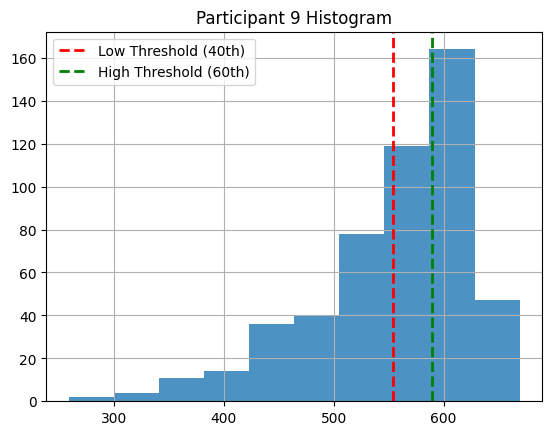

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -3.3925
  L2-R2                    : 0.1736
  Incoming Direction       : 0.4003


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -2.1562
  L2-R2                    : -0.2808
  Incoming Direction       : -0.1688


In [45]:
participants_data = [
    participant1, participant2, participant3, 
    participant4, participant5, participant6, 
    participant7, participant8, participant9
]

for i, p_data in enumerate(participants_data):
    input_data = pre_proccess_data_from_choice_vs_no_choice(p_data)
    
    # Isolate drifting trials
    input_data = input_data[input_data['block_drift'] == 1]
    
    # 1. Calculate thresholds BEFORE plotting
    LowY = input_data['ball_y_at_top'].quantile(0.4)
    HighY = input_data['ball_y_at_top'].quantile(0.6)

    # 2. Plot the histogram (added a slight transparency 'alpha' so lines stand out)
    input_data['ball_y_at_top'].hist(alpha=0.8)
    
    # 3. Add the vertical lines
    plt.axvline(LowY, color='red', linestyle='dashed', linewidth=2, label='Low Threshold (40th)')
    plt.axvline(HighY, color='green', linestyle='dashed', linewidth=2, label='High Threshold (60th)')
    
    # 4. Add labels and show the plot
    plt.title(f'Participant {i+1} Histogram')
    plt.legend()
    plt.show()

    # Note: I removed the redundant `& (input_data['block_drift'] == 1)` here 
    # because input_data was already filtered for drift = 1 at the top of the loop.
    low_pos_X = input_data[(input_data['ball_y_at_top'] < LowY)]
    high_pos_X = input_data[(input_data['ball_y_at_top'] > HighY)]

    print('Ball is high on the screen:')
    evaluate_logistic_for_ball_y(low_pos_X, is_data_raw = False)
    
    print('\n\nBall is low on the screen:')
    evaluate_logistic_for_ball_y(high_pos_X, is_data_raw= False)




# Heat Maps for Decision Making

In [46]:
def extract_spatial_features(df_raw, participant_name):
    """Applies spatial math and extracts block_drift for condition splitting."""
    if df_raw is None or df_raw.empty:
        return pd.DataFrame()

    is_left = df_raw['chosen_left'].astype(bool)
    
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    
    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']
    
    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    X = pd.DataFrame({
        'participant': participant_name,
        'L1-R1': np.round(L1 - R1), 
        'L2+L1-R2-R1': np.round(L2 - R2 + L1 - R1),
        'block_drift': df_raw['block_drift'], # 👈 Pulled into the clean matrix
        'chosen_right': (~is_left).astype(float) 
    })
    
    X = X.dropna(subset=['L1-R1', 'L2+L1-R2-R1', 'block_drift', 'chosen_right']).copy()
    
    X['L1-R1'] = X['L1-R1'].astype(int)
    X['L2+L1-R2-R1'] = X['L2+L1-R2-R1'].astype(int)
    
    return X

participants_data = [
    participant1, participant2, participant3, 
    participant4, participant5, participant6, 
    participant7, participant8, participant9
]

all_trials = []
for i, p_data in enumerate(participants_data):
    all_trials.append(extract_spatial_features(pre_proccess_data_from_choice_vs_no_choice(p_data), f'Participant {i+1}'))

df_combined = pd.concat(all_trials, ignore_index=True)


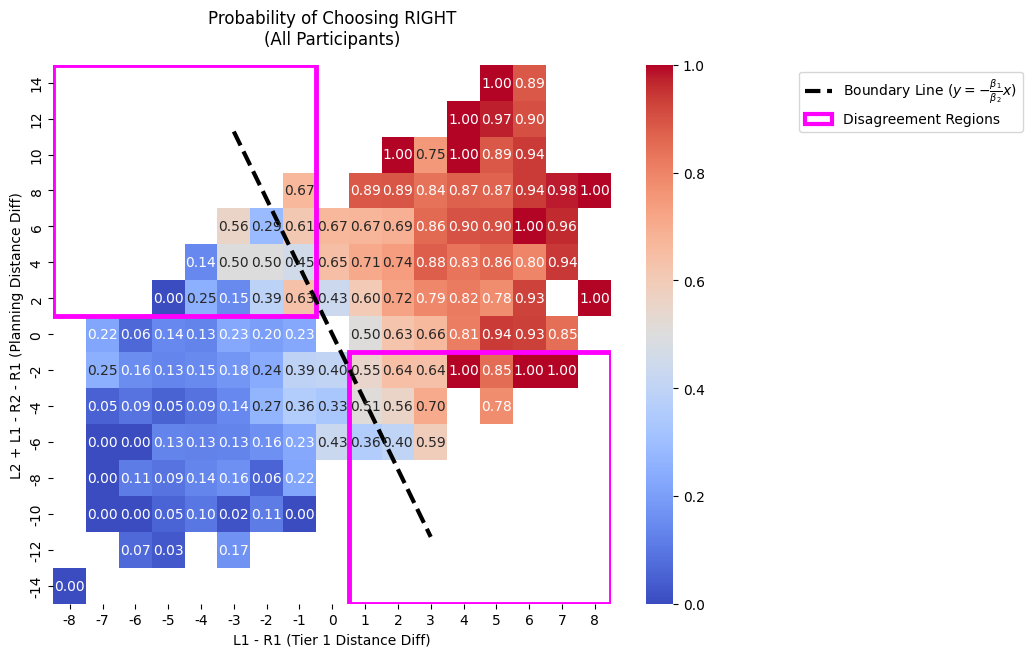

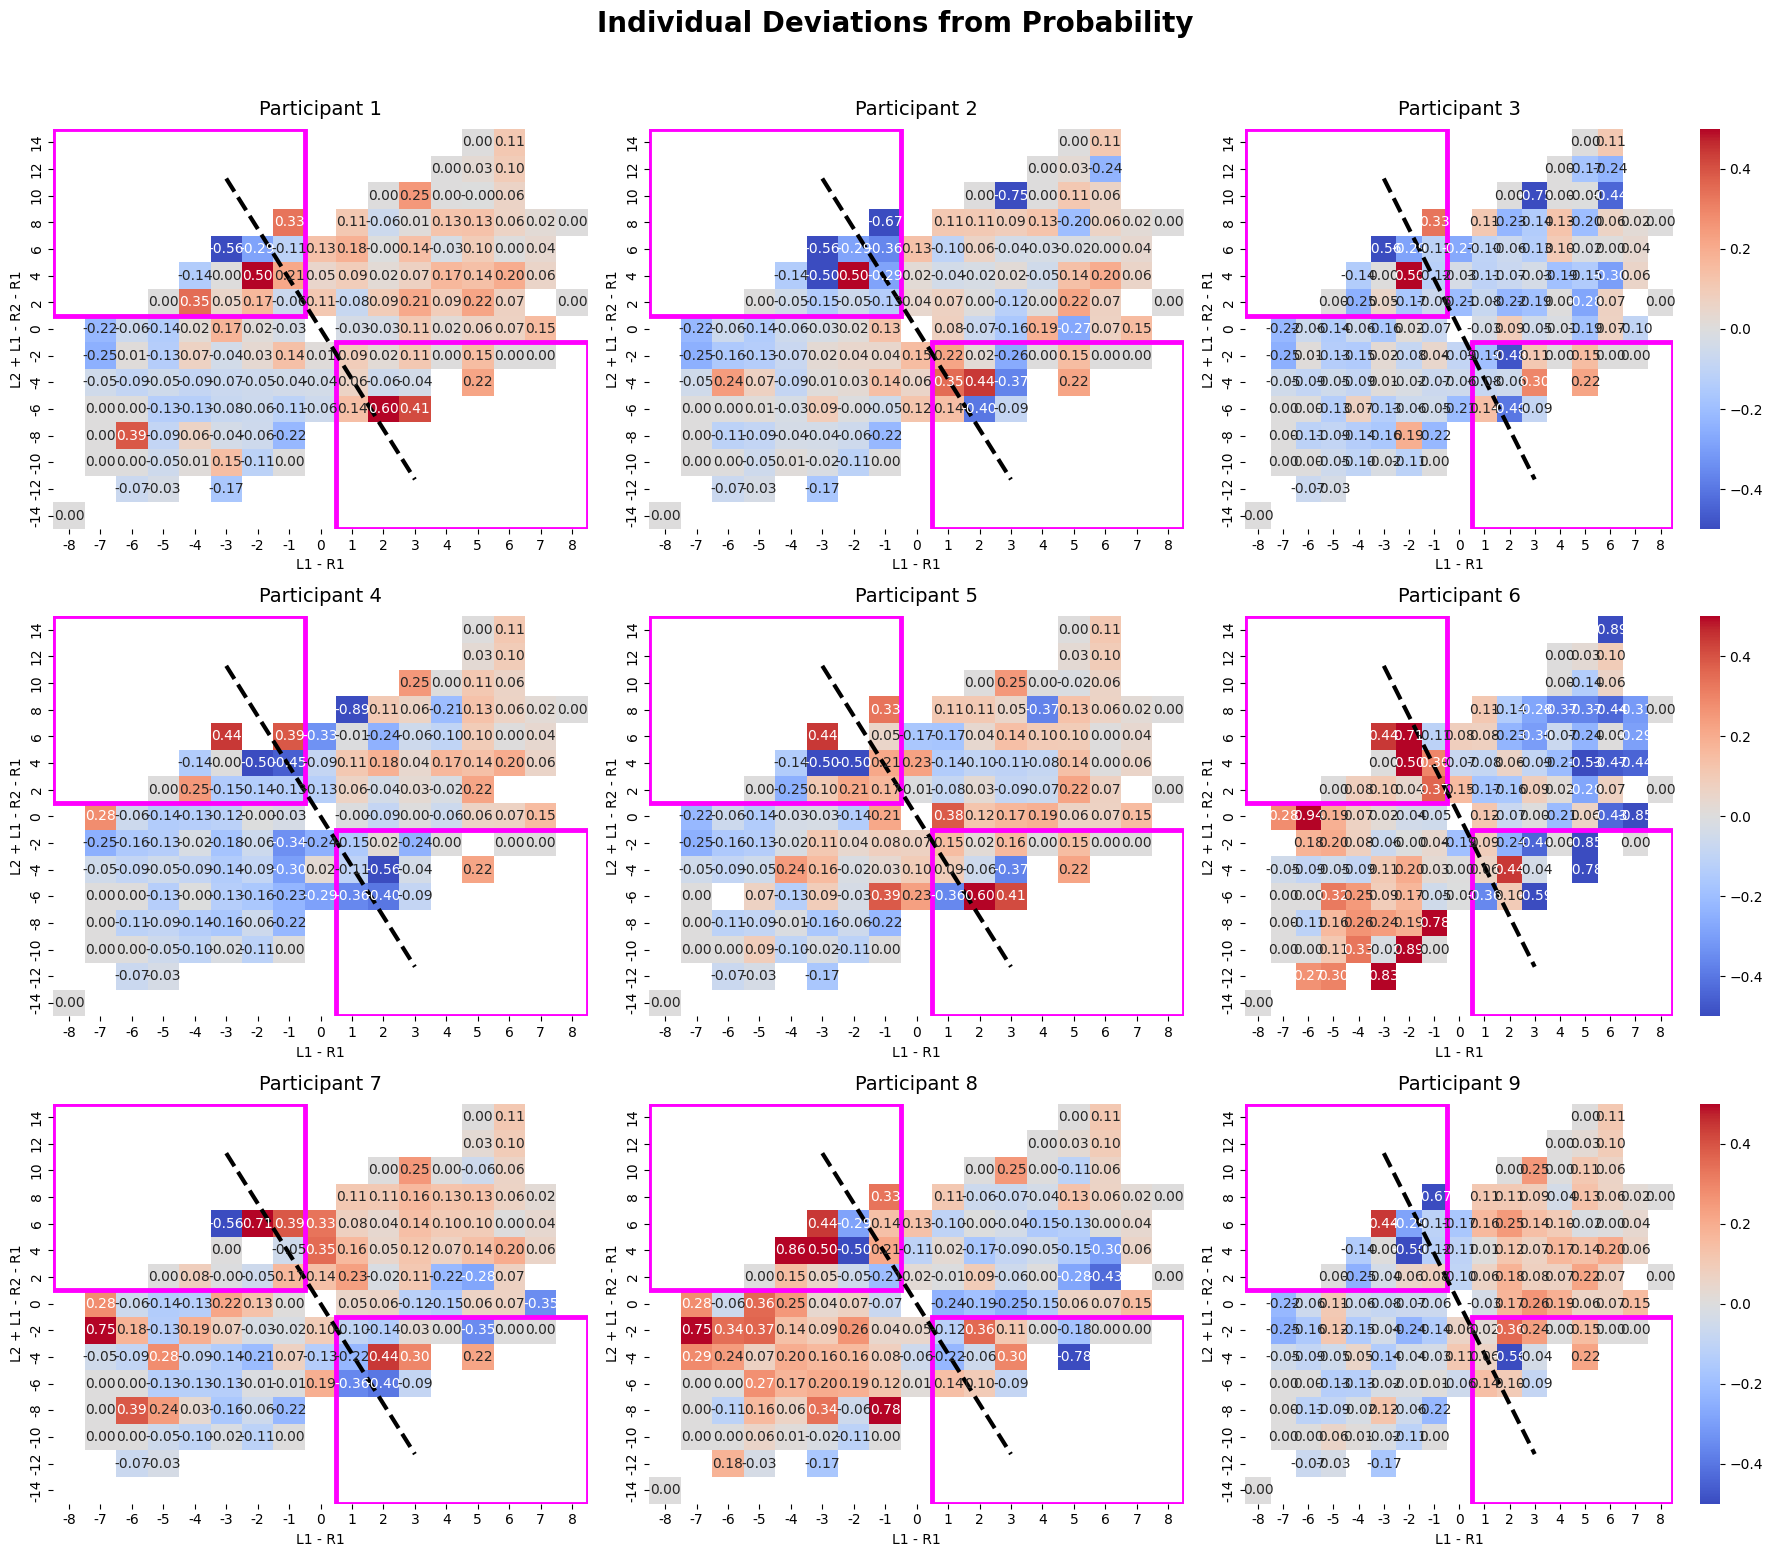

In [83]:
X_features = df_combined[['L1-R1', 'L2+L1-R2-R1']]
y_target = df_combined['chosen_right']

log_reg = LogisticRegression(penalty=None).fit(X_features, y_target)
beta1 = log_reg.coef_[0][0]  # Coefficient for L1-R1
beta2 = log_reg.coef_[0][1]  # Coefficient for L2+L1-R2-R1

master_pivot = df_combined.pivot_table(
    values='chosen_right', 
    index='L2+L1-R2-R1', 
    columns='L1-R1', 
    aggfunc='mean'
)

# Sort index so positive L2-R2 values are at the top of the heatmap
master_pivot = master_pivot.sort_index(ascending=False)

def add_disagreement_highlights_and_line(ax, pivot_table, b1, b2):
    """
    Overlays disagreement boxes and the decision boundary line on a seaborn heatmap.
    """
    x_vals = pivot_table.columns.values
    y_vals = pivot_table.index.values  # Note: this array is descending

    # --- 1. Draw Disagreement Boxes ---
    # Seaborn coordinates start with (0,0) at the TOP LEFT.
    # Calculate how many columns/rows fall on either side of 0
    num_cols_neg_x = sum(x < 0 for x in x_vals)
    num_cols_pos_x = sum(x > 0 for x in x_vals)
    
    num_rows_pos_y = sum(y > 0 for y in y_vals)
    num_rows_neg_y = sum(y < 0 for y in y_vals)

    # Upper Left Corner (x < 0, y > 0)
    if num_cols_neg_x > 0 and num_rows_pos_y > 0:
        rect_ul = patches.Rectangle((0, 0), width=num_cols_neg_x, height=num_rows_pos_y, 
                                    linewidth=3.5, edgecolor='magenta', facecolor='none', linestyle='-')
        ax.add_patch(rect_ul)

    # Bottom Right Corner (x > 0, y < 0)
    if num_cols_pos_x > 0 and num_rows_neg_y > 0:
        # Starting x coordinate is total columns minus the positive ones
        start_x = len(x_vals) - num_cols_pos_x
        # Starting y coordinate is total rows minus the negative ones
        start_y = len(y_vals) - num_rows_neg_y
        
        rect_br = patches.Rectangle((start_x, start_y), width=num_cols_pos_x, height=num_rows_neg_y, 
                                    linewidth=3.5, edgecolor='magenta', facecolor='none', linestyle='-')
        ax.add_patch(rect_br)

    # --- 2. Draw the Line y = -(b1/b2)x ---
    if b2 != 0:
        # Calculate mathematical y values for every x value in the grid
        line_y_vals = -(b1 / b2) * x_vals
        
        # Map x values to seaborn coordinates (centers of the columns: 0.5, 1.5, ...)
        x_coords = np.arange(len(x_vals)) + 0.5
        
        # Map mathematical y values to seaborn row coordinates using interpolation
        # np.interp requires the x-axis (our y_vals) to be strictly increasing, so we reverse it
        y_coords = np.interp(line_y_vals, y_vals[::-1], np.arange(len(y_vals))[::-1]) + 0.5
        
        # Only plot the segments of the line that fit within the grid's Y boundaries
        valid_idx = (line_y_vals <= max(y_vals)) & (line_y_vals >= min(y_vals))
        ax.plot(x_coords[valid_idx], y_coords[valid_idx], color='black', linewidth=3, linestyle='--', label='Decision Boundary')

# 3. Plot the Master Heatmap
plt.figure(figsize=(9, 7))
ax_master = sns.heatmap(master_pivot, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
add_disagreement_highlights_and_line(ax_master, master_pivot, beta1, beta2)

plt.title("Probability of Choosing RIGHT\n(All Participants)", pad=15)
plt.ylabel("L2 + L1 - R2 - R1 (Planning Distance Diff)")
plt.xlabel("L1 - R1 (Tier 1 Distance Diff)")

# Add custom legend for the line and boxes
import matplotlib.lines as mlines
line_legend = mlines.Line2D([], [], color='black', linestyle='--', linewidth=3, label='Boundary Line ($y = -\\frac{\\beta_1}{\\beta_2}x$)')
box_legend = patches.Patch(edgecolor='magenta', facecolor='none', linewidth=3, label='Disagreement Regions')
plt.legend(handles=[line_legend, box_legend], loc='upper right', bbox_to_anchor=(1.75, 1))

plt.show()

# 4. Build and Plot the Deviation Heatmaps
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle("Individual Deviations from Probability", fontsize=20, fontweight='bold', y=0.97)
axes = axes.flatten()

for i in range(9):
    p_name = f'Participant {i+1}'
    p_df = df_combined[df_combined['participant'] == p_name]
    
    # Create the individual's pivot table
    p_pivot = p_df.pivot_table(
        values='chosen_right', 
        index='L2+L1-R2-R1', 
        columns='L1-R1', 
        aggfunc='mean'
    )
    
    # Align the individual grid to match the master grid shape perfectly
    p_pivot = p_pivot.reindex_like(master_pivot)
    
    # Calculate Deviation (Participant Prob - Master Prob)
    deviation_matrix = p_pivot - master_pivot
    
    # Plot using a diverging colormap centered at 0
    sns.heatmap(
        deviation_matrix, 
        ax=axes[i], 
        annot=True, 
        cmap='coolwarm', 
        fmt=".2f", 
        center=0, 
        vmin=-0.5, 
        vmax=0.5, 
        cbar=(i % 3 == 2) 
    )
    
    # Apply the highlights and the master boundary line to each subplot for reference
    add_disagreement_highlights_and_line(axes[i], master_pivot, beta1, beta2)
    
    axes[i].set_title(p_name, fontsize=14, pad=10)
    axes[i].set_ylabel("L2 + L1 - R2 - R1")
    axes[i].set_xlabel("L1 - R1")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

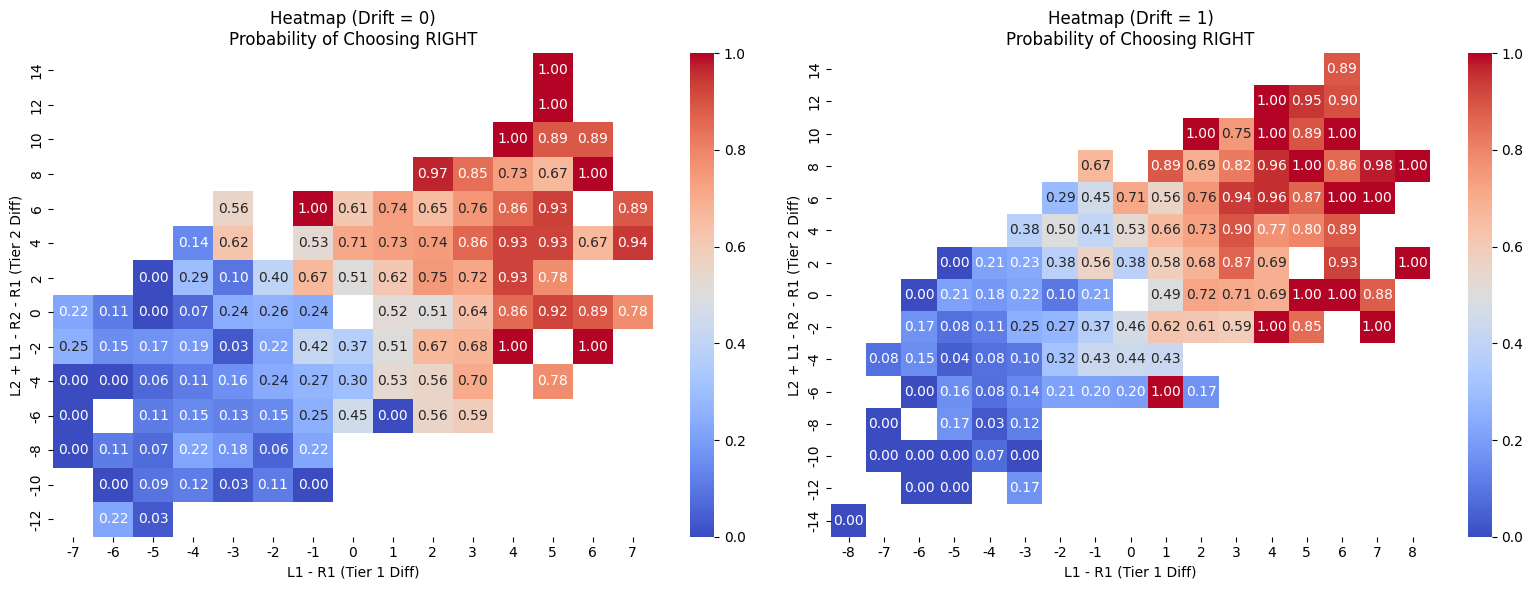

In [ ]:
df_drift_0 = df_combined[df_combined['block_drift'] == 0]
df_drift_1 = df_combined[df_combined['block_drift'] == 1]

# Create both master pivot tables
master_pivot_0 = df_drift_0.pivot_table(values='chosen_right', index='L2+L1-R2-R1', columns='L1-R1', aggfunc='mean').sort_index(ascending=False)
master_pivot_1 = df_drift_1.pivot_table(values='chosen_right', index='L2+L1-R2-R1', columns='L1-R1', aggfunc='mean').sort_index(ascending=False)

# Plot Both Master Heatmaps Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(master_pivot_0, ax=axes[0], annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
axes[0].set_title("Heatmap (Drift = 0)\nProbability of Choosing RIGHT")
axes[0].set_ylabel("L2 + L1 - R2 - R1 (Planning Diff)")
axes[0].set_xlabel("L1 - R1 (Tier 1 Diff)")

sns.heatmap(master_pivot_1, ax=axes[1], annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
axes[1].set_title("Heatmap (Drift = 1)\nProbability of Choosing RIGHT")
axes[1].set_ylabel("L2 + L1 - R2 - R1 (Planning Diff)")
axes[1].set_xlabel("L1 - R1 (Tier 1 Diff)")

plt.tight_layout()
plt.show()



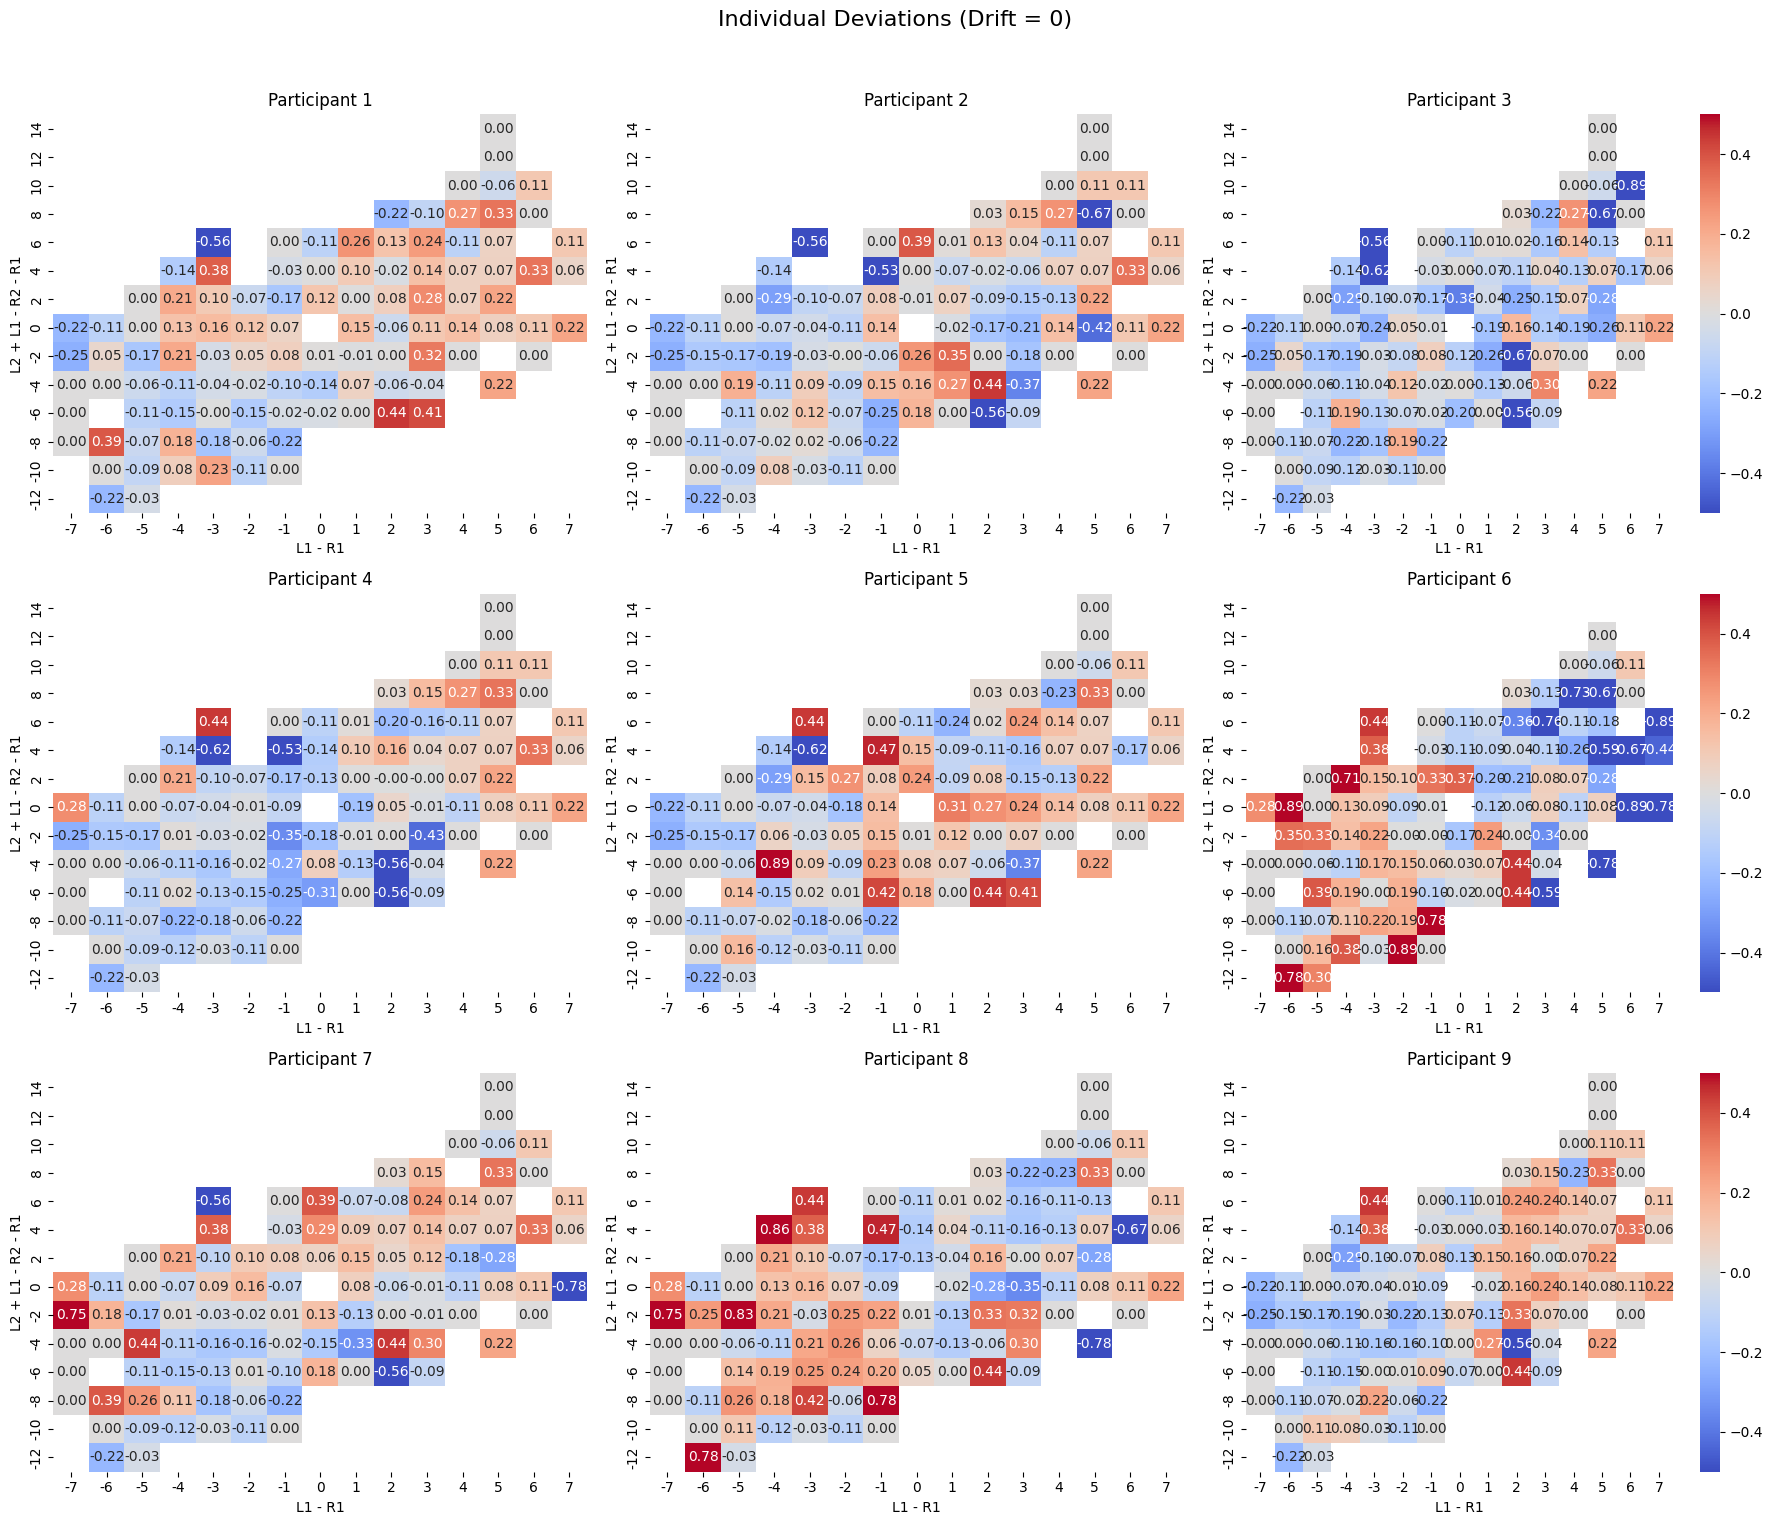

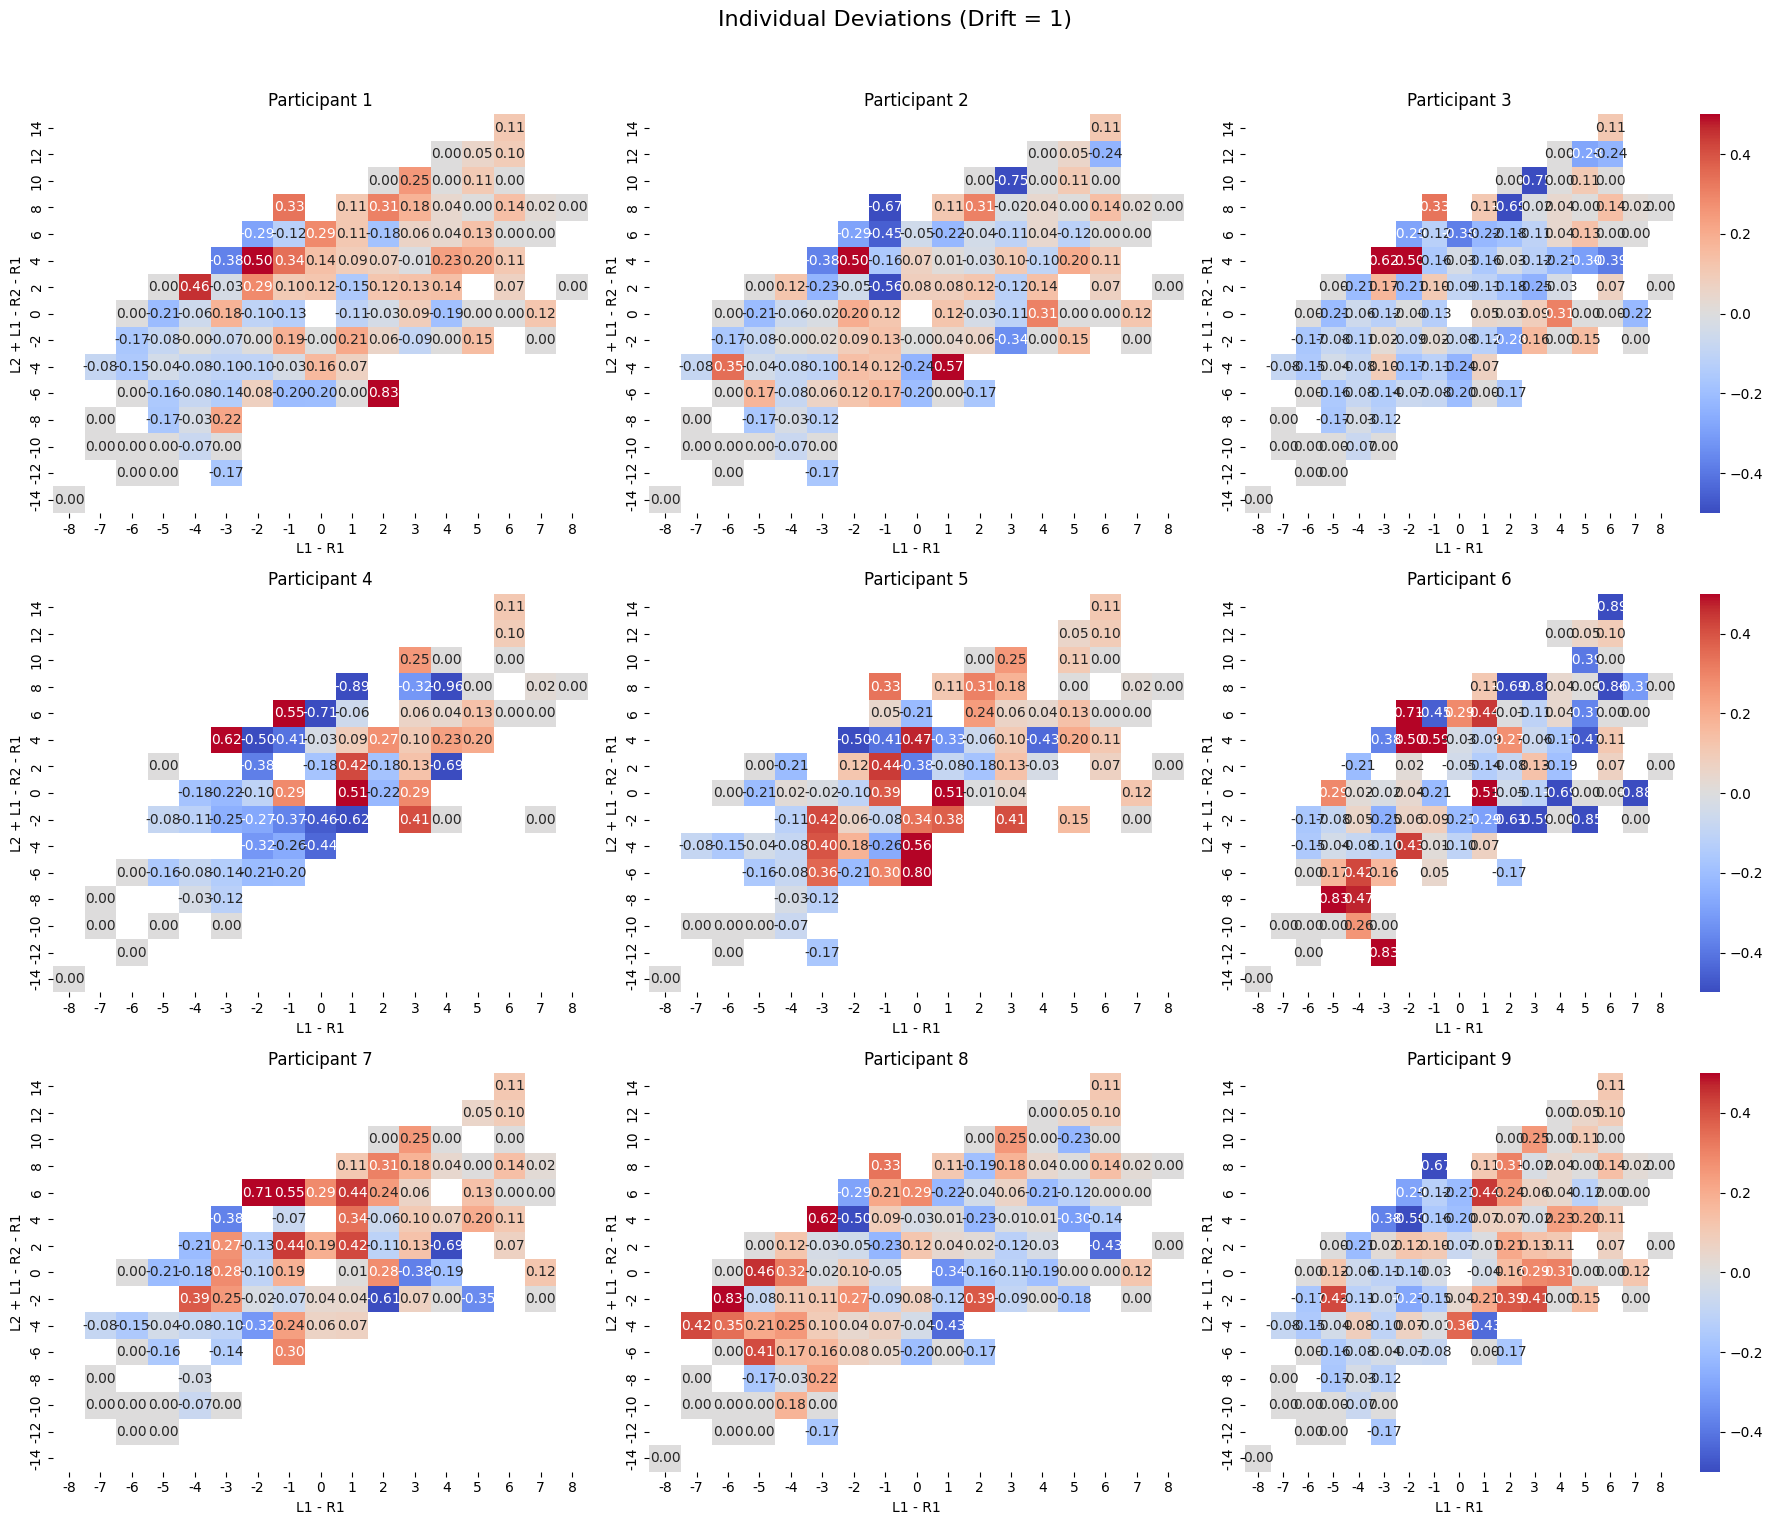

In [53]:
def plot_deviations_for_condition(df_subset, master_pivot, condition_label):
    """Generates a 3x3 grid of participant deviations for a specific drift condition."""
    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    fig.suptitle(f"Individual Deviations (Drift = {condition_label})", fontsize=16, y=0.95)
    axes = axes.flatten()

    for i in range(9):
        p_name = f'Participant {i+1}'
        p_df = df_subset[df_subset['participant'] == p_name]
        
        if p_df.empty:
            axes[i].set_title(f"{p_name}\n(No Data)")
            axes[i].axis('off')
            continue
            
        # Create the individual's pivot table for this drift condition
        p_pivot = p_df.pivot_table(values='chosen_right', index='L2+L1-R2-R1', columns='L1-R1', aggfunc='mean')
        
        # Align to the specific master grid for this condition
        p_pivot = p_pivot.reindex_like(master_pivot)
        
        # Calculate Deviation
        deviation_matrix = p_pivot - master_pivot
        
        sns.heatmap(
            deviation_matrix, 
            ax=axes[i], 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            center=0, 
            vmin=-0.5, 
            vmax=0.5, 
            cbar=(i % 3 == 2) 
        )
        
        axes[i].set_title(p_name)
        axes[i].set_ylabel("L2 + L1 - R2 - R1")
        axes[i].set_xlabel("L1 - R1")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Execute the deviation plots for both conditions
plot_deviations_for_condition(df_drift_0, master_pivot_0, "0")
plot_deviations_for_condition(df_drift_1, master_pivot_1, "1")

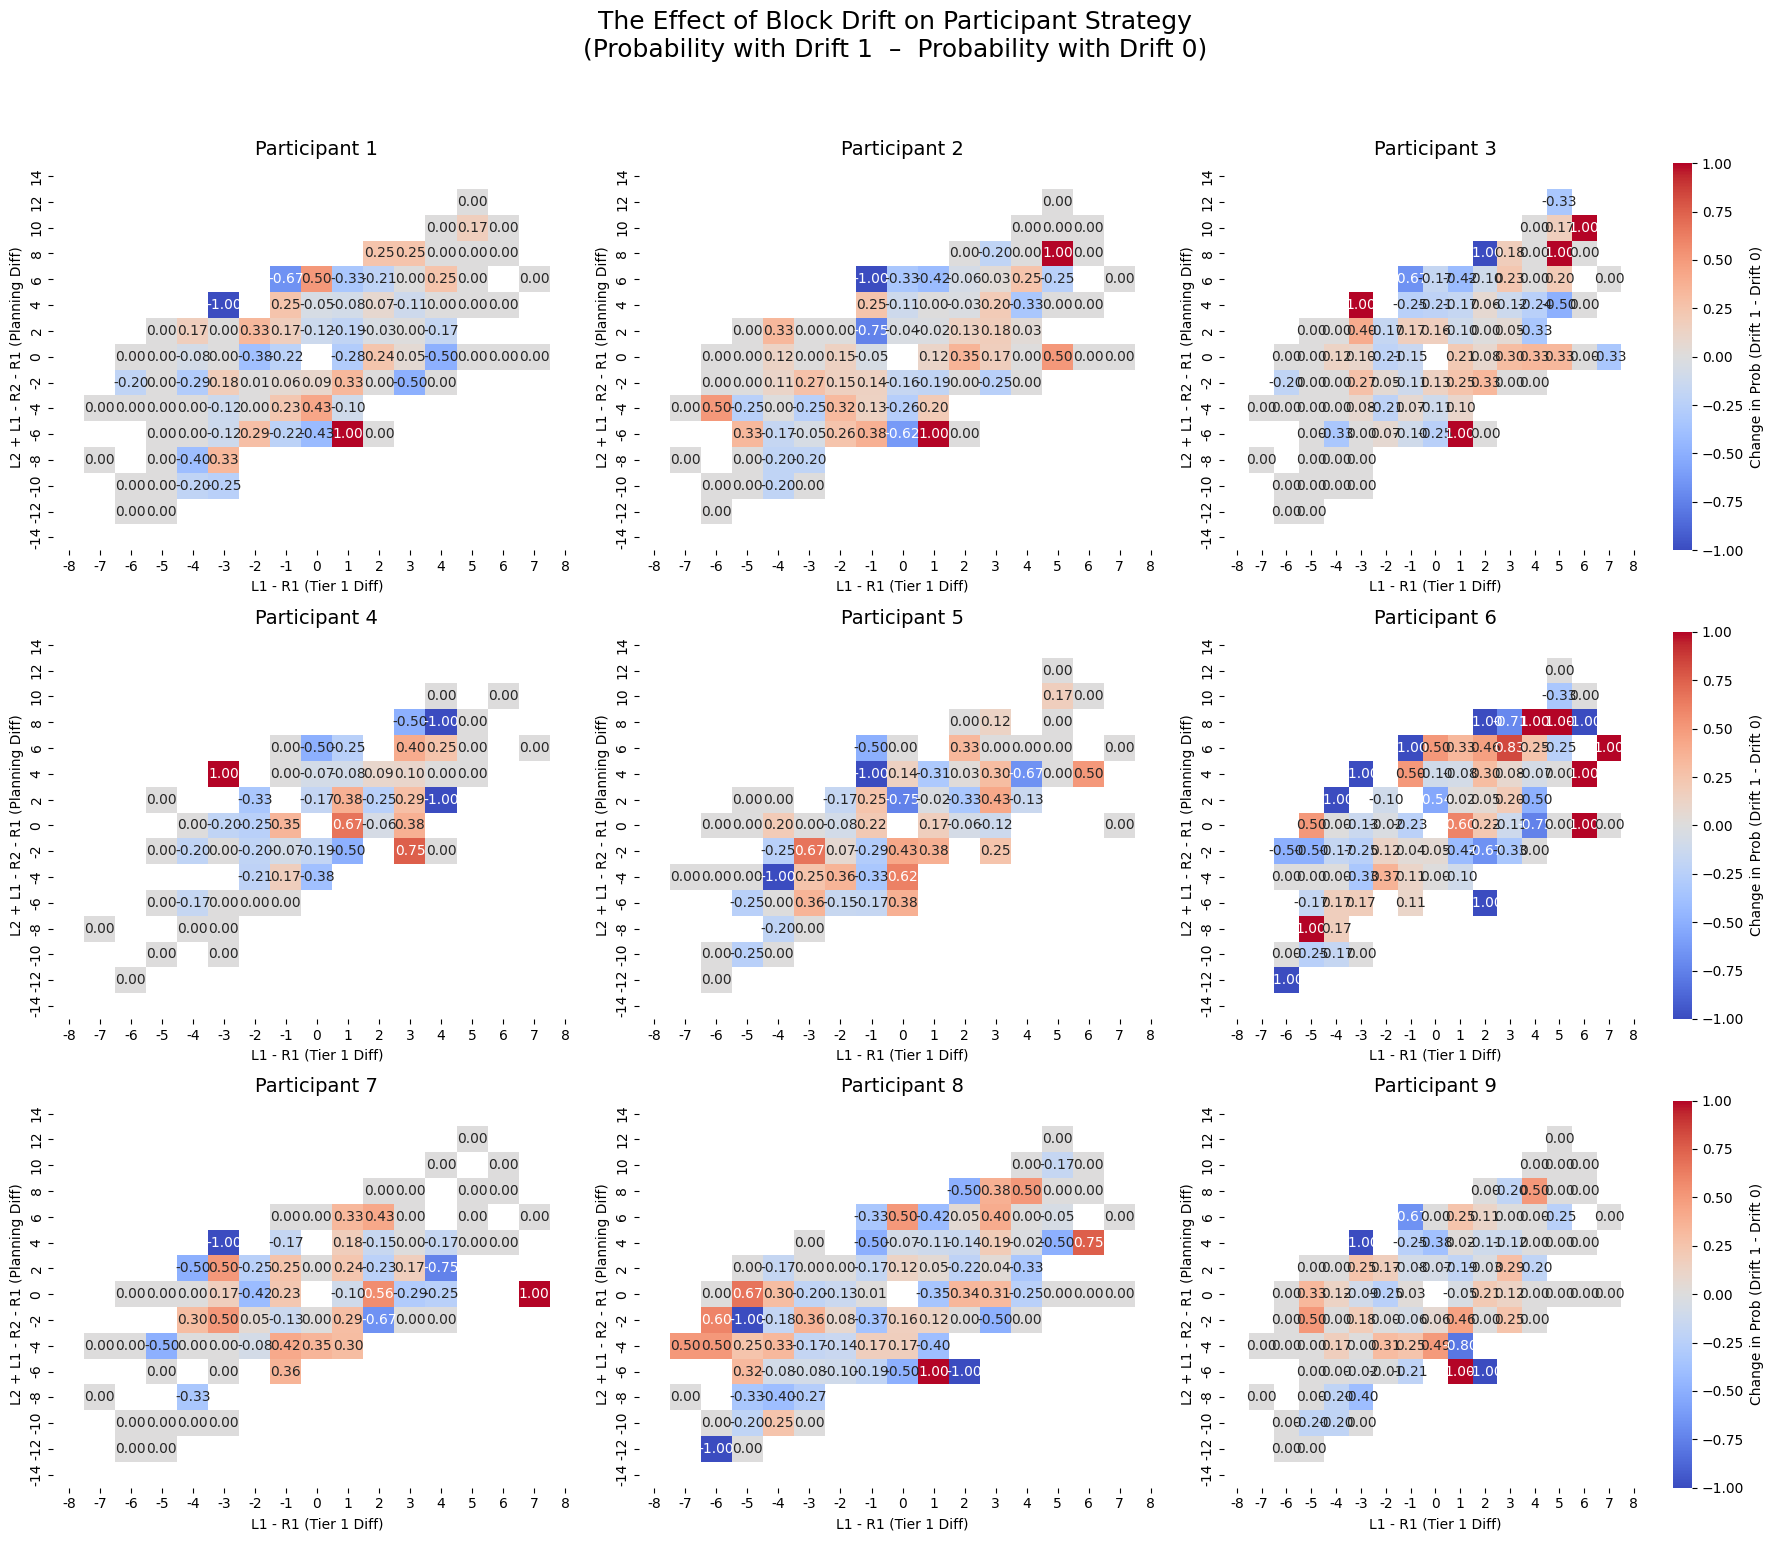

In [54]:
def plot_individual_drift_effects(df_combined):
    """
    Plots a 3x3 grid showing how the introduction of Block Drift changed 
    each participant's probability of choosing Right.
    """
    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    fig.suptitle("The Effect of Block Drift on Participant Strategy\n(Probability with Drift 1  –  Probability with Drift 0)", fontsize=18, y=0.96)
    axes = axes.flatten()

    # Generate a global master template to ensure all matrices align perfectly
    # (Even if a participant didn't see a specific coordinate in one condition)
    master_template = df_combined.pivot_table(
        values='chosen_right', 
        index='L2+L1-R2-R1', 
        columns='L1-R1'
    ).sort_index(ascending=False)

    for i in range(9):
        p_name = f'Participant {i+1}'
        
        # Isolate the specific participant's data for both conditions
        p_drift_0 = df_combined[(df_combined['participant'] == p_name) & (df_combined['block_drift'] == 0)]
        p_drift_1 = df_combined[(df_combined['participant'] == p_name) & (df_combined['block_drift'] == 1)]
        
        # Safety Check: If they are missing data for an entire condition, skip plotting
        if p_drift_0.empty or p_drift_1.empty:
            axes[i].set_title(f"{p_name}\n(Insufficient Data for Comparison)")
            axes[i].axis('off')
            continue
            
        # Pivot both conditions
        pivot_0 = p_drift_0.pivot_table(values='chosen_right', index='L2+L1-R2-R1', columns='L1-R1', aggfunc='mean')
        pivot_1 = p_drift_1.pivot_table(values='chosen_right', index='L2+L1-R2-R1', columns='L1-R1', aggfunc='mean')
        
        # Reindex to force them into the exact same shape
        pivot_0 = pivot_0.reindex_like(master_template)
        pivot_1 = pivot_1.reindex_like(master_template)
        
        # Calculate the true effect of the drift
        drift_impact_matrix = pivot_1 - pivot_0
        
        # Plot using a diverging colormap centered at 0
        sns.heatmap(
            drift_impact_matrix,
            ax=axes[i],
            annot=True,
            cmap='coolwarm', # Red = Increased Right Prob, Blue = Increased Left Prob
            fmt=".2f",
            center=0,
            vmin=-1.0,  # Probabilities max out at 1.0, so the absolute max difference is +/- 1.0
            vmax=1.0,
            cbar=(i % 3 == 2), # Only show colorbar on the rightmost plots
            cbar_kws={'label': 'Change in Prob (Drift 1 - Drift 0)'} if (i % 3 == 2) else None
        )
        
        axes[i].set_title(p_name, fontsize=14)
        axes[i].set_ylabel("L2 + L1 - R2 - R1 (Planning Diff)")
        axes[i].set_xlabel("L1 - R1 (Tier 1 Diff)")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


plot_individual_drift_effects(df_combined)

# Plotting Regression Weights for Visualizations

# Loading each participant data

In [55]:
participant1 = load("../data/cloud_study/65D6694BE06947289BE4336BC1DE271A-019e9464-b9d3-798d-aa65-c87d82961db6-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-03-48-346Z-fg8d.json")
participant2 = load("../data/cloud_study/88AD64F00C6B43489770A02E7A1AE2C2-019e8fd9-16e9-7876-8e3b-d51a48df0526-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-03T23-37-31-300Z-4ecm.json")
participant3 = load("../data/cloud_study/6462D588260B4356936047A04A336EBE-019e9464-f99c-77c5-bf47-327c7a7cf4f1-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-41-26-943Z-c5do.json")
participant4 = load("../data/cloud_study/46331EBA4F494FAD901E83106523FF12-019e9464-9d12-7cc3-8cba-8f0dd00eeb20-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-33-792Z-sop6.json")
participant5 = load("../data/cloud_study/BB4D2ACD4DAB45F5BAB68A472EB2E06C-019e9464-9a85-718c-9964-ec6755cdcd1c-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-17-611Z-i0am.json")
participant6 = load("../data/cloud_study/C47CEEC22AD9448E9F87D0577BA7FC80-019e946e-abeb-723a-8d4d-50881fc0551f-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-59-12-508Z-e1tl.json")
participant7 = load("../data/cloud_study/CEFD2FE92E6847B2B27FF0175811CE81-019e9464-988c-7240-bf66-336f77c05049-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-50-03-371Z-34zm.json")
participant8 = load("../data/cloud_study/EC07396CE23248F2855499612FEB8ACA-019e9464-92a5-7d10-b713-7022c5b049fc-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-16-501Z-olib.json")
participant9 = load("../data/cloud_study/FD2A6686546A4D689BE4A684CD264636-019e946a-96b4-78df-ac42-63e6e82c3209-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-54-42-499Z-j7h3.json")

participants_data = [participant1, participant2, participant3, participant4, participant5, participant6, participant7, participant8, participant9]

## Overall Participant Coeffecients

In [56]:
def plot_all_participant_coefficients(participants_data):
    """
    Evaluates 9 participants and plots their regression coefficients in a 3x3 grid.
    Adds a '*' for coefficients with p < 0.05 and labels the title with log likelihood.
    """
    fig, axes = plt.subplots(3, 3, figsize=(22, 18))
    fig.suptitle("Logistic Regression Coefficients by Participant\n(* indicates p < 0.05)\n \u0394 indicates change in coeffecient due to drift", 
                 fontsize=20, fontweight='bold', y=0.96)
    axes = axes.flatten()
    
    # Cleaner display labels for the x-axis
    display_features = [
        'L1-R1', 
        'L1+L2-R1-R2', 
        #'Drift', 
        #'\u0394 L1-R1', 
        #'\u0394 L2-R2', 
        'Inc. Dir',
        '\u0394 Inc. Dir'
    ]

    for i in range(9):
        ax = axes[i]
        p_name = f'Participant {i+1}'
        
        # Guardrail in case of missing participants in the array
        if i >= len(participants_data):
            ax.axis('off')
            continue
            
        p_data = participants_data[i]
        results = evaluate_logistic_baseline(p_data, test_split=0.2, is_data_raw=True)
        
        if results is None:
            ax.set_title(f"{p_name} - No Valid Data", fontsize=14)
            ax.axis('off')
            continue

        coefs = results['coefficients']
        p_vals = results['p_values']
        ll = results['log_likelihood']
        
        # Plot the bars
        colors = ['steelblue' if c > 0 else 'indianred' for c in coefs]
        bars = ax.bar(display_features, coefs, color=colors, edgecolor='black')
        
        # Add asterisks for statistical significance
        max_abs_coef = max(abs(coefs)) if len(coefs) > 0 else 1
        offset = max_abs_coef * 0.08  # Dynamic offset based on the scale of the Y-axis
        
        for j, bar in enumerate(bars):
            if p_vals[j] < 0.05:
                # Determine placement above or below the bar based on positive/negative
                if coefs[j] >= 0:
                    ax.text(bar.get_x() + bar.get_width()/2, coefs[j] + offset, '*', 
                            ha='center', va='center', fontsize=18, fontweight='bold', color='black')
                else:
                    ax.text(bar.get_x() + bar.get_width()/2, coefs[j] - offset, '*', 
                            ha='center', va='center', fontsize=18, fontweight='bold', color='black')

        # Formatting the subplot
        ax.set_title(f"{p_name} (Log Likelihood: {ll:.3f})", fontsize=14, pad=15)
        ax.axhline(0, color='black', linewidth=1) # Draw the zero line
        ax.set_xticklabels(display_features, rotation=45, ha='right', fontsize=11)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Ensure the Y-axis stretches enough to fit the asterisks without cutting them off
        ax.set_ylim(min(coefs) - (max_abs_coef * 0.2), max(coefs) + (max_abs_coef * 0.2))

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

def plot_aggregate_coefficients(participants_data):
    """
    Evaluates all participants, calculates the mean coefficients and standard errors,
    and plots a single aggregate bar chart.
    """
    all_coefs = []
    feature_names = []
    
    # 1. Collect coefficients for all valid participants
    for i, p_data in enumerate(participants_data):
        results = evaluate_logistic_baseline(p_data, test_split=0.2, is_data_raw=True)
        
        if results is not None:
            all_coefs.append(results['coefficients'])
            # Capture the feature names from the first valid participant
            if not feature_names:
                feature_names = results['features']
                
    if not all_coefs:
        print("❌ No valid participant data to plot.")
        return
        
    # Convert to a 2D numpy array: Shape = (num_participants, num_features)
    all_coefs = np.array(all_coefs) 
    
    # 2. Calculate Mean and Standard Error (SEM)
    mean_coefs = np.mean(all_coefs, axis=0)
    sem_coefs = np.std(all_coefs, axis=0, ddof=1) / np.sqrt(len(all_coefs))
    
    # 3. Group-Level Statistical Significance (1-sample t-test against 0)
    t_stats, p_vals = ttest_1samp(all_coefs, popmean=0, axis=0)
    
    # 4. Map the raw feature names to your cleaner display labels
    name_mapping = {
        'L1-R1': 'L1-R1',
        'L1+L2-R1-R2': 'L1+L2-R1-R2',
        'Block Drift': 'Drift',
        'Block Drift + L1-R1 Interaction': '\u0394 L1-R1',
        'Block Drift + L1+L2-R1-R2 Interaction': '\u0394 L1+L2-R1-R2',
        'Incoming Direction': 'Inc. Dir',
        'Block Drift + Incoming Direction Interaction': '\u0394 Inc. Dir'
    }
    display_features = [name_mapping.get(feat, feat) for feat in feature_names]
    
    # 5. Plotting
    fig, ax = plt.subplots(figsize=(10, 7))
    
    colors = ['steelblue' if c > 0 else 'indianred' for c in mean_coefs]
    
    # Plot bars with error bars (yerr)
    bars = ax.bar(display_features, mean_coefs, yerr=sem_coefs, color=colors, 
                  edgecolor='black', capsize=6, alpha=0.85, linewidth=1.5)
    
    # 6. Add asterisks for statistical significance
    # Calculate a dynamic offset so asterisks sit cleanly above/below the error bars
    max_abs_val = np.max(np.abs(mean_coefs) + sem_coefs)
    offset = max_abs_val * 0.08  
    
    for j, bar in enumerate(bars):
        if p_vals[j] < 0.05:
            # Place asterisk just outside the tip of the error bar
            if mean_coefs[j] >= 0:
                y_pos = mean_coefs[j] + sem_coefs[j] + offset
            else:
                y_pos = mean_coefs[j] - sem_coefs[j] - offset
                
            ax.text(bar.get_x() + bar.get_width()/2, y_pos, '*', 
                    ha='center', va='center', fontsize=22, fontweight='bold', color='black')

    # Formatting the subplot
    ax.set_title("Average Logistic Regression Coefficients Across Participants\n(* indicates group mean is significantly different from 0, p < 0.05)", 
                 fontsize=16, fontweight='bold', pad=15)
    ax.axhline(0, color='black', linewidth=1.2) # Draw the zero line
    ax.set_ylabel("Mean Coefficient Weight", fontsize=14)
    ax.set_xticklabels(display_features, rotation=45, ha='right', fontsize=13)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Ensure the Y-axis stretches enough to fit the asterisks without cutting them off
    ax.set_ylim(np.min(mean_coefs - sem_coefs) - (max_abs_val * 0.25), 
                np.max(mean_coefs + sem_coefs) + (max_abs_val * 0.25))

    plt.tight_layout()
    plt.show()

C:\Users\manik\AppData\Local\Temp\ipykernel_34616\3344374577.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_features, rotation=45, ha='right', fontsize=11)
C:\Users\manik\AppData\Local\Temp\ipykernel_34616\3344374577.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_features, rotation=45, ha='right', fontsize=11)
C:\Users\manik\AppData\Local\Temp\ipykernel_34616\3344374577.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_features, rotation=45, ha='right', fontsize=11)
C:\Users\manik\AppData\Local\Temp\ipykernel_34616\3344374577.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a

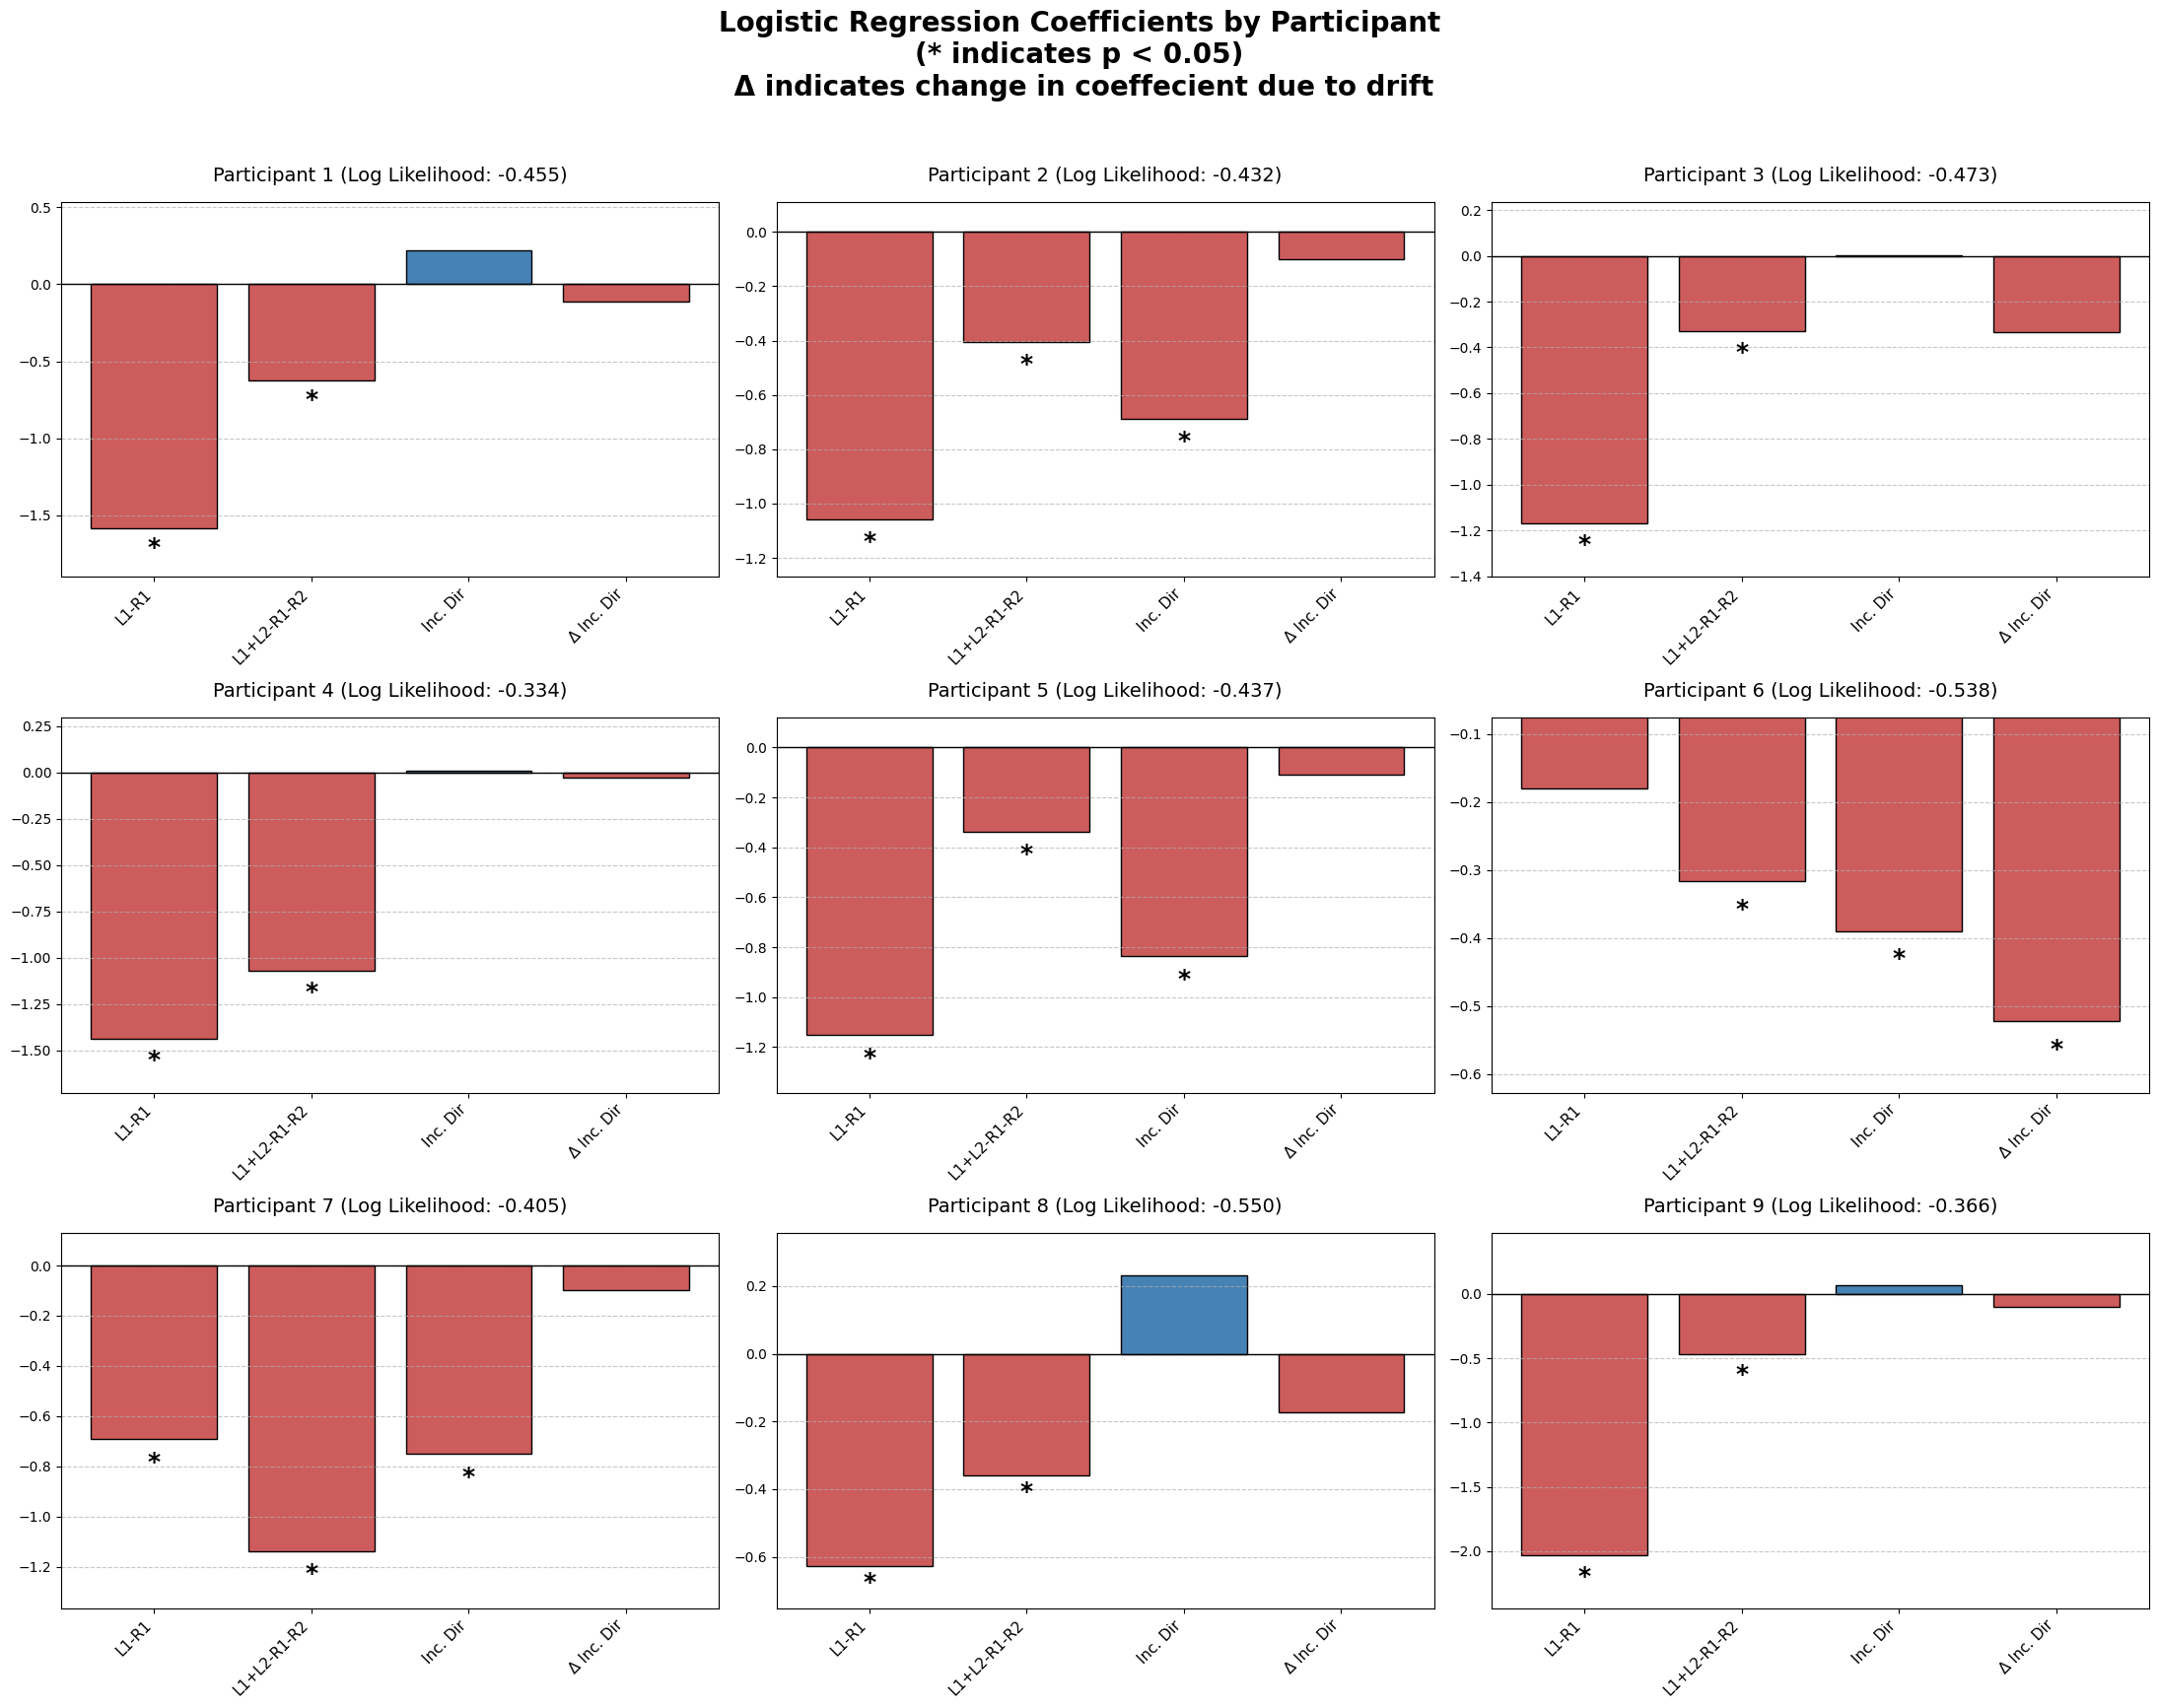

In [57]:
plot_all_participant_coefficients(participants_data)

C:\Users\manik\AppData\Local\Temp\ipykernel_34616\3344374577.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_features, rotation=45, ha='right', fontsize=13)


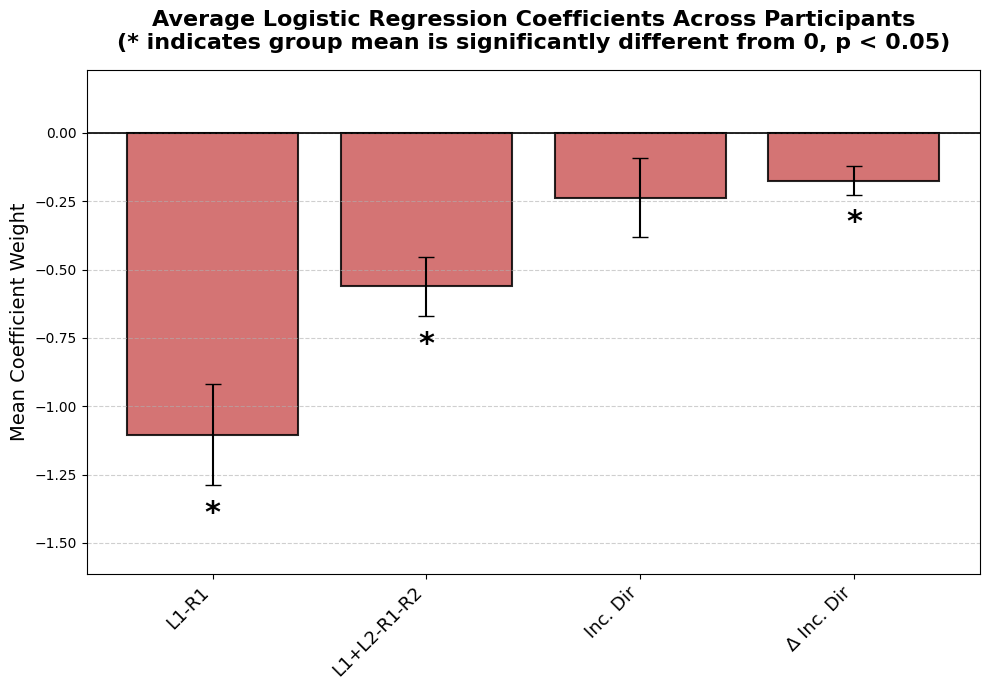

In [58]:
plot_aggregate_coefficients(participants_data)

In [59]:
def plot_aggregate_coefficients_with_individuals(participants_data):
    """
    Plots an aggregate bar chart of mean coefficients with SEM error bars,
    overlaid with jittered scatter points representing individual participants.
    """
    all_coefs = []
    feature_names = []
    
    # 1. Collect coefficients for all valid participants
    for i, p_data in enumerate(participants_data):
        results = evaluate_logistic_baseline(p_data, test_split=0.2, is_data_raw=True)
        
        if results is not None:
            all_coefs.append(results['coefficients'])
            if not feature_names:
                feature_names = results['features']
                
    if not all_coefs:
        print("❌ No valid participant data to plot.")
        return
        
    all_coefs = np.array(all_coefs) 
    
    # 2. Calculate Mean and Standard Error (SEM)
    mean_coefs = np.mean(all_coefs, axis=0)
    sem_coefs = np.std(all_coefs, axis=0, ddof=1) / np.sqrt(len(all_coefs))
    
    # 3. Group-Level Statistical Significance (1-sample t-test against 0)
    t_stats, p_vals = ttest_1samp(all_coefs, popmean=0, axis=0)
    
    name_mapping = {
        'L1-R1': 'L1-R1',
        'L2-R2': 'L2-R2',
        'Block Drift': 'Drift',
        'Block Drift + L1-R1 Interaction': '\u0394 L1-R1',
        'Block Drift + L2-R2 Interaction': '\u0394 L2-R2',
        'Incoming Direction': 'Inc. Dir',
        'Block Drift + Incoming Direction Interaction': '\u0394 Inc. Dir'
    }
    display_features = [name_mapping.get(feat, feat) for feat in feature_names]
    
    # 4. Plotting Setup
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = ['steelblue' if c > 0 else 'indianred' for c in mean_coefs]
    x_positions = np.arange(len(display_features))
    
    # A. Plot the aggregate bars (set alpha to 0.6 so the dots stand out)
    bars = ax.bar(x_positions, mean_coefs, yerr=sem_coefs, color=colors, 
                  edgecolor='black', capsize=6, alpha=0.6, linewidth=1.5, zorder=2)
    
    # B. Plot the individual participant points with horizontal jitter
    np.random.seed(42) # Keeps the jitter visually consistent if you rerun the plot
    for j in range(len(display_features)):
        # Generate random horizontal offsets for the dots
        jitter = np.random.normal(0, 0.08, size=len(all_coefs))
        x_jittered = x_positions[j] + jitter
        
        # Plot the column of dots
        ax.scatter(x_jittered, all_coefs[:, j], color='black', alpha=0.5, 
                   s=40, edgecolor='white', linewidth=0.5, zorder=3)
    
    # 5. Add asterisks for statistical significance
    # Calculate offset based on the absolute maximum value plotted (including outliers)
    max_plot_val = np.max(all_coefs)
    min_plot_val = np.min(all_coefs)
    plot_range = max_plot_val - min_plot_val
    offset = plot_range * 0.05  
    
    for j, bar in enumerate(bars):
        if p_vals[j] < 0.05:
            # Place asterisk safely outside the furthest data point (bar + error OR highest scatter dot)
            if mean_coefs[j] >= 0:
                highest_point_in_column = max(mean_coefs[j] + sem_coefs[j], np.max(all_coefs[:, j]))
                y_pos = highest_point_in_column + offset
            else:
                lowest_point_in_column = min(mean_coefs[j] - sem_coefs[j], np.min(all_coefs[:, j]))
                y_pos = lowest_point_in_column - offset
                
            ax.text(bar.get_x() + bar.get_width()/2, y_pos, '*', 
                    ha='center', va='center', fontsize=22, fontweight='bold', color='black')

    # Formatting the subplot
    ax.set_title("Average Coefficients Across Participants\n(* indicates group mean is significantly different from 0, p < 0.05)", 
                 fontsize=16, fontweight='bold', pad=15)
    ax.axhline(0, color='black', linewidth=1.2, zorder=1)
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(display_features, rotation=45, ha='right', fontsize=13)
    ax.set_ylabel("Mean Coefficient Weight", fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    
    # Expand Y-axis slightly so asterisks and highest dots aren't clipped
    ax.set_ylim(min_plot_val - (plot_range * 0.15), max_plot_val + (plot_range * 0.15))

    plt.tight_layout()
    plt.show()

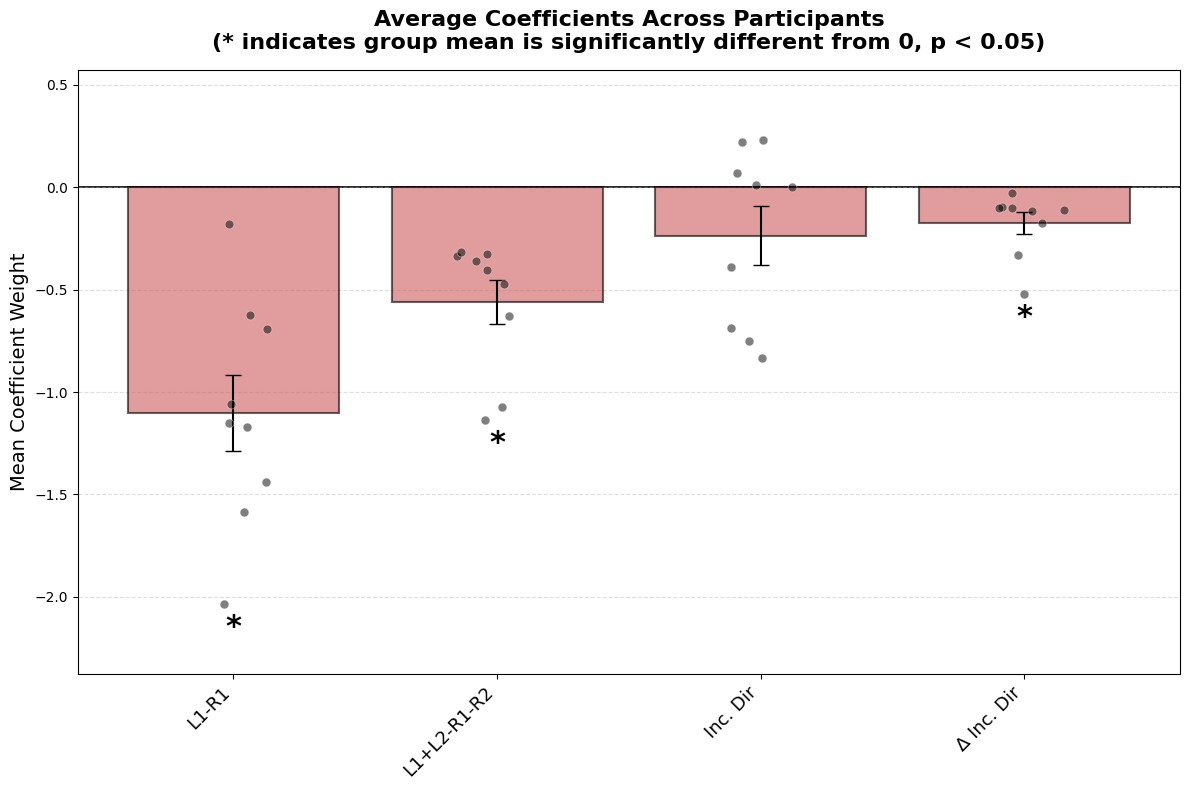

In [60]:
plot_aggregate_coefficients_with_individuals(participants_data)

In [79]:
def plot_aggregate_coefficients_with_individuals(participants_data):
    """
    Plots an aggregate bar chart of mean coefficients with SEM error bars,
    overlaid with jittered scatter points representing individual participants.
    Individual participant points are connected by lines, and symbols indicate
    intra-participant statistical significance.
    """
    all_coefs = []
    all_pvals = []  # Added to track individual significance
    feature_names = []
    
    # 1. Collect coefficients and p-values for all valid participants
    for i, p_data in enumerate(participants_data):
        results = evaluate_logistic_baseline(p_data, test_split=0.2, is_data_raw=True)
        
        if results is not None:
            all_coefs.append(results['coefficients'])
            all_pvals.append(results['p_values'])
            if not feature_names:
                feature_names = results['features']
                
    if not all_coefs:
        print("❌ No valid participant data to plot.")
        return
        
    all_coefs = np.array(all_coefs) 
    all_pvals = np.array(all_pvals)
    
    # 2. Calculate Mean and Standard Error (SEM)
    mean_coefs = np.mean(all_coefs, axis=0)
    sem_coefs = np.std(all_coefs, axis=0, ddof=1) / np.sqrt(len(all_coefs))
    
    # 3. Group-Level Statistical Significance (1-sample t-test against 0)
    t_stats, p_vals = ttest_1samp(all_coefs, popmean=0, axis=0)
    
    name_mapping = {
        'L1-R1': 'L1-R1',
        'L2-R2': 'L2-R2',
        'Block Drift': 'Drift',
        'Block Drift + L1-R1 Interaction': '\u0394 L1-R1',
        'Block Drift + L2-R2 Interaction': '\u0394 L2-R2',
        'Incoming Direction': 'Inc. Dir',
        'Block Drift + Incoming Direction Interaction': '\u0394 Inc. Dir'
    }
    display_features = [name_mapping.get(feat, feat) for feat in feature_names]
    
    # 4. Plotting Setup
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = ['steelblue' if c > 0 else 'indianred' for c in mean_coefs]
    x_positions = np.arange(len(display_features))
    
    # A. Plot the aggregate bars
    bars = ax.bar(x_positions, mean_coefs, yerr=sem_coefs, color=colors, 
                  edgecolor='black', capsize=6, alpha=0.5, linewidth=1.5, zorder=2)
    
    # B. Generate a constant jitter PER PARTICIPANT to keep connecting lines coherent
    np.random.seed(42)
    num_participants = len(all_coefs)
    participant_jitters = np.random.normal(0, 0.08, size=num_participants)
    
    # C. Plot connecting lines for each individual participant
    for i in range(num_participants):
        x_vals = x_positions + participant_jitters[i]
        y_vals = all_coefs[i, :]
        ax.plot(x_vals, y_vals, color='gray', alpha=0.3, linewidth=1, zorder=3)
    
    # D. Plot the individual participant points with conditional markers
    for j in range(len(display_features)):
        # Apply the participant-specific jitter to the current feature's x-column
        x_jittered = x_positions[j] + participant_jitters
        y_vals = all_coefs[:, j]
        p_vals_ind = all_pvals[:, j]
        
        # Create masks for significant vs non-significant points
        sig_mask = p_vals_ind < 0.05
        non_sig_mask = ~sig_mask
        
        # Plot significant points (Diamond, solid black)
        ax.scatter(x_jittered[sig_mask], y_vals[sig_mask], 
                   marker='D', color='black', alpha=0.8, s=45, 
                   edgecolor='white', linewidth=0.5, zorder=4,
                   label='Indiv. Sig. (p<0.05)' if j == 0 else "")
                   
        # Plot non-significant points (Circle, lighter gray)
        ax.scatter(x_jittered[non_sig_mask], y_vals[non_sig_mask], 
                   marker='o', color='gray', alpha=0.6, s=35, 
                   edgecolor='white', linewidth=0.5, zorder=4,
                   label='Indiv. Non-Sig.' if j == 0 else "")
    
    # 5. Add asterisks for Group-Level statistical significance
    max_plot_val = np.max(all_coefs)
    min_plot_val = np.min(all_coefs)
    plot_range = max_plot_val - min_plot_val
    offset = plot_range * 0.05  
    
    for j, bar in enumerate(bars):
        if p_vals[j] < 0.05:
            if mean_coefs[j] >= 0:
                highest_point_in_column = max(mean_coefs[j] + sem_coefs[j], np.max(all_coefs[:, j]))
                y_pos = highest_point_in_column + offset
            else:
                lowest_point_in_column = min(mean_coefs[j] - sem_coefs[j], np.min(all_coefs[:, j]))
                y_pos = lowest_point_in_column - offset
                
            ax.text(bar.get_x() + bar.get_width()/2, y_pos, '*', 
                    ha='center', va='center', fontsize=22, fontweight='bold', color='black')

    # 6. Formatting the subplot
    ax.set_title("Average Coefficients Across Participants\n(* indicates group mean is significantly different from 0, p < 0.05)", 
                 fontsize=16, fontweight='bold', pad=15)
    ax.axhline(0, color='black', linewidth=1.2, zorder=1)
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(display_features, rotation=45, ha='right', fontsize=13)
    ax.set_ylabel("Mean Coefficient Weight", fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    
    # Add legend to explain the scatter markers
    ax.legend(loc='best', fontsize=10)
    
    # Expand Y-axis slightly so asterisks and highest dots aren't clipped
    ax.set_ylim(min_plot_val - (plot_range * 0.15), max_plot_val + (plot_range * 0.15))

    plt.tight_layout()
    plt.show()

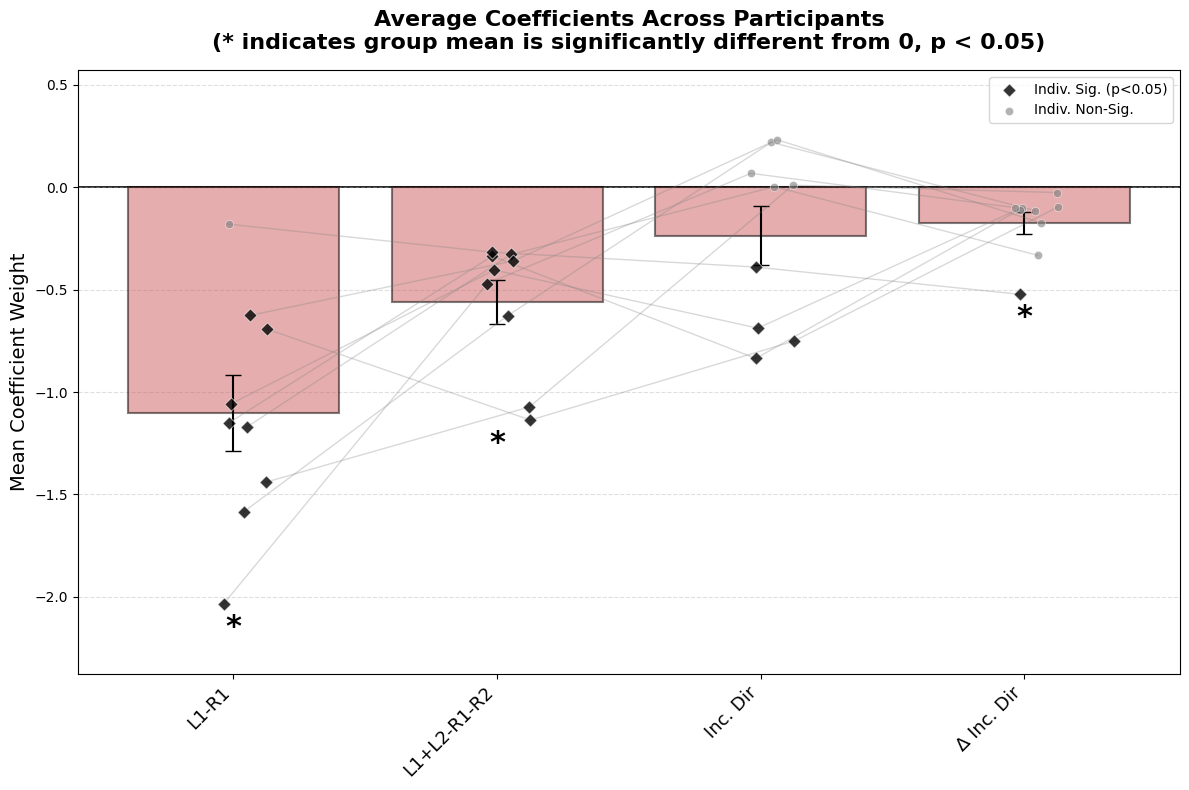

In [80]:
plot_aggregate_coefficients_with_individuals(participants_data)

## AIC/BIC Plots

In [61]:
def get_information_criteria(df_raw):
    """
    Standardizes features and fits 6 sequential logistic regression models 
    using statsmodels to extract AIC and BIC for a single participant.
    """
    is_left = df_raw['chosen_left'].astype(bool)
    
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']
    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    X = pd.DataFrame({
        'diff_1step': L1 - R1,
        'diff_2step': L2 - R2,
        'Block Drift': df_raw['block_drift'],
        'chosen_left': df_raw['chosen_left'].astype(int),
        'Incoming Direction': df_raw['incoming_direction']
    })

    # Drop NaNs before standardizing
    X = X.dropna().copy()
    if len(X) < 10: # Safety guard
        return None, None

    # Standardize distances
    X['L1-R1'] = (X['diff_1step'] - X['diff_1step'].mean()) / (X['diff_1step'].std() + 1e-6)
    X['L2-R2'] = (X['diff_2step'] - X['diff_2step'].mean()) / (X['diff_2step'].std() + 1e-6)

    # Calculate Interactions
    X['Drift x L1-R1'] = X['L1-R1'] * X['Block Drift']
    X['Drift x L2-R2'] = X['L2-R2'] * X['Block Drift']
    X['Drift x Inc Dir'] = X['Incoming Direction'] * X['Block Drift']

    # Define the exact progression of features you requested
    model_stages = {
        'Null (Base Rate)': [],
        '+ Tier 1': ['L1-R1'],
        '+ Tier 2': ['L1-R1', 'L2-R2'],
        '+ Inc. Dir': ['L1-R1', 'L2-R2', 'Incoming Direction'],
        '+ Dir x Drift': ['L1-R1', 'L2-R2', 'Incoming Direction', 'Drift x Inc Dir'],
        'All Features': ['L1-R1', 'L2-R2', 'Incoming Direction', 'Drift x Inc Dir', 
                         'Block Drift', 'Drift x L1-R1', 'Drift x L2-R2']
    }

    y = X['chosen_left']
    aic_scores = []
    bic_scores = []

    for name, features in model_stages.items():
        # statsmodels requires an explicit constant (intercept)
        if len(features) == 0:
            X_model = sm.add_constant(pd.Series(np.ones(len(y)), name='const', index=X.index))
        else:
            X_model = sm.add_constant(X[features])

        try:
            model = sm.Logit(y, X_model).fit(disp=0)
            aic_scores.append(model.aic)
            bic_scores.append(model.bic)
        except Exception:
            aic_scores.append(np.nan)
            bic_scores.append(np.nan)

    return aic_scores, bic_scores, list(model_stages.keys())

def plot_model_evolution(participants_data):
    """
    Iterates through participants and generates parallel coordinate line plots 
    for AIC and BIC model progression.
    """
    all_aic = []
    all_bic = []
    stage_names = None

    # 1. Gather data
    for p_data in participants_data:
        # Assuming you've run pre_proccess_data_from_choice_vs_no_choice on p_data
        aic, bic, names = get_information_criteria(pd.DataFrame(p_data))
        if aic is not None:
            all_aic.append(aic)
            all_bic.append(bic)
            stage_names = names

    if not all_aic:
        print("No valid participant data to plot.")
        return

    # 2. Setup Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle("Model Fit Evolution by Participant", fontsize=16)

    # Use a color similar to your reference image
    line_color = '#7ebbc5' 

    # 3. Plot AIC
    for p_aic in all_aic:
        ax1.plot(stage_names, p_aic, marker='o', color=line_color, linewidth=2, alpha=0.8, markersize=8)
    
    ax1.set_title("Akaike Information Criterion (AIC)", fontsize=14, pad=10)
    ax1.set_ylabel("AIC Score", fontsize=12)
    ax1.set_xticklabels(stage_names, rotation=45, ha='right', fontsize=11)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # 4. Plot BIC
    for p_bic in all_bic:
        ax2.plot(stage_names, p_bic, marker='o', color=line_color, linewidth=2, alpha=0.8, markersize=8)

    ax2.set_title("Bayesian Information Criterion (BIC)", fontsize=14, pad=10)
    ax2.set_ylabel("BIC Score", fontsize=12)
    ax2.set_xticklabels(stage_names, rotation=45, ha='right', fontsize=11)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

C:\Users\manik\AppData\Local\Temp\ipykernel_34616\748692301.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stage_names, rotation=45, ha='right', fontsize=11)
C:\Users\manik\AppData\Local\Temp\ipykernel_34616\748692301.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(stage_names, rotation=45, ha='right', fontsize=11)


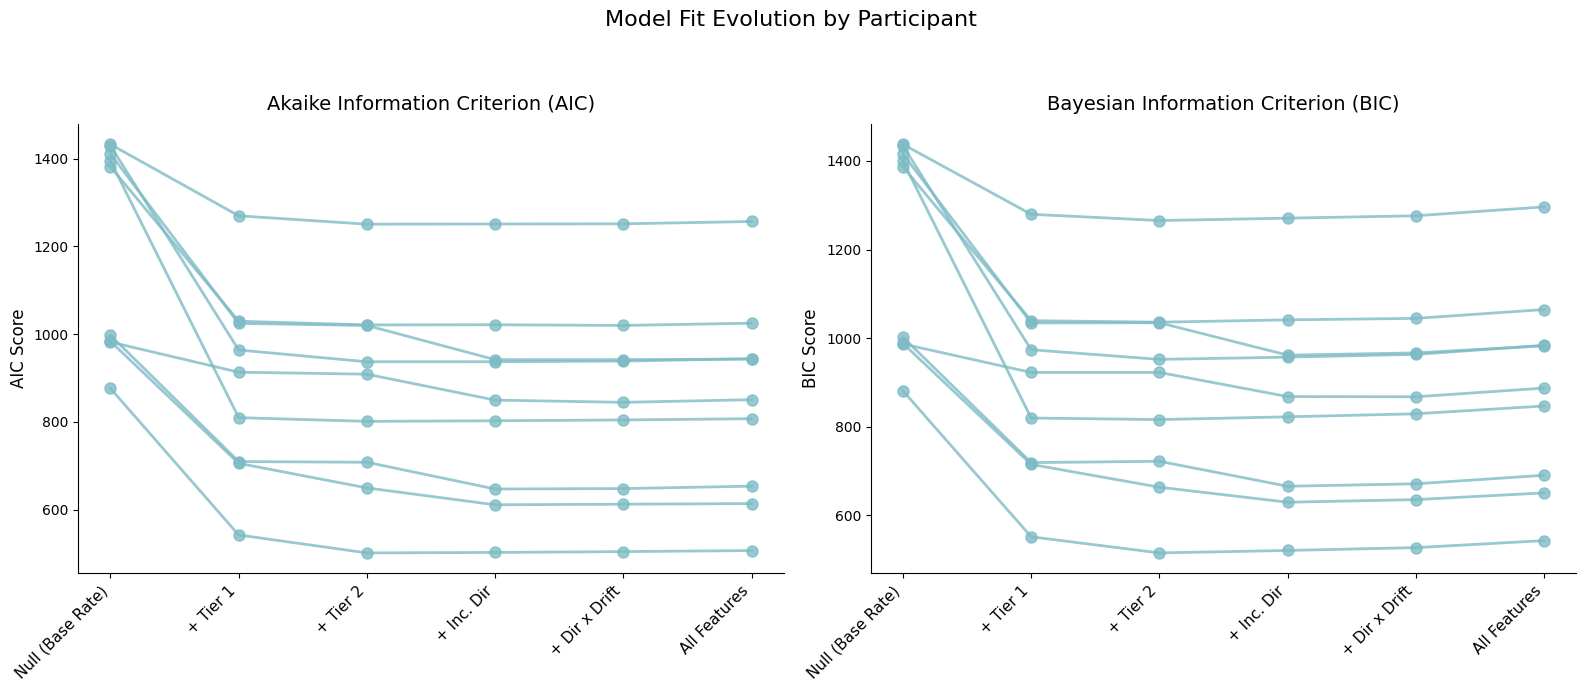

In [62]:
processed_participant_data = []
for p_data in participants_data:
    processed_participant_data.append(pre_proccess_data_from_choice_vs_no_choice(p_data))
plot_model_evolution(processed_participant_data)

# Changes in Behavior From Ball Y Coeffecients

In [ ]:
def prepare_and_fit_subset(df_raw):
    """
    Standardizes the distances and fits a Logit model on a specific data subset.
    Returns the coefficients (params) and Standard Errors (bse).
    """
    is_left = df_raw['chosen_left'].astype(bool)
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']
    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    X = pd.DataFrame({
        'diff_1step': L1 - R1,
        'diff_planning': L1 + L2 - R1 - R2,
        'Incoming Direction': df_raw['incoming_direction'],
        'chosen_left': df_raw['chosen_left'].astype(int)
    })

    X = X.dropna().copy()
    
    if len(X) < 10 or len(X['chosen_left'].unique()) < 2:
        return None, None

    # Standardize distances locally for this subset
    X['L1-R1'] = (X['diff_1step'] - X['diff_1step'].mean()) / (X['diff_1step'].std() + 1e-6)
    X['L1+L2-R1-R2'] = (X['diff_planning'] - X['diff_planning'].mean()) / (X['diff_planning'].std() + 1e-6)

    features = ['L1-R1', 'L1+L2-R1-R2', 'Incoming Direction']
    X_model = sm.add_constant(X[features])
    y = X['chosen_left']

    try:
        model = sm.Logit(y, X_model).fit(disp=0)
        return model.params, model.bse
    except Exception:
        return None, None
    

def check_significance(beta1, beta2, se1, se2):
    """Performs a Z-test for the difference between two independent coefficients."""
    # Add a tiny epsilon to the denominator to prevent division by zero
    z_score = (beta1 - beta2) / np.sqrt(se1**2 + se2**2 + 1e-12)
    p_value = stats.norm.sf(abs(z_score)) * 2 # Two-tailed test
    return p_value < 0.05

def plot_ball_y_coefficient_shifts(participants_data, quantiles):
    """
    Splits each participant's drifting trials into 'Ball High' and 'Ball Low',
    fits regressions on both, and plots the shift in coefficients.
    """
    percentile = quantiles*100

    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    fig.suptitle(f"Coefficient Shifts: Ball High vs. Ball Low on Screen\n(* indicates significant difference between conditions, p < 0.05)" \
    f"\n Bottom {percentile:.0f} percentile vs Top {percentile:.0f} percentile Ball Postion"
                 , fontsize=18, y=0.96)
    axes = axes.flatten()

    features = ['L1-R1', 'L1+L2-R1-R2', 'Incoming Direction']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

    for i in range(9):
        ax = axes[i]
        p_name = f'Participant {i+1}'

        if i >= len(participants_data):
            ax.axis('off')
            continue

        # 1. Preprocess and isolate Drift == 1
        p_data = pre_proccess_data_from_choice_vs_no_choice(participants_data[i])
        df_drift = p_data[p_data['block_drift'] == 1].copy()

        if df_drift.empty or 'ball_y_at_top' not in df_drift.columns:
            ax.set_title(f"{p_name}\n(Insufficient Data)")
            ax.axis('off')
            continue

        # 2. Split by Screen Position
        # (Remember: smaller Y = higher on the screen physically)
        y_coords = df_drift['ball_y_at_top'].dropna()
        if len(y_coords) < 20:
            ax.set_title(f"{p_name}\n(Not enough trials)")
            ax.axis('off')
            continue



        low_y_thresh = y_coords.quantile(quantiles)
        high_y_thresh = y_coords.quantile(1-quantiles)

        df_high_on_screen = df_drift[df_drift['ball_y_at_top'] < low_y_thresh]
        df_low_on_screen = df_drift[df_drift['ball_y_at_top'] > high_y_thresh]

        # 3. Fit Models
        params_high, se_high = prepare_and_fit_subset(df_high_on_screen)
        params_low, se_low = prepare_and_fit_subset(df_low_on_screen)

        if params_high is None or params_low is None:
            ax.set_title(f"{p_name}\n(Model Failed to Converge)")
            ax.axis('off')
            continue

        # 4. Plot Slope Lines
        x_positions = [0, 1]
        x_labels = ['Ball HIGH\non Screen\n(Closer to Death)', 'Ball LOW\non Screen\n(Farther from Death)']
        for j, feature in enumerate(features):
            b_high = params_high[feature]
            b_low = params_low[feature]
            
            # Draw the connecting line
            ax.plot(x_positions, [b_high, b_low], marker='o', color=colors[j], 
                    linewidth=2.5, markersize=8, label=feature)

            # Check significance of the difference
            if check_significance(b_high, b_low, se_high[feature], se_low[feature]):
                # Place an asterisk right in the middle of the line
                mid_x = 0.5
                mid_y = (b_high + b_low) / 2
                ax.text(mid_x, mid_y + 0.1, '*', color=colors[j], 
                        fontsize=24, fontweight='bold', ha='center', va='bottom')

        ax.set_title(p_name, fontsize=14)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, fontsize=12)
        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        
        if i == 0: # Only put the legend on the first plot to avoid clutter
            ax.legend(loc='best', fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def plot_aggregate_ball_y_shifts(participants_data, quantiles):
    """
    Aggregates coefficients across all valid participants for 'Ball High' 
    and 'Ball Low', plotting the group means with standard error bars.
    Also plots individual participant shifts transparently in the background.
    """
    percentile = quantiles * 100
    features = ['L1-R1', 'L1+L2-R1-R2', 'Incoming Direction']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

    # Data structures to collect coefficients AND standard errors across all participants
    group_high_coefs = {feature: [] for feature in features}
    group_low_coefs = {feature: [] for feature in features}
    group_high_se = {feature: [] for feature in features}
    group_low_se = {feature: [] for feature in features}

    # 1. Collect Data
    for p_data in participants_data:
        p_df = pre_proccess_data_from_choice_vs_no_choice(p_data)
        df_drift = p_df[p_df['block_drift'] == 1].copy()

        if df_drift.empty or 'ball_y_at_top' not in df_drift.columns:
            continue

        y_coords = df_drift['ball_y_at_top'].dropna()
        if len(y_coords) < 20:
            continue

        # low y corresponds to the ball HIGHER on the screen
        low_y_thresh = y_coords.quantile(quantiles)

        # high y corresponds to ball LOWER on the screen
        high_y_thresh = y_coords.quantile(1 - quantiles)

        df_high_on_screen = df_drift[df_drift['ball_y_at_top'] < low_y_thresh]
        df_low_on_screen = df_drift[df_drift['ball_y_at_top'] > high_y_thresh]

        # Capture both params and standard errors (se)
        params_high, se_high = prepare_and_fit_subset(df_high_on_screen)
        params_low, se_low = prepare_and_fit_subset(df_low_on_screen)

        # Only include participants where BOTH models converged
        if params_high is not None and params_low is not None:
            for feature in features:
                group_high_coefs[feature].append(params_high[feature])
                group_low_coefs[feature].append(params_low[feature])
                group_high_se[feature].append(se_high[feature])
                group_low_se[feature].append(se_low[feature])

    # Check if we have enough data to calculate stats
    n_valid = len(group_high_coefs[features[0]])
    if n_valid < 2:
        print("❌ Not enough valid participant data to aggregate.")
        return

    # 2. Plotting Setup
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.suptitle(f"""Aggregate & Individual Shifts: Ball High vs. Ball Low
(* indicates significant group-level shift, paired t-test p < 0.05)
Bottom {percentile:.0f} percentile vs Top {percentile:.0f} percentile Ball Position (N={n_valid})""", 
                 fontsize=16, fontweight='bold', y=0.96)

    x_positions = [0, 1]
    x_labels = ['Ball HIGH\non Screen\n(Closer to Death)', 'Ball LOW\non Screen\n(Farther from Death)']

    # 3. Calculate Means, SEMs, and Plot
    for j, feature in enumerate(features):
        high_arr = np.array(group_high_coefs[feature])
        low_arr = np.array(group_low_coefs[feature])
        high_se_arr = np.array(group_high_se[feature])
        low_se_arr = np.array(group_low_se[feature])

        # A. Plot Individual Participant Lines (Background)
        for i in range(n_valid):
            ax.errorbar(x_positions, [high_arr[i], low_arr[i]], 
                        yerr=[high_se_arr[i], low_se_arr[i]], 
                        marker='.', color=colors[j], linewidth=1.5, 
                        alpha=0.4, zorder=2) # Low alpha for transparency, no capsize to reduce clutter

        # B. Calculate Aggregate Stats
        mean_high = np.mean(high_arr)
        mean_low = np.mean(low_arr)

        sem_high = np.std(high_arr, ddof=1) / np.sqrt(n_valid)
        sem_low = np.std(low_arr, ddof=1) / np.sqrt(n_valid)

        # C. Plot Aggregate Line (Foreground)
        ax.errorbar(x_positions, [mean_high, mean_low], 
                    yerr=[sem_high, sem_low], 
                    marker='o', color=colors[j], linewidth=4, 
                    markersize=10, label=feature, capsize=6, capthick=2, zorder=5) # High zorder keeps it in front

        # Calculate significance of the shift across the group
        _, p_val = stats.ttest_rel(high_arr, low_arr)

        if p_val < 0.05:
            # Place an asterisk right in the middle of the aggregate line
            mid_x = 0.5
            mid_y = (mean_high + mean_low) / 2
            ax.text(mid_x, mid_y + 0.1, '*', color=colors[j], 
                    fontsize=28, fontweight='bold', ha='center', va='bottom', zorder=6)

    # Formatting
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=14)
    ax.set_ylabel("Mean Coefficient Weight", fontsize=14)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)
    
    # Adjust axes limits to ensure caps and asterisks aren't cut off
    ax.set_xlim(-0.3, 1.3)
    ax.legend(loc='best', fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()



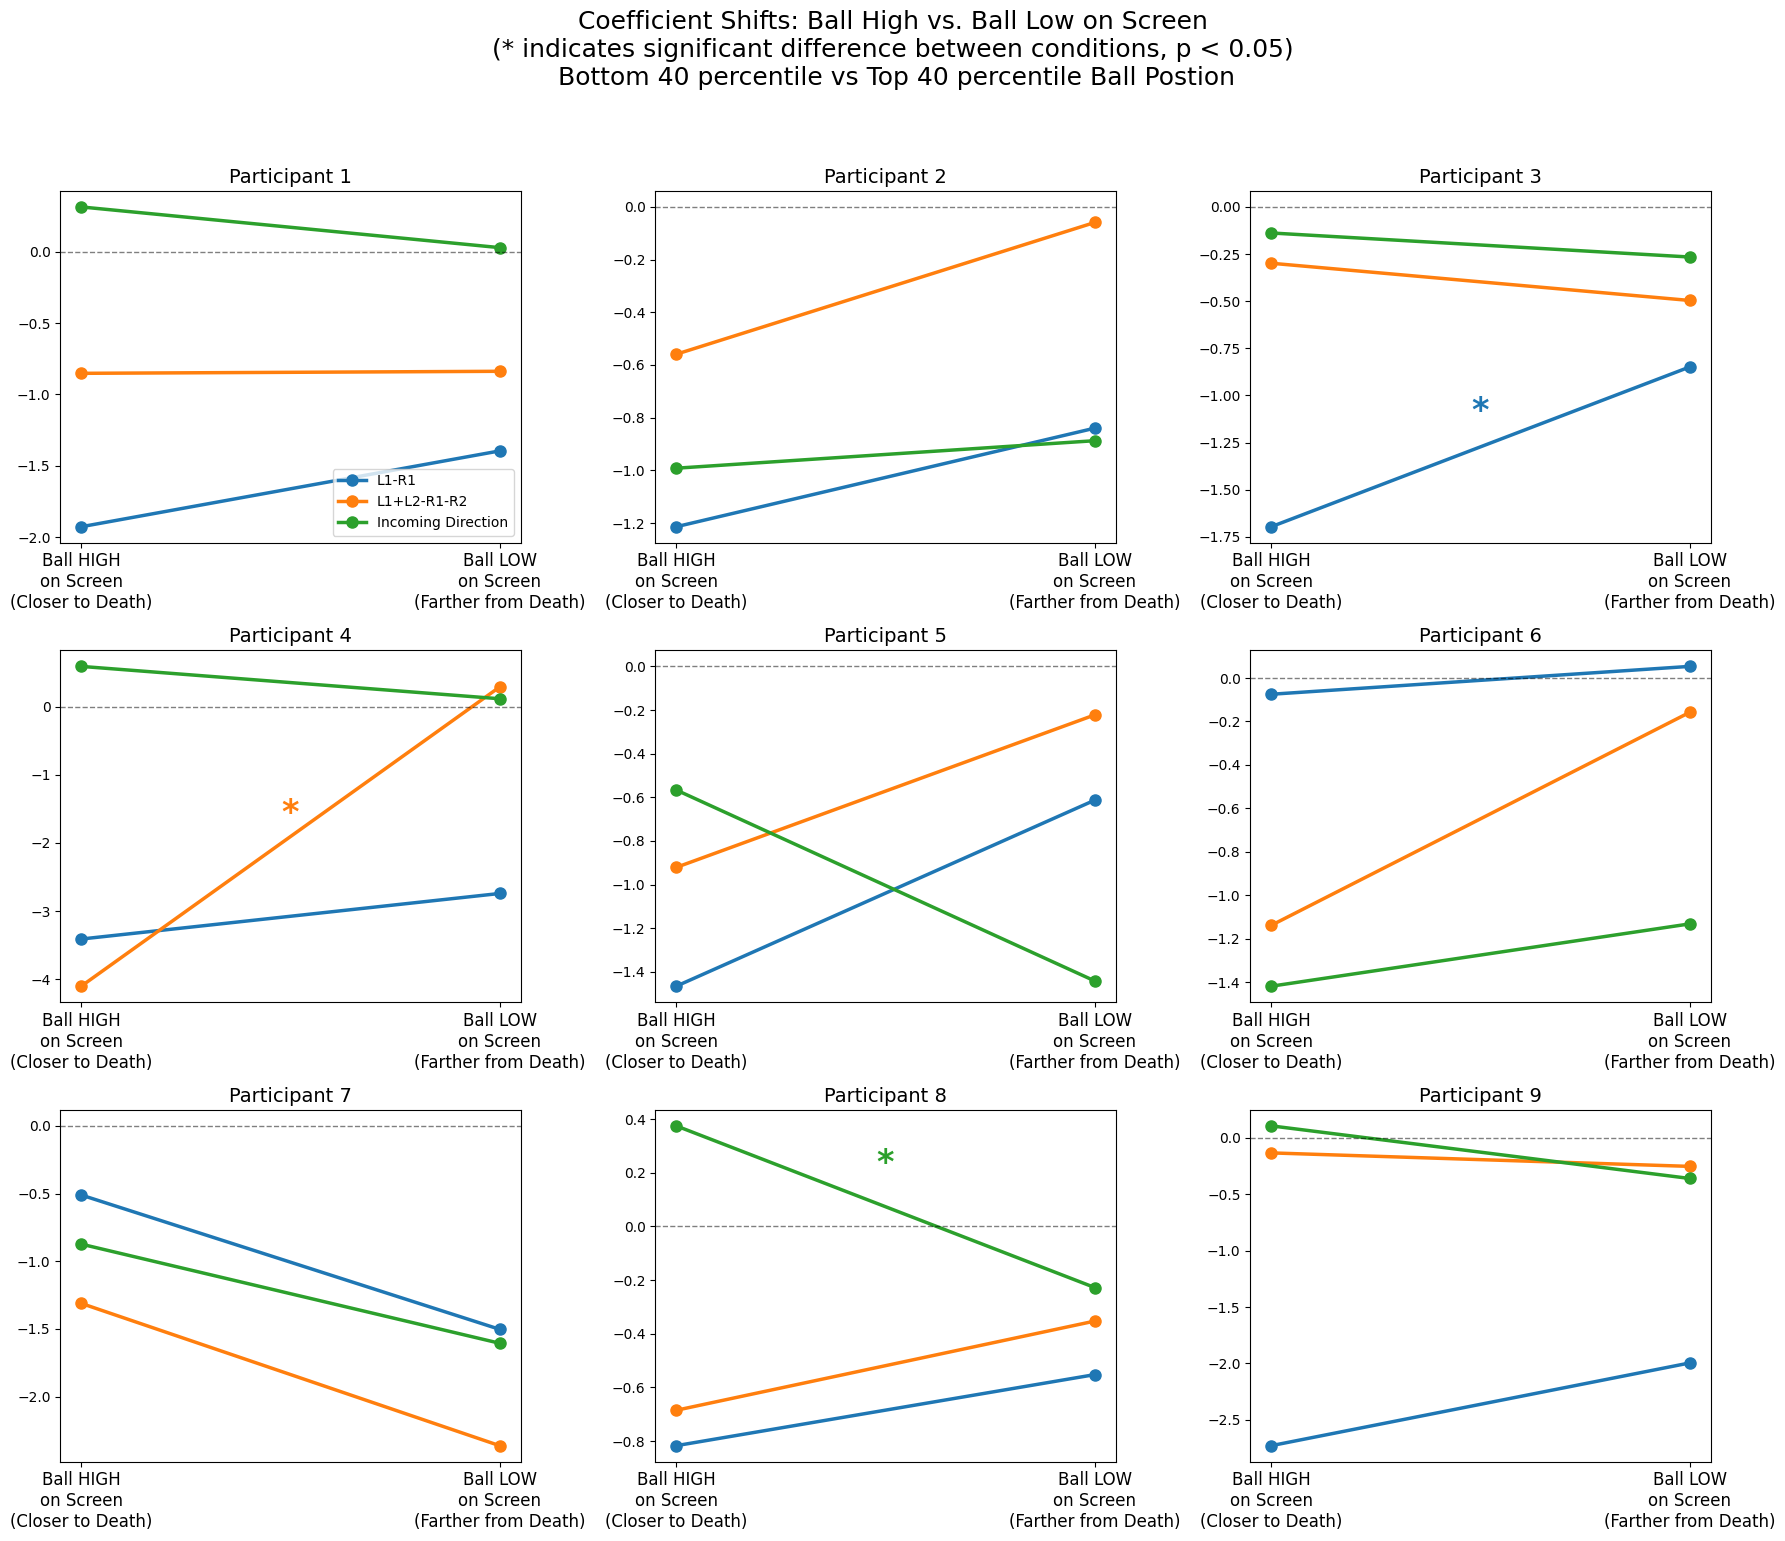

In [64]:
plot_ball_y_coefficient_shifts(participants_data, quantiles=0.4)

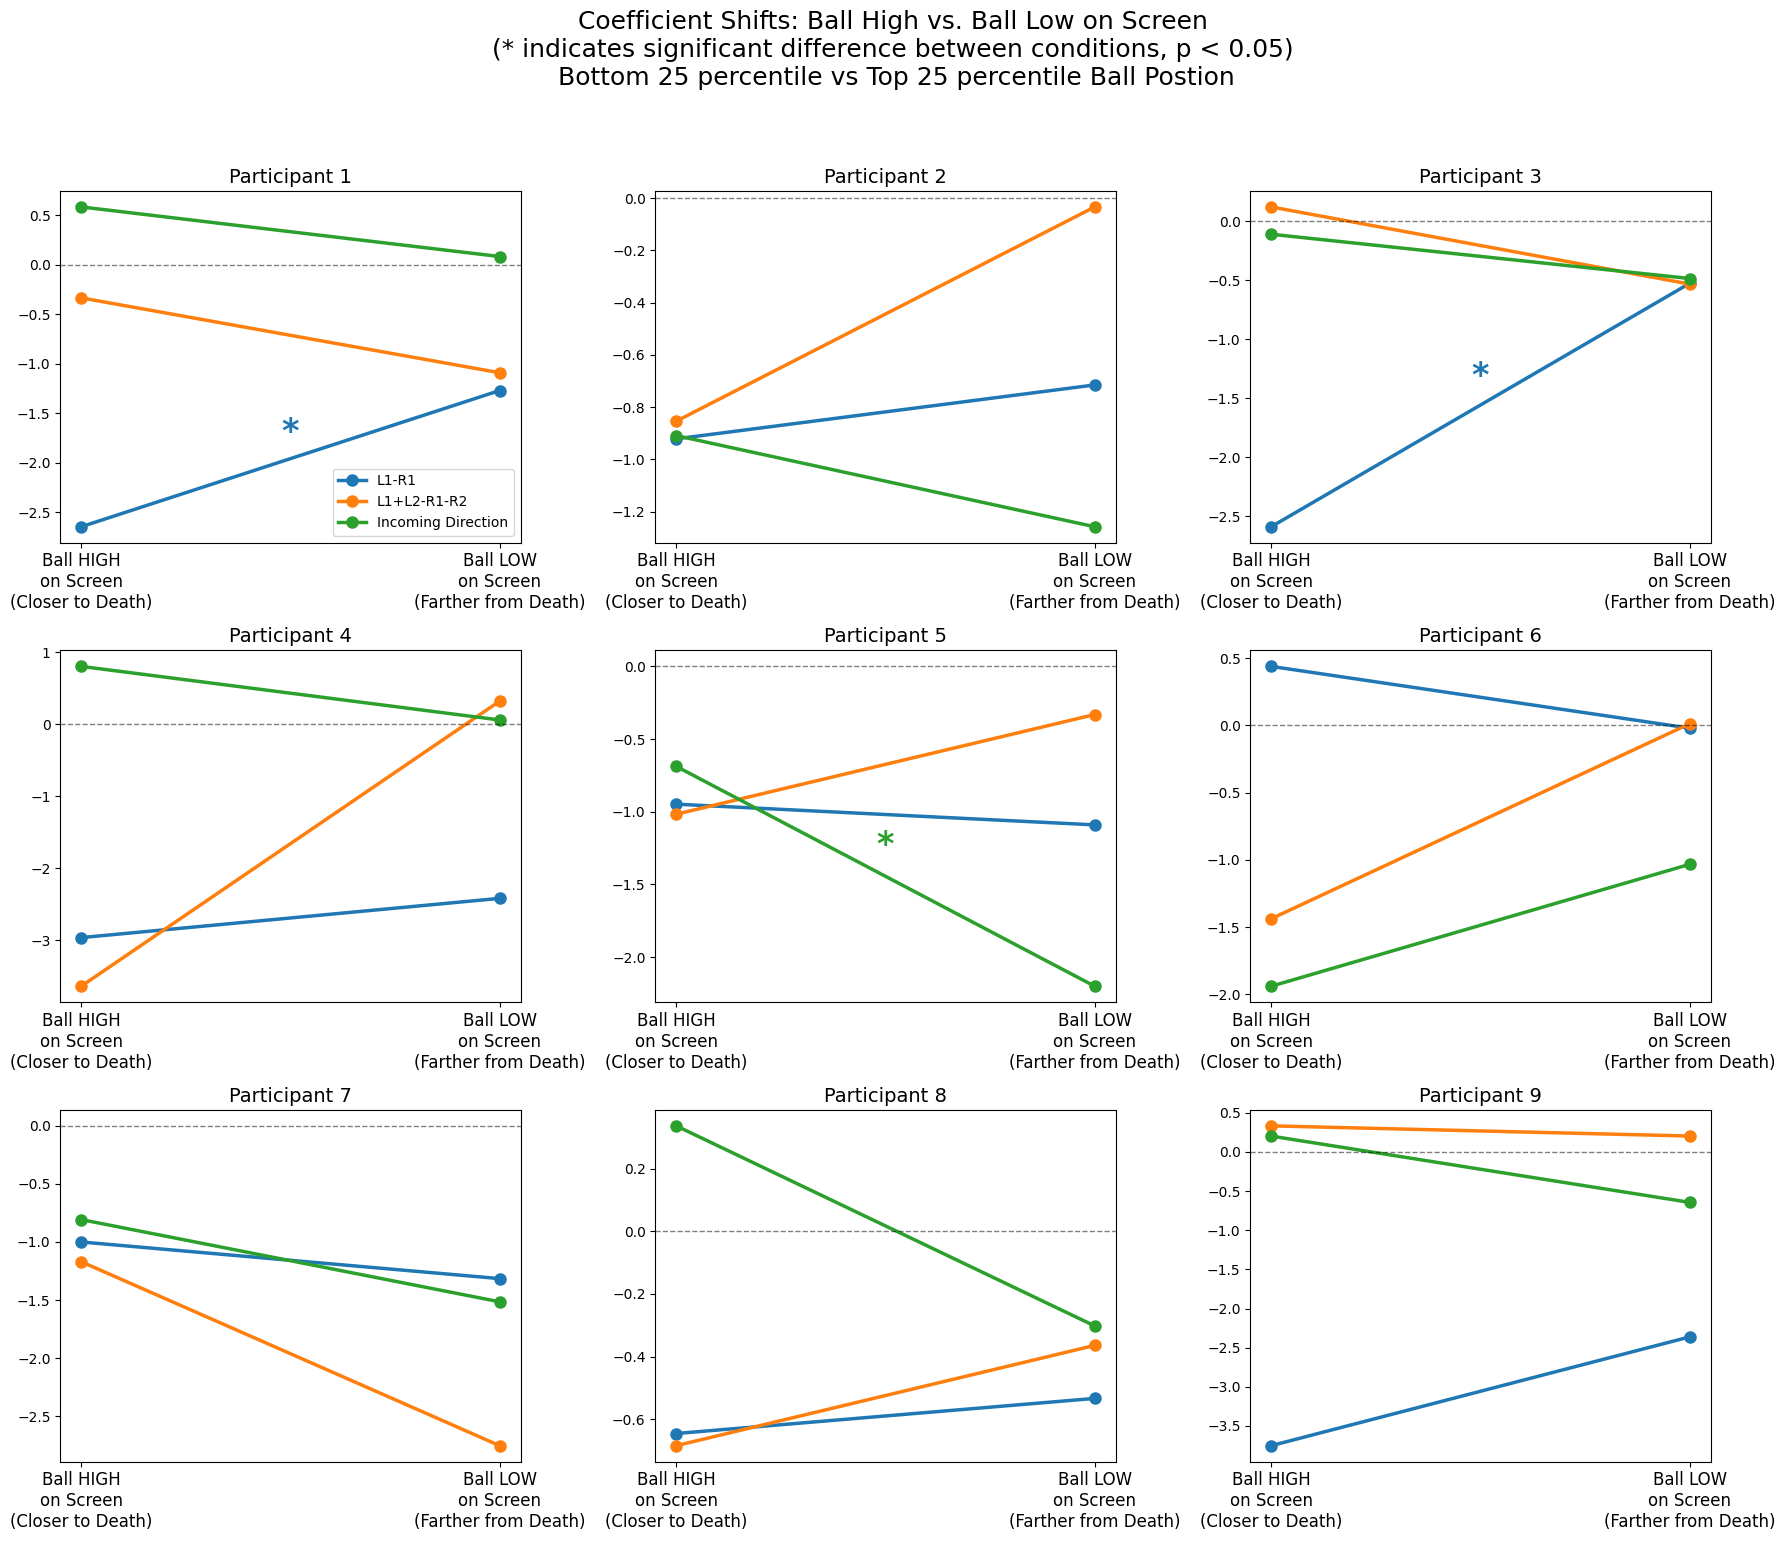

In [65]:
plot_ball_y_coefficient_shifts(participants_data, quantiles=0.25)

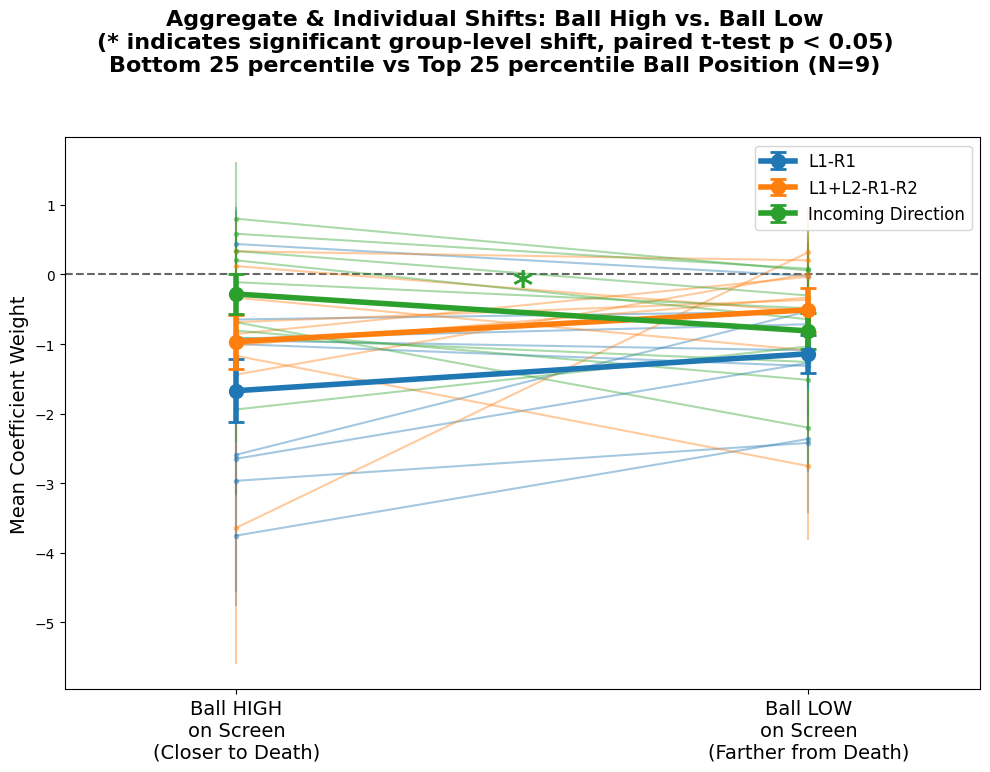

In [66]:
plot_aggregate_ball_y_shifts(participants_data, 0.25)

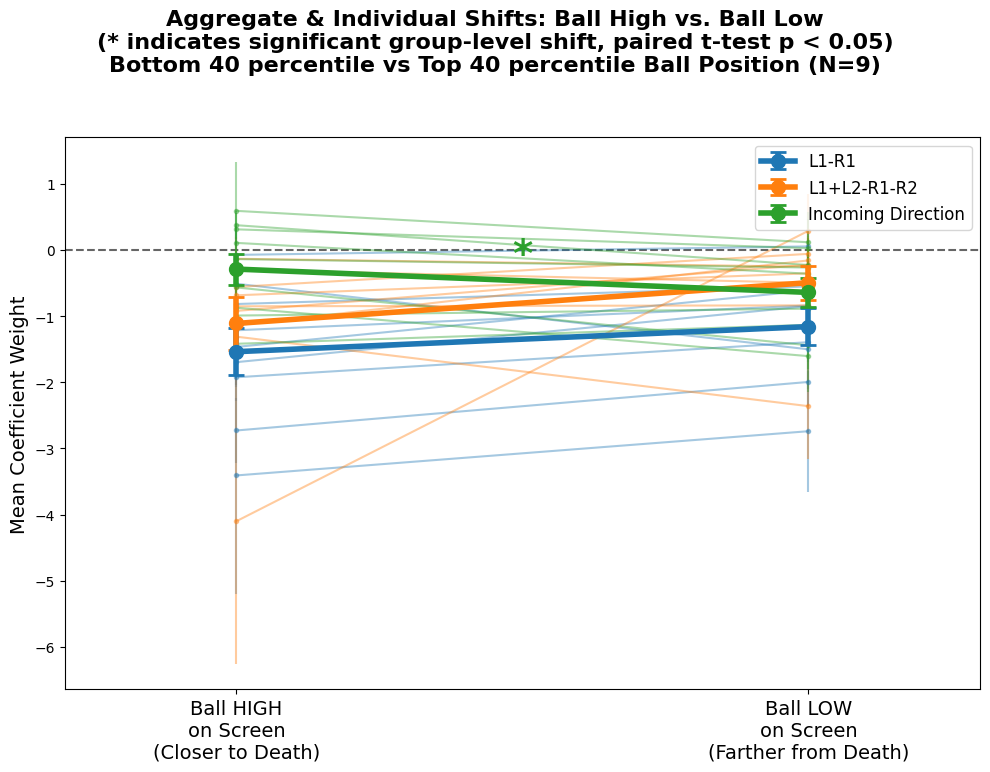

In [67]:
plot_aggregate_ball_y_shifts(participants_data, 0.4)

In [68]:
def plot_aggregate_ball_y_shifts_separated(participants_data, quantiles):
    """
    Aggregates coefficients across all valid participants for 'Ball High' 
    and 'Ball Low', plotting the group means and individual shifts.
    Separates the three features into a 1x3 grid of subplots.
    """
    percentile = quantiles * 100
    features = ['L1-R1', 'L1+L2-R1-R2', 'Incoming Direction']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

    # Data structures to collect coefficients AND standard errors across all participants
    group_high_coefs = {feature: [] for feature in features}
    group_low_coefs = {feature: [] for feature in features}
    group_high_se = {feature: [] for feature in features}
    group_low_se = {feature: [] for feature in features}

    # 1. Collect Data
    for p_data in participants_data:
        p_df = pre_proccess_data_from_choice_vs_no_choice(p_data)
        df_drift = p_df[p_df['block_drift'] == 1].copy()

        if df_drift.empty or 'ball_y_at_top' not in df_drift.columns:
            continue

        y_coords = df_drift['ball_y_at_top'].dropna()
        if len(y_coords) < 20:
            continue

        low_y_thresh = y_coords.quantile(quantiles)
        high_y_thresh = y_coords.quantile(1 - quantiles)

        df_high_on_screen = df_drift[df_drift['ball_y_at_top'] < low_y_thresh]
        df_low_on_screen = df_drift[df_drift['ball_y_at_top'] > high_y_thresh]

        params_high, se_high = prepare_and_fit_subset(df_high_on_screen)
        params_low, se_low = prepare_and_fit_subset(df_low_on_screen)

        # Only include participants where BOTH models converged
        if params_high is not None and params_low is not None:
            for feature in features:
                group_high_coefs[feature].append(params_high[feature])
                group_low_coefs[feature].append(params_low[feature])
                group_high_se[feature].append(se_high[feature])
                group_low_se[feature].append(se_low[feature])

    n_valid = len(group_high_coefs[features[0]])
    if n_valid < 2:
        print("❌ Not enough valid participant data to aggregate.")
        return

    # 2. Plotting Setup: 1 row, 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(f"""Aggregate & Individual Shifts: Ball High vs. Ball Low
(* indicates significant group-level shift, paired t-test p < 0.05)
Bottom {percentile:.0f} percentile vs Top {percentile:.0f} percentile Ball Position (N={n_valid})""", 
                 fontsize=16, fontweight='bold', y=1.05)

    x_positions = [0, 1]
    x_labels = ['HIGH\n(Closer to Death)', 'LOW\n(Farther from Death)']

    # 3. Calculate Means, SEMs, and Plot per Feature
    # zip() lets us iterate through the features and their dedicated subplot simultaneously
    for j, (feature, ax) in enumerate(zip(features, axes)):
        high_arr = np.array(group_high_coefs[feature])
        low_arr = np.array(group_low_coefs[feature])
        high_se_arr = np.array(group_high_se[feature])
        low_se_arr = np.array(group_low_se[feature])

        # A. Plot Individual Participant Lines (Background)
        for i in range(n_valid):
            ax.errorbar(x_positions, [high_arr[i], low_arr[i]], 
                        yerr=[high_se_arr[i], low_se_arr[i]], 
                        marker='.', color=colors[j], linewidth=1.5, 
                        alpha=0.2, zorder=2)

        # B. Calculate Aggregate Stats
        mean_high = np.mean(high_arr)
        mean_low = np.mean(low_arr)

        sem_high = np.std(high_arr, ddof=1) / np.sqrt(n_valid)
        sem_low = np.std(low_arr, ddof=1) / np.sqrt(n_valid)

        # C. Plot Aggregate Line (Foreground)
        ax.errorbar(x_positions, [mean_high, mean_low], 
                    yerr=[sem_high, sem_low], 
                    marker='o', color=colors[j], linewidth=4, 
                    markersize=10, label="Group Mean", capsize=6, capthick=2, zorder=5)

        # Calculate significance of the shift across the group
        _, p_val = stats.ttest_rel(high_arr, low_arr)

        # Dynamically scale the asterisk placement based on the specific subplot's y-range
        y_max = max(np.max(high_arr + high_se_arr), np.max(low_arr + low_se_arr))
        y_min = min(np.min(high_arr - high_se_arr), np.min(low_arr - low_se_arr))
        plot_range = y_max - y_min

        if p_val < 0.05:
            mid_x = 0.5
            mid_y = max(mean_high, mean_low) + (plot_range * 0.05)
            ax.text(mid_x, mid_y, '*', color=colors[j], 
                    fontsize=28, fontweight='bold', ha='center', va='bottom', zorder=6)

        # D. Subplot Formatting
        ax.set_title(feature, fontsize=16, fontweight='bold', pad=10)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, fontsize=12)
        ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)
        
        if j == 0:
            ax.set_ylabel("Coefficient Weight", fontsize=14)
            
        ax.set_xlim(-0.3, 1.3)
        # Pad the Y limits so the asterisk and caps fit cleanly within the frame
        ax.set_ylim(y_min - (plot_range * 0.1), y_max + (plot_range * 0.15))
        ax.legend(loc='best', fontsize=10)

    plt.tight_layout()
    plt.show()

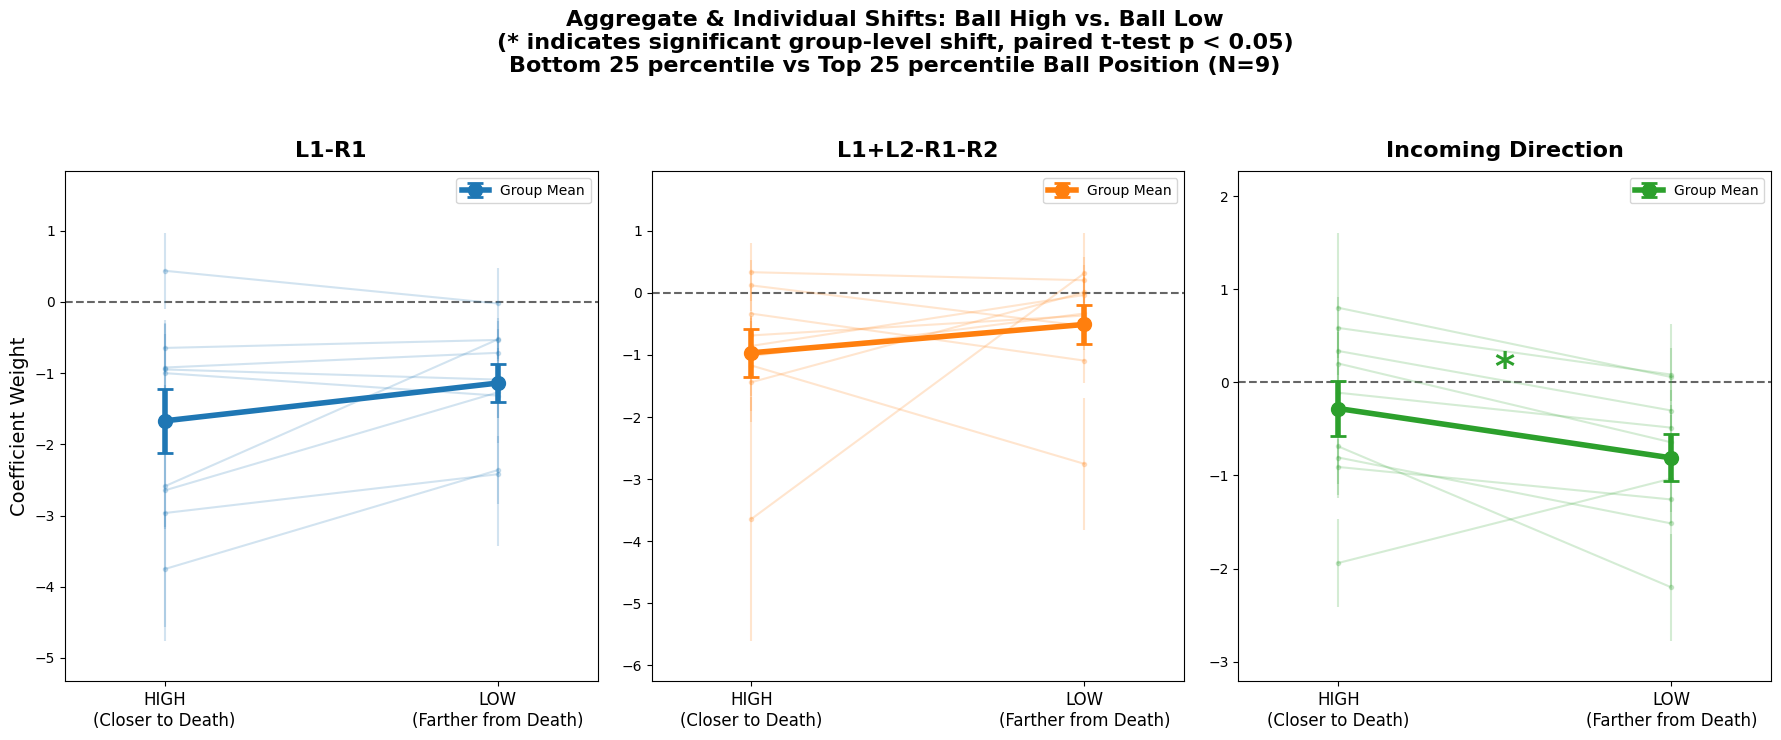

In [69]:
plot_aggregate_ball_y_shifts_separated(participants_data, 0.25)

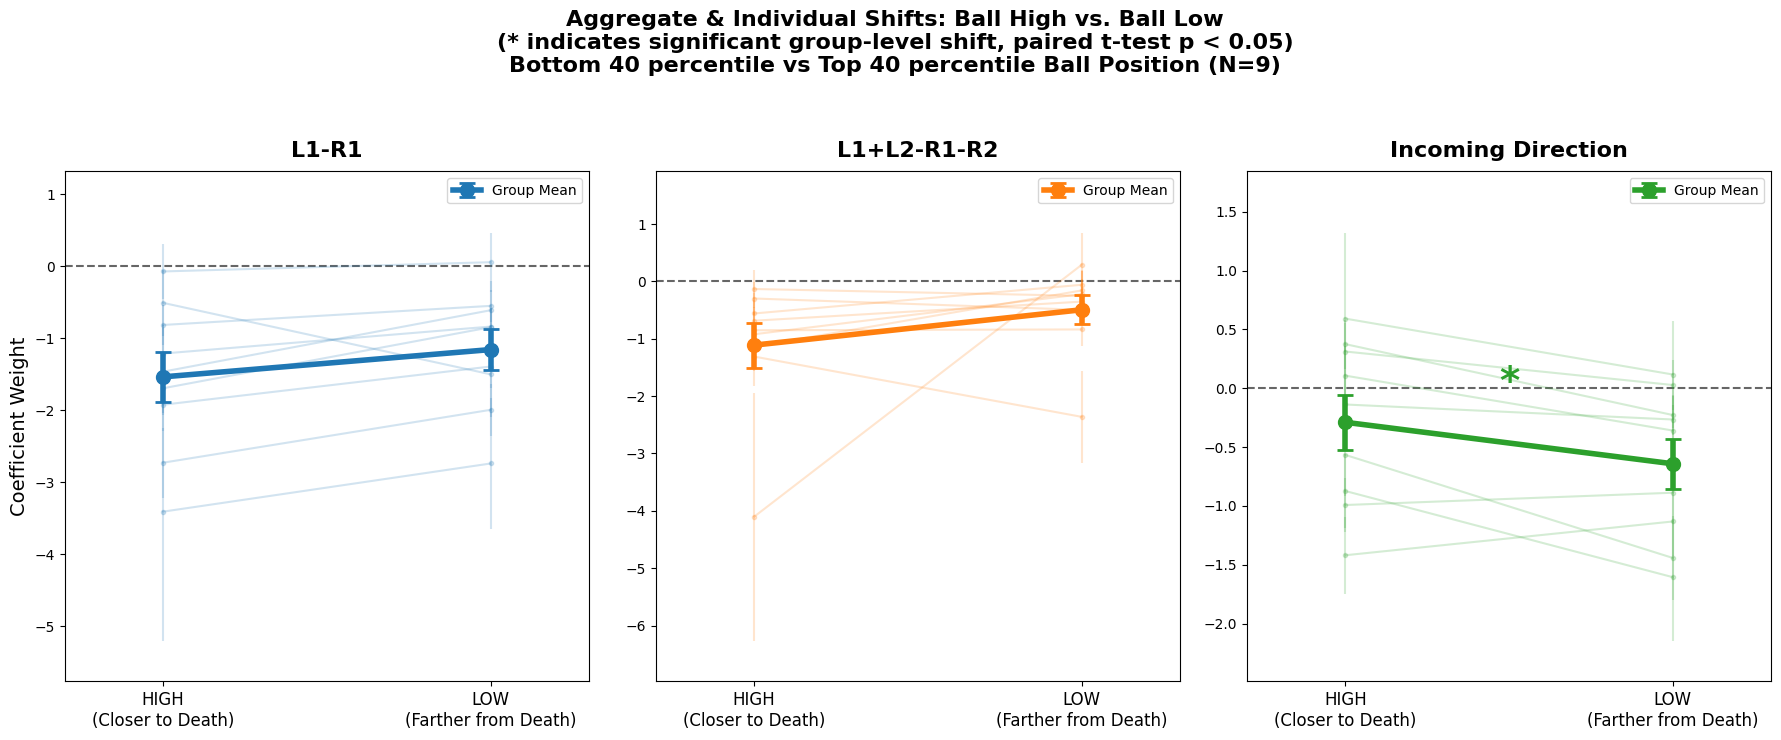

In [70]:
plot_aggregate_ball_y_shifts_separated(participants_data, 0.4)

In [72]:
def plot_aggregate_ball_y_shifts_separated_bins(participants_data, num_bins=3):
    """
    Aggregates coefficients across all valid participants, binned by 'ball_y_at_top'.
    Plots the group means and individual shifts across 'num_bins' bins.
    Separates the three features into a 1x3 grid of subplots.
    """
    features = ['L1-R1', 'L1+L2-R1-R2', 'Incoming Direction']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

    # Data structures to collect coefficients AND standard errors dynamically for N bins
    # Dictionary of features mapping to a list of lists (one list per bin)
    group_coefs = {feature: [[] for _ in range(num_bins)] for feature in features}
    group_se = {feature: [[] for _ in range(num_bins)] for feature in features}

    # 1. Collect Data
    for p_data in participants_data:
        p_df = pre_proccess_data_from_choice_vs_no_choice(p_data)
        df_drift = p_df[p_df['block_drift'] == 1].copy()

        if df_drift.empty or 'ball_y_at_top' not in df_drift.columns:
            continue

        y_coords = df_drift['ball_y_at_top'].dropna()
        # Ensure there are enough data points to distribute across the requested bins
        if len(y_coords) < (10 * num_bins): 
            continue

        # Bin the data into equal-sized groups
        # labels=False returns integer indicators (0 to num_bins-1)
        # Note: 0 will correspond to the lowest y-values (Highest on screen)
        try:
            df_drift['bin'] = pd.qcut(df_drift['ball_y_at_top'], q=num_bins, labels=False, duplicates='drop')
        except ValueError:
            # Fails if there are too many duplicate edges to form the bins
            continue 

        # Temporarily store this participant's data to ensure ALL bins converge
        participant_params = {}
        participant_se = {}
        all_bins_converged = True

        for b in range(num_bins):
            df_bin = df_drift[df_drift['bin'] == b]
            params, se = prepare_and_fit_subset(df_bin)
            
            if params is None:
                all_bins_converged = False
                break
                
            participant_params[b] = params
            participant_se[b] = se

        # Only include participants where the model converged for EVERY bin
        if all_bins_converged:
            for feature in features:
                for b in range(num_bins):
                    group_coefs[feature][b].append(participant_params[b][feature])
                    group_se[feature][b].append(participant_se[b][feature])

    n_valid = len(group_coefs[features[0]][0]) if group_coefs[features[0]][0] else 0
    if n_valid < 2:
        print(f"❌ Not enough valid participant data to aggregate for {num_bins} bins.")
        return

    # 2. Plotting Setup: 1 row, 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(f"""Aggregate & Individual Shifts Across {num_bins} Bins of Ball Position
(* indicates significant group-level shift between Bin 1 & Bin {num_bins}, paired t-test p < 0.05)
(N={n_valid})""", fontsize=16, fontweight='bold', y=1.05)

    x_positions = list(range(num_bins))
    
    # Generate dynamic x-axis labels
    x_labels = []
    for b in range(num_bins):
        if b == 0:
            x_labels.append("Bin 1\n(High on screen)")
        elif b == num_bins - 1:
            x_labels.append(f"Bin {num_bins}\n(Low on screen)")
        else:
            x_labels.append(f"Bin {b+1}")

    # 3. Calculate Means, SEMs, and Plot per Feature
    for j, (feature, ax) in enumerate(zip(features, axes)):
        
        # Convert lists to arrays for easier math operations: shape -> (num_bins, n_valid)
        coef_arrays = [np.array(group_coefs[feature][b]) for b in range(num_bins)]
        se_arrays = [np.array(group_se[feature][b]) for b in range(num_bins)]

        # A. Plot Individual Participant Lines (Background)
        for i in range(n_valid):
            p_coefs = [coef_arrays[b][i] for b in range(num_bins)]
            p_ses = [se_arrays[b][i] for b in range(num_bins)]
            
            ax.errorbar(x_positions, p_coefs, yerr=p_ses, 
                        marker='.', color=colors[j], linewidth=1.5, 
                        alpha=0.2, zorder=2)

        # B. Calculate Aggregate Stats across all bins
        means = [np.mean(coef_arrays[b]) for b in range(num_bins)]
        sems = [np.std(coef_arrays[b], ddof=1) / np.sqrt(n_valid) for b in range(num_bins)]

        # C. Plot Aggregate Line (Foreground)
        ax.errorbar(x_positions, means, yerr=sems, 
                    marker='o', color=colors[j], linewidth=4, 
                    markersize=10, label="Group Mean", capsize=6, capthick=2, zorder=5)

        # Calculate significance of the shift between the FIRST and LAST bin
        _, p_val = stats.ttest_rel(coef_arrays[0], coef_arrays[-1])

        # Dynamically scale the asterisk placement based on the specific subplot's y-range
        y_maxes = [np.max(coef_arrays[b] + se_arrays[b]) for b in range(num_bins)]
        y_mins = [np.min(coef_arrays[b] - se_arrays[b]) for b in range(num_bins)]
        
        y_max = max(y_maxes)
        y_min = min(y_mins)
        plot_range = y_max - y_min

        if p_val < 0.05:
            # Place the asterisk in the center of the chart horizontally
            mid_x = (num_bins - 1) / 2.0 
            mid_y = max(means[0], means[-1]) + (plot_range * 0.05)
            ax.text(mid_x, mid_y, '*', color=colors[j], 
                    fontsize=28, fontweight='bold', ha='center', va='bottom', zorder=6)

        # D. Subplot Formatting
        ax.set_title(feature, fontsize=16, fontweight='bold', pad=10)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, fontsize=12)
        ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)
        
        if j == 0:
            ax.set_ylabel("Coefficient Weight", fontsize=14)
            
        ax.set_xlim(-0.3, num_bins - 1 + 0.3)
        ax.set_ylim(y_min - (plot_range * 0.1), y_max + (plot_range * 0.15))
        ax.legend(loc='best', fontsize=10)

    plt.tight_layout()
    plt.show()

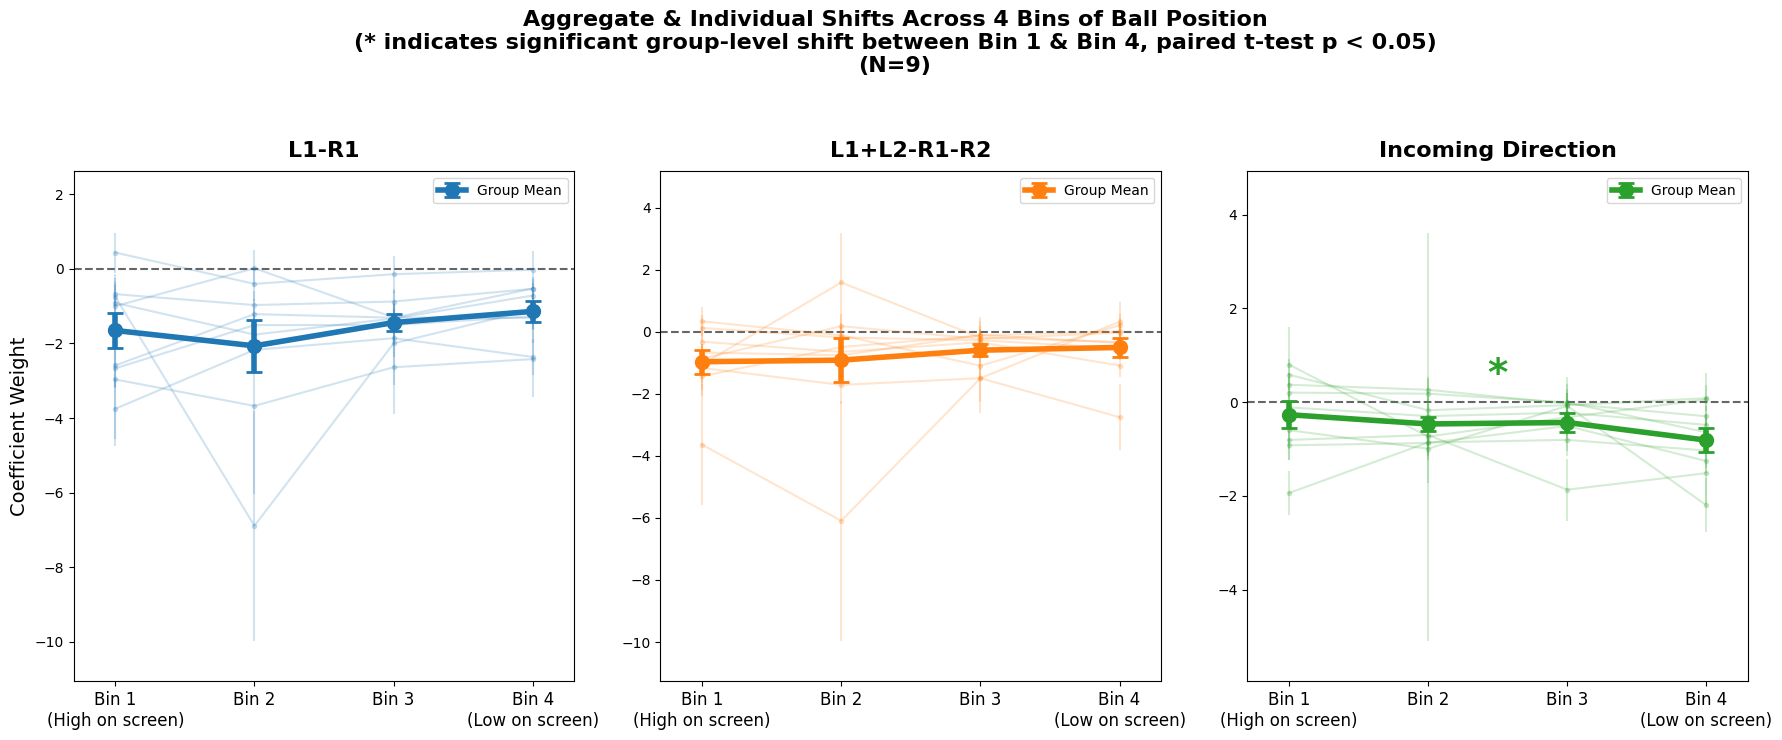

In [78]:
plot_aggregate_ball_y_shifts_separated_bins(participants_data, num_bins=4)

# Fitting Custom Model

In [13]:
participant1 = load("../data/cloud_study/65D6694BE06947289BE4336BC1DE271A-019e9464-b9d3-798d-aa65-c87d82961db6-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-03-48-346Z-fg8d.json")
participant2 = load("../data/cloud_study/88AD64F00C6B43489770A02E7A1AE2C2-019e8fd9-16e9-7876-8e3b-d51a48df0526-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-03T23-37-31-300Z-4ecm.json")
participant3 = load("../data/cloud_study/6462D588260B4356936047A04A336EBE-019e9464-f99c-77c5-bf47-327c7a7cf4f1-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-41-26-943Z-c5do.json")
participant4 = load("../data/cloud_study/46331EBA4F494FAD901E83106523FF12-019e9464-9d12-7cc3-8cba-8f0dd00eeb20-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-33-792Z-sop6.json")
participant5 = load("../data/cloud_study/BB4D2ACD4DAB45F5BAB68A472EB2E06C-019e9464-9a85-718c-9964-ec6755cdcd1c-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-17-611Z-i0am.json")
participant6 = load("../data/cloud_study/C47CEEC22AD9448E9F87D0577BA7FC80-019e946e-abeb-723a-8d4d-50881fc0551f-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-59-12-508Z-e1tl.json")
participant7 = load("../data/cloud_study/CEFD2FE92E6847B2B27FF0175811CE81-019e9464-988c-7240-bf66-336f77c05049-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-50-03-371Z-34zm.json")
participant8 = load("../data/cloud_study/EC07396CE23248F2855499612FEB8ACA-019e9464-92a5-7d10-b713-7022c5b049fc-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-16-501Z-olib.json")
participant9 = load("../data/cloud_study/FD2A6686546A4D689BE4A684CD264636-019e946a-96b4-78df-ac42-63e6e82c3209-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-54-42-499Z-j7h3.json")

participants_data = [participant1, participant2, participant3, participant4, participant5, participant6, participant7, participant8, participant9]

In [14]:
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.preprocessing import StandardScaler
from scipy.special import expit, logit


participant_data_dict = {f"Participant_{i+1}": data for i, data in enumerate(participants_data)}

In [15]:
def calculate_p_right_dynamic(params, d_greedy, d_plan, covariates):
    p_lapse, p_plan_base, w1, s_greedy, s_plan = params
    
    prob_greedy = expit(d_greedy / s_greedy)
    prob_plan = expit(d_plan / s_plan)
    
    p_plan_base_safe = np.clip(p_plan_base, 1e-6, 1 - 1e-6)
    
    dynamic_p_plan = expit(logit(p_plan_base_safe) + w1 * covariates)
    
    model_prob = (1 - dynamic_p_plan) * prob_greedy + dynamic_p_plan * prob_plan
    final_prob = p_lapse * 0.5 + (1 - p_lapse) * model_prob
    
    return final_prob

def negative_log_likelihood_dynamic(params, d_greedy, d_plan, covariates, choices):
    """Objective function for SciPy to minimize."""
    p_R = calculate_p_right_dynamic(params, d_greedy, d_plan, covariates)
    
    # Clip to prevent log(0) causing NaN errors
    epsilon = 1e-10
    p_R = np.clip(p_R, epsilon, 1 - epsilon)
    
    # Calculate Log-Likelihood
    ll = np.sum(choices * np.log(p_R) + (1 - choices) * np.log(1 - p_R))
    return -ll

def evaluate_cognitive_model(params, d_greedy, d_plan, covariates, choices):
    """Calculates Accuracy and Log-Likelihood from fitted parameters."""
    p_R = calculate_p_right_dynamic(params, d_greedy, d_plan, covariates)
    
    # Predict Right (1) if prob >= 0.5, else predict Left (0)
    predictions = (p_R >= 0.5).astype(int)
    
    correct = np.sum(predictions == choices)
    total = len(choices)
    accuracy = correct / total
    
    # Re-calculate LL for reporting
    epsilon = 1e-10
    p_R_clipped = np.clip(p_R, epsilon, 1 - epsilon)
    ll = np.sum(choices * np.log(p_R_clipped) + (1 - choices) * np.log(1 - p_R_clipped))
    ll_mean = np.mean(choices * np.log(p_R_clipped) + (1 - choices) * np.log(1 - p_R_clipped))
    
    return accuracy, ll, ll_mean

def fit_dynamic_model(d_greedy_data, d_plan_data, covariates_data, choices_data):
    # Initial Guesses: [p_lapse, p_plan_base, w1, s_greedy, s_plan]
    # We guess a 50% baseline planning rate
    initial_guess = [0.05, 0.5, 0.0, 10.0, 10.0]
    
    bounds = [
        (0.0, 0.99),    # p_lapse
        (0.0, 1.0),     # p_plan_base (Now strictly bounded as a probability!)
        (None, None),   # w1 (Covariate effect remains unconstrained)
        (0.001, None),  # s_greedy
        (0.001, None)   # s_plan
    ]
    
    result = minimize(
        fun=negative_log_likelihood_dynamic,
        x0=initial_guess,
        args=(d_greedy_data, d_plan_data, covariates_data, choices_data),
        bounds=bounds,
        method='L-BFGS-B'
    )
    return result

In [16]:
def run_participant_fits(participant_data_dict):
    """
    Iterates through all participants, formats their data, fits the model, 
    and prints their individual metrics.
    """
    results_list = []
    
    for participant_name, raw_data in participant_data_dict.items():
        print(f"\n--- Fitting Model for {participant_name} ---")
        
        # 1. Pre-process the data
        processed_data = pre_proccess_data_from_choice_vs_no_choice(raw_data)
        processed_data = processed_data[processed_data['choice_trial'] == True]
        processed_data = processed_data.dropna(subset=['chosen_1step_dist', 'ball_y_at_top']).reset_index(drop=True)
        
        if len(processed_data) == 0:
            print("Skipping: No valid trials found.")
            continue
            
        # 2. Extract specific arrays
        is_left = processed_data['chosen_left']
        
        # Greedy Distance (L1 - R1)
        L1 = np.where(is_left, processed_data['chosen_1step_dist'], processed_data['unchosen_1step_dist'])
        R1 = np.where(~is_left, processed_data['chosen_1step_dist'], processed_data['unchosen_1step_dist'])
        d_greedy = L1 - R1
        
        # Plan Distance (Total L - Total R)
        Total_L = np.where(is_left, processed_data['chosen_2step_dist'], processed_data['unchosen_2step_dist'])
        Total_R = np.where(~is_left, processed_data['chosen_2step_dist'], processed_data['unchosen_2step_dist'])
        d_plan = Total_L - Total_R
        
        # Covariate (Ball Y)
        scaler = StandardScaler()
        covariate = scaler.fit_transform(processed_data[['ball_y_at_top']]).flatten()
        
        # Choices: 1 for Right, 0 for Left
        choices = (~is_left).astype(int).values
        
        # 3. Fit the model
        fit_result = fit_dynamic_model(d_greedy, d_plan, covariate, choices)
        
        if fit_result.success:
            p_lapse, p_plan_base, w1, s_greedy, s_plan = fit_result.x
            
            acc, ll, ll_mean = evaluate_cognitive_model(fit_result.x, d_greedy, d_plan, covariate, choices)
            
            print(f"Fit Status:  SUCCESS")
            print(f"Accuracy:    {acc*100:.2f}%")
            print(f"Log-Likely:  {ll:.4f}")
            print(f"Average Log-Likely:  {ll_mean:.4f}")
            print(f"Params -> p_lapse: {p_lapse:.3f} | p_plan_base: {p_plan_base:.3f} | w1: {w1:.3f} | s_greedy: {s_greedy:.1f} | s_plan: {s_plan:.1f}")
            
            results_list.append({
                'Participant': participant_name,
                'Accuracy': acc,
                'LL': ll,
                'p_lapse': p_lapse,
                'p_plan_base': p_plan_base,
                'w1': w1,
                's_greedy': s_greedy,
                's_plan': s_plan
            })

    # Return a clean DataFrame of all participant parameters
    return pd.DataFrame(results_list)

If $w_1$ is negative, that means that more time pressure increases the probability of planning, whereas a positive value means that more time pressure decreases the probability of planning

In [17]:
final_parameters_df = run_participant_fits(participant_data_dict)


--- Fitting Model for Participant_1 ---
Fit Status:  SUCCESS
Accuracy:    75.63%
Log-Likely:  -550.6625
Average Log-Likely:  -0.5346
Params -> p_lapse: 0.000 | p_plan_base: 1.000 | w1: 1.470 | s_greedy: 6.4 | s_plan: 3.4

--- Fitting Model for Participant_2 ---
Fit Status:  SUCCESS
Accuracy:    71.12%
Log-Likely:  -590.2266
Average Log-Likely:  -0.5798
Params -> p_lapse: 0.000 | p_plan_base: 1.000 | w1: -2.422 | s_greedy: 4.3 | s_plan: 4.3

--- Fitting Model for Participant_3 ---
Fit Status:  SUCCESS
Accuracy:    71.94%
Log-Likely:  -600.5151
Average Log-Likely:  -0.5830
Params -> p_lapse: 0.000 | p_plan_base: 1.000 | w1: 0.772 | s_greedy: 4.7 | s_plan: 4.4

--- Fitting Model for Participant_4 ---
Fit Status:  SUCCESS
Accuracy:    80.52%
Log-Likely:  -309.9022
Average Log-Likely:  -0.4753
Params -> p_lapse: 0.000 | p_plan_base: 1.000 | w1: -0.983 | s_greedy: 7.6 | s_plan: 2.8

--- Fitting Model for Participant_5 ---
Fit Status:  SUCCESS
Accuracy:    72.56%
Log-Likely:  -415.1644
Avera